# Notebook 05 — Sentiment EDA: From Signals to Market Impact

## The Question We're Answering

Central banks move markets. Retail traders react to headlines. Search trends reveal attention shifts before prices move. But do any of these sentiment signals actually *predict* or *explain* FX price action?

This notebook investigates the full sentiment pipeline — from raw data quality, through distribution analysis and temporal dynamics, to market impact testing and model evaluation. It documents the thought process, including what worked, what failed, and why.

## Current Pipeline

All institutional sentiment (Fed, ECB, BoE) and Reddit scores use **FinBERT** — a BERT-based model pre-trained on financial text. The pipeline applies FinBERT to **document titles** (~10–20 words), not full text. FinBERT has a **512-token context window** (~380 words), but central bank speeches run 5,000–15,000 words. This is the primary limitation we investigate and document for the modeling phase.

StockTwits uses the platform's native **Bullish/Bearish label** — no NLP. Google Trends stores the raw **search interest index [0–100]** — not sentiment.

## Data Inventory

| Layer | Source | Model | Rows | Key limitation |
|---|---|---|---|---|
| **Institutional (Fed)** | federalreserve.gov | FinBERT on titles | 1,112 | Title-only; 82% neutral |
| **Institutional (ECB)** | ECB RSS + archive | FinBERT on titles | 841 | Title-only; 85% neutral |
| **Institutional (BoE)** | BoE RSS + sitemap | FinBERT on titles | 1,029 | Title-only; 93% neutral |
| **Financial news (GDELT)** | GDELT BigQuery | — | **0 rows — pipeline broken** | Excluded |
| **Retail social (StockTwits)** | StockTwits API | Native labels | 1,177 | Binary only; starts Sep 2021 |
| **Search attention** | Google Trends | None (index) | 8,874 | Not directional; [0–100] scale |
| **Reddit** | Arctic Shift API | FinBERT on posts | 14,857 | 2021 is backfill artifact |

## Story Structure

1. **Part 1 — Data audit** — verify every source before trusting it
2. **Part 2 — Distributions** — what does the sentiment landscape actually look like?
3. **Part 3 — Temporal dynamics** — does sentiment capture known macro regimes?
4. **Part 4 — Market impact** — event study: do sentiment events move prices?
5. **Part 5 — Google Trends vs. volatility** — attention as a regime indicator
6. **Part 6 — Cross-source correlation** — are the signals independent?
7. **Part 7 — Composite index** — does the combined signal predict EUR/USD?
8. **Part 8 — Pipeline & model options** — FinBERT limitations and alternatives
9. **Part 9 — Hawk/dove overlay** — rule-based policy classification attempt
10. **Part 10 — Feature engineering** — preparing data for Agent 3
11. **Part 11 — Baseline model** — can current features beat a coin flip?
12. **Part 12 — FinBERT context window problem** — comparing approaches for full-text scoring

In [1]:
import warnings
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

# Paths
ROOT = Path("d:/SCRIPTS/FX-AlphaLab")
SENTIMENT_DIR = ROOT / "data/processed/sentiment"
OHLCV_DIR = ROOT / "data/processed/ohlcv"

plt.rcParams.update({
    "figure.facecolor": "#0f0f0f",
    "axes.facecolor": "#1a1a2e",
    "axes.edgecolor": "#444",
    "axes.labelcolor": "#ccc",
    "xtick.color": "#aaa",
    "ytick.color": "#aaa",
    "text.color": "#eee",
    "grid.color": "#2a2a3e",
    "grid.linestyle": "--",
    "grid.alpha": 0.5,
    "legend.facecolor": "#1a1a2e",
    "legend.edgecolor": "#444",
    "figure.titlesize": 14,
    "axes.titlesize": 12,
    "axes.titlecolor": "#fff",
})

COLORS = {"fed": "#e74c3c", "ecb": "#3498db", "boe": "#2ecc71",
          "reddit": "#e67e22", "stocktwits": "#9b59b6", "google_trends": "#f1c40f"}

print("Setup complete. Sentiment dir:", SENTIMENT_DIR.exists(), "| OHLCV dir:", OHLCV_DIR.exists())

Setup complete. Sentiment dir: True | OHLCV dir: True


---
## Part 1 — Data Audit

Before any analysis, we verify every data source. The goal is to answer:
- Does the file exist and load cleanly?
- What are the date ranges and record counts?
- Are there nulls, duplicates, or schema mismatches?
- Is the sentiment score column populated and in a valid range?

We do not assume the pipeline is correct — we check it.

In [2]:
import pyarrow.dataset as ds

audit_results = []

# ── Institutional sources (partitioned parquet) ──────────────────────────────
for source in ["fed", "ecb", "boe"]:
    source_path = SENTIMENT_DIR / f"source={source}"
    try:
        dataset = ds.dataset(source_path, format="parquet", partitioning="hive")
        df = dataset.to_table().to_pandas()
        n_rows = len(df)
        n_dupes = df.duplicated().sum()
        date_col = "timestamp_utc" if "timestamp_utc" in df.columns else None
        score_col = "sentiment_score" if "sentiment_score" in df.columns else None
        date_min = pd.to_datetime(df[date_col]).min() if date_col else "N/A"
        date_max = pd.to_datetime(df[date_col]).max() if date_col else "N/A"
        null_score = df[score_col].isna().sum() if score_col else "N/A"
        score_range = f"[{df[score_col].min():.2f}, {df[score_col].max():.2f}]" if score_col else "N/A"
        audit_results.append({
            "source": source, "rows": n_rows, "dupes": n_dupes,
            "date_min": date_min, "date_max": date_max,
            "null_score": null_score, "score_range": score_range,
            "columns": list(df.columns)
        })
    except Exception as e:
        audit_results.append({"source": source, "rows": 0, "error": str(e)})

# ── Google Trends (partitioned parquet) ──────────────────────────────────────
gt_path = SENTIMENT_DIR / "source=google_trends"
try:
    dataset = ds.dataset(gt_path, format="parquet", partitioning="hive")
    df_gt = dataset.to_table().to_pandas()
    audit_results.append({
        "source": "google_trends", "rows": len(df_gt), "dupes": df_gt.duplicated().sum(),
        "date_min": pd.to_datetime(df_gt["timestamp_utc"]).min() if "timestamp_utc" in df_gt.columns else "N/A",
        "date_max": pd.to_datetime(df_gt["timestamp_utc"]).max() if "timestamp_utc" in df_gt.columns else "N/A",
        "null_score": df_gt["sentiment_score"].isna().sum() if "sentiment_score" in df_gt.columns else "N/A",
        "score_range": f"[{df_gt['sentiment_score'].min():.2f}, {df_gt['sentiment_score'].max():.2f}]" if "sentiment_score" in df_gt.columns else "N/A",
        "columns": list(df_gt.columns)
    })
except Exception as e:
    audit_results.append({"source": "google_trends", "rows": 0, "error": str(e)})

# ── Reddit (CSV) ─────────────────────────────────────────────────────────────
reddit_path = SENTIMENT_DIR / "reddit_sentiment_consolidated.csv"
try:
    df_reddit = pd.read_csv(reddit_path)
    date_col = "timestamp_utc" if "timestamp_utc" in df_reddit.columns else (
        "created_utc" if "created_utc" in df_reddit.columns else None)
    score_col = "sentiment_score" if "sentiment_score" in df_reddit.columns else None
    audit_results.append({
        "source": "reddit", "rows": len(df_reddit), "dupes": df_reddit.duplicated().sum(),
        "date_min": pd.to_datetime(df_reddit[date_col]).min() if date_col else "N/A",
        "date_max": pd.to_datetime(df_reddit[date_col]).max() if date_col else "N/A",
        "null_score": df_reddit[score_col].isna().sum() if score_col else "N/A",
        "score_range": f"[{df_reddit[score_col].min():.2f}, {df_reddit[score_col].max():.2f}]" if score_col else "N/A",
        "columns": list(df_reddit.columns)
    })
except Exception as e:
    audit_results.append({"source": "reddit", "rows": 0, "error": str(e)})

# ── StockTwits (partitioned parquet) ─────────────────────────────────────────
st_path = SENTIMENT_DIR / "source=stocktwits"
try:
    dataset = ds.dataset(st_path, format="parquet", partitioning="hive")
    df_st = dataset.to_table().to_pandas()
    date_col = "timestamp_utc" if "timestamp_utc" in df_st.columns else None
    score_col = "sentiment_score" if "sentiment_score" in df_st.columns else None
    audit_results.append({
        "source": "stocktwits", "rows": len(df_st), "dupes": df_st.duplicated().sum(),
        "date_min": pd.to_datetime(df_st[date_col]).min() if date_col else "N/A",
        "date_max": pd.to_datetime(df_st[date_col]).max() if date_col else "N/A",
        "null_score": df_st[score_col].isna().sum() if score_col else "N/A",
        "score_range": f"[{df_st[score_col].min():.2f}, {df_st[score_col].max():.2f}]" if score_col else "N/A",
        "columns": list(df_st.columns)
    })
except Exception as e:
    audit_results.append({"source": "stocktwits", "rows": 0, "error": str(e)})

# ── Print audit table ─────────────────────────────────────────────────────────
for r in audit_results:
    print(f"\n{'='*60}")
    print(f"SOURCE: {r['source'].upper()}")
    if "error" in r:
        print(f"  ❌ ERROR: {r['error']}")
    else:
        print(f"  rows       : {r['rows']:,}")
        print(f"  duplicates : {r['dupes']}")
        print(f"  date range : {r['date_min']} → {r['date_max']}")
        print(f"  null scores: {r['null_score']}")
        print(f"  score range: {r['score_range']}")
        print(f"  columns    : {r.get('columns', [])}")


SOURCE: FED
  rows       : 1,112
  duplicates : 0
  date range : 2021-01-05 00:00:00+00:00 → 2025-12-30 00:00:00+00:00
  null scores: 0
  score range: [-0.96, 0.93]
  columns    : ['timestamp_utc', 'article_id', 'currency', 'headline', 'document_type', 'speaker', 'source', 'url', 'sentiment_score', 'sentiment_label', 'year', 'month']

SOURCE: ECB
  rows       : 841
  duplicates : 0
  date range : 2021-01-01 00:00:00+00:00 → 2025-12-19 00:00:00+00:00
  null scores: 0
  score range: [-0.97, 0.96]
  columns    : ['timestamp_utc', 'article_id', 'currency', 'headline', 'document_type', 'speaker', 'source', 'url', 'sentiment_score', 'sentiment_label', 'year', 'month']

SOURCE: BOE
  rows       : 1,029
  duplicates : 0
  date range : 2021-01-07 00:00:00+00:00 → 2025-12-23 00:00:00+00:00
  null scores: 0
  score range: [-0.97, 0.93]
  columns    : ['timestamp_utc', 'article_id', 'currency', 'headline', 'document_type', 'speaker', 'source', 'url', 'sentiment_score', 'sentiment_label', 'year', 

In [3]:
# Deeper schema check — distributions of key categorical columns per source
import pyarrow.dataset as ds


def load_source(source):
    p = SENTIMENT_DIR / f"source={source}"
    return ds.dataset(p, format="parquet", partitioning="hive").to_table().to_pandas()

dfs = {
    "fed": load_source("fed"),
    "ecb": load_source("ecb"),
    "boe": load_source("boe"),
    "google_trends": load_source("google_trends"),
    "stocktwits": load_source("stocktwits"),
}
dfs["reddit"] = pd.read_csv(SENTIMENT_DIR / "reddit_sentiment_consolidated.csv")

print("=" * 60)
print("SCHEMA INCONSISTENCY: currency vs pair column")
print("=" * 60)
for name, df in dfs.items():
    if "currency" in df.columns:
        print(f"  {name:15s} → 'currency': {df['currency'].unique().tolist()}")
    elif "pair" in df.columns:
        print(f"  {name:15s} → 'pair':     {df['pair'].unique().tolist()[:10]}")

print("\n" + "=" * 60)
print("SENTIMENT_LABEL distribution per source")
print("=" * 60)
for name, df in dfs.items():
    if "sentiment_label" in df.columns:
        dist = df["sentiment_label"].value_counts().to_dict()
        print(f"  {name:15s}: {dist}")

print("\n" + "=" * 60)
print("DOCUMENT_TYPE distribution per source")
print("=" * 60)
for name, df in dfs.items():
    if "document_type" in df.columns:
        dist = df["document_type"].value_counts().to_dict()
        print(f"  {name:15s}: {dist}")

print("\n" + "=" * 60)
print("GOOGLE TRENDS — score distribution (it's NOT sentiment, it's search interest [0-100])")
print("=" * 60)
gt = dfs["google_trends"]
print(f"  unique pairs   : {gt['pair'].unique().tolist()[:10]}")
print(f"  score describe : \n{gt['sentiment_score'].describe()}")

SCHEMA INCONSISTENCY: currency vs pair column
  fed             → 'currency': ['USD']
  ecb             → 'currency': ['EUR']
  boe             → 'currency': ['GBP']
  google_trends   → 'pair':     ['EURUSD', None, 'GBPUSD', 'USDCHF', 'USDJPY']
  stocktwits      → 'pair':     ['USDCHF', 'GBPUSD', 'USDJPY', 'EURUSD']
  reddit          → 'pair':     ['GENERAL', 'GBPUSD', 'USDCHF', 'XAUUSD', 'EURUSD', 'NZDUSD', 'EURGBP', 'EURJPY', 'USDJPY', 'AUDUSD']

SENTIMENT_LABEL distribution per source
  fed            : {'neutral': 908, 'negative': 174, 'positive': 30}
  ecb            : {'neutral': 715, 'positive': 83, 'negative': 43}
  boe            : {'neutral': 962, 'positive': 42, 'negative': 25}
  google_trends  : {'low': 7390, 'moderate': 1385, 'high_attention': 99}
  stocktwits     : {'Bullish': 641, 'Bearish': 536}
  reddit         : {'neutral': 12740, 'negative': 1312, 'positive': 805}

DOCUMENT_TYPE distribution per source
  fed            : {'regulation': 435, 'speeches': 431, 'other': 

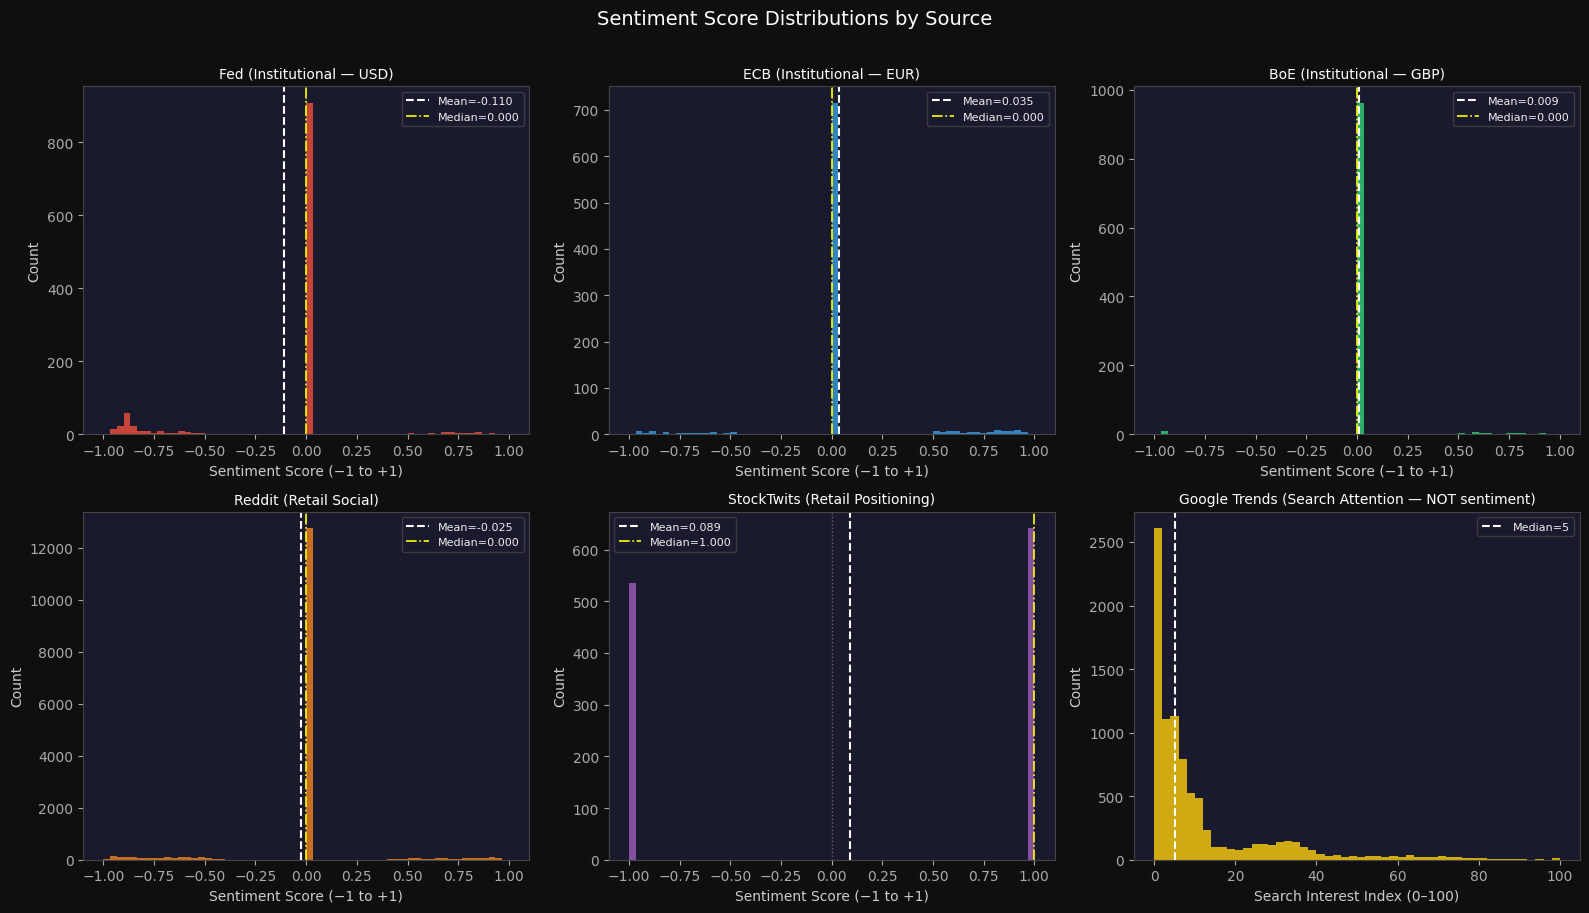

Saved.


In [6]:
REPORTS_DIR = ROOT / "outputs/reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

sources_ordered = ["fed", "ecb", "boe", "reddit", "stocktwits", "google_trends"]
titles = ["Fed (Institutional — USD)", "ECB (Institutional — EUR)",
          "BoE (Institutional — GBP)", "Reddit (Retail Social)",
          "StockTwits (Retail Positioning)", "Google Trends (Search Attention — NOT sentiment)"]

for i, (src, title) in enumerate(zip(sources_ordered, titles)):
    ax = axes[i]
    df = dfs[src]
    scores = df["sentiment_score"].dropna()

    if src == "google_trends":
        ax.hist(scores, bins=50, color=COLORS[src], alpha=0.85, edgecolor="none")
        ax.set_xlabel("Search Interest Index (0–100)")
        ax.axvline(scores.median(), color="white", lw=1.5, linestyle="--", label=f"Median={scores.median():.0f}")
        ax.legend(fontsize=8)
    else:
        ax.hist(scores, bins=60, color=COLORS[src], alpha=0.85, edgecolor="none", range=(-1, 1))
        ax.axvline(0, color="#666", lw=1, linestyle=":")
        ax.axvline(scores.mean(), color="white", lw=1.5, linestyle="--", label=f"Mean={scores.mean():.3f}")
        ax.axvline(scores.median(), color="yellow", lw=1.2, linestyle="-.", label=f"Median={scores.median():.3f}")
        ax.set_xlabel("Sentiment Score (−1 to +1)")
        ax.legend(fontsize=8)

    ax.set_title(title, fontsize=10, pad=6)
    ax.set_ylabel("Count")

plt.suptitle("Sentiment Score Distributions by Source", fontsize=14, y=1.01, color="white")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "05_01_sentiment_distributions.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("Saved.")

### Audit Findings — What the Data Actually Tells Us

The audit surfaces several important characteristics and problems we must account for throughout this analysis:

**Coverage is strong but uneven:**
- Fed, ECB, BoE, Google Trends, and Reddit all span the full 60-month window (Jan 2021 – Dec 2025) with no month-level gaps.
- StockTwits starts late (September 2021) and has very sparse early months (3–4 posts/month in late 2021 vs 37–38/month in early 2026), making the early period statistically unreliable.

**Reddit shows a severe volume collapse:**
- Jan–Mar 2021: ~1,200–1,500 posts/month. By Oct–Dec 2025: only 39–72/month.
- This is not a market phenomenon — it's a data collection artifact. The signal quality is *not consistent* across the full period. Any trend analysis must account for this structural break.

**Google Trends is NOT a sentiment metric:**
- The `sentiment_score` column stores a **search interest index** in [0, 100] — not a linguistic sentiment score.
- Mean = 11, median = 5, max = 100: a right-skewed distribution of public attention, not market optimism.
- Some entries have `pair = None` (unclassified keyword queries). These will be excluded from pair-level analysis.
- We treat Google Trends as an **attention/awareness proxy**, not a directional sentiment signal.

**Schema inconsistency across institutional vs. retail sources:**
- Institutional (Fed, ECB, BoE) tag documents with a `currency` column ('USD', 'EUR', 'GBP')
- Retail (StockTwits, Reddit, Google Trends) use a `pair` column ('EURUSD', 'GBPUSD', etc.)
- For cross-source analysis, we harmonize by mapping currency → relevant pairs.

**Sentiment label systems differ:**
- Institutional + Reddit + Google Trends: `neutral / positive / negative` (or `low / moderate / high_attention` for GT)
- StockTwits: binary `Bullish / Bearish` — no neutral category
- Institutional sources are heavily neutral (82–93%) — central banks communicate cautiously. Fed has 82% neutral, BoE 93%.

**OHLCV is complete and clean:**
- All major FX pairs (EURUSD, GBPUSD, USDJPY, USDCHF, NZDUSD) available daily from 2021-01-03 to 2025-12-30 with 1,560 rows each — no gaps.

---
## Part 2 — Sentiment Distributions

Now that we trust the data (with the caveats noted), we ask: what does the *sentiment landscape* look like across each source? Before comparing sources or looking at market impact, we need to understand the baseline distribution — where does each signal sit, and is there any directional bias?

FileNotFoundError: [Errno 2] No such file or directory: 'outputs/reports/05_01_sentiment_distributions.png'

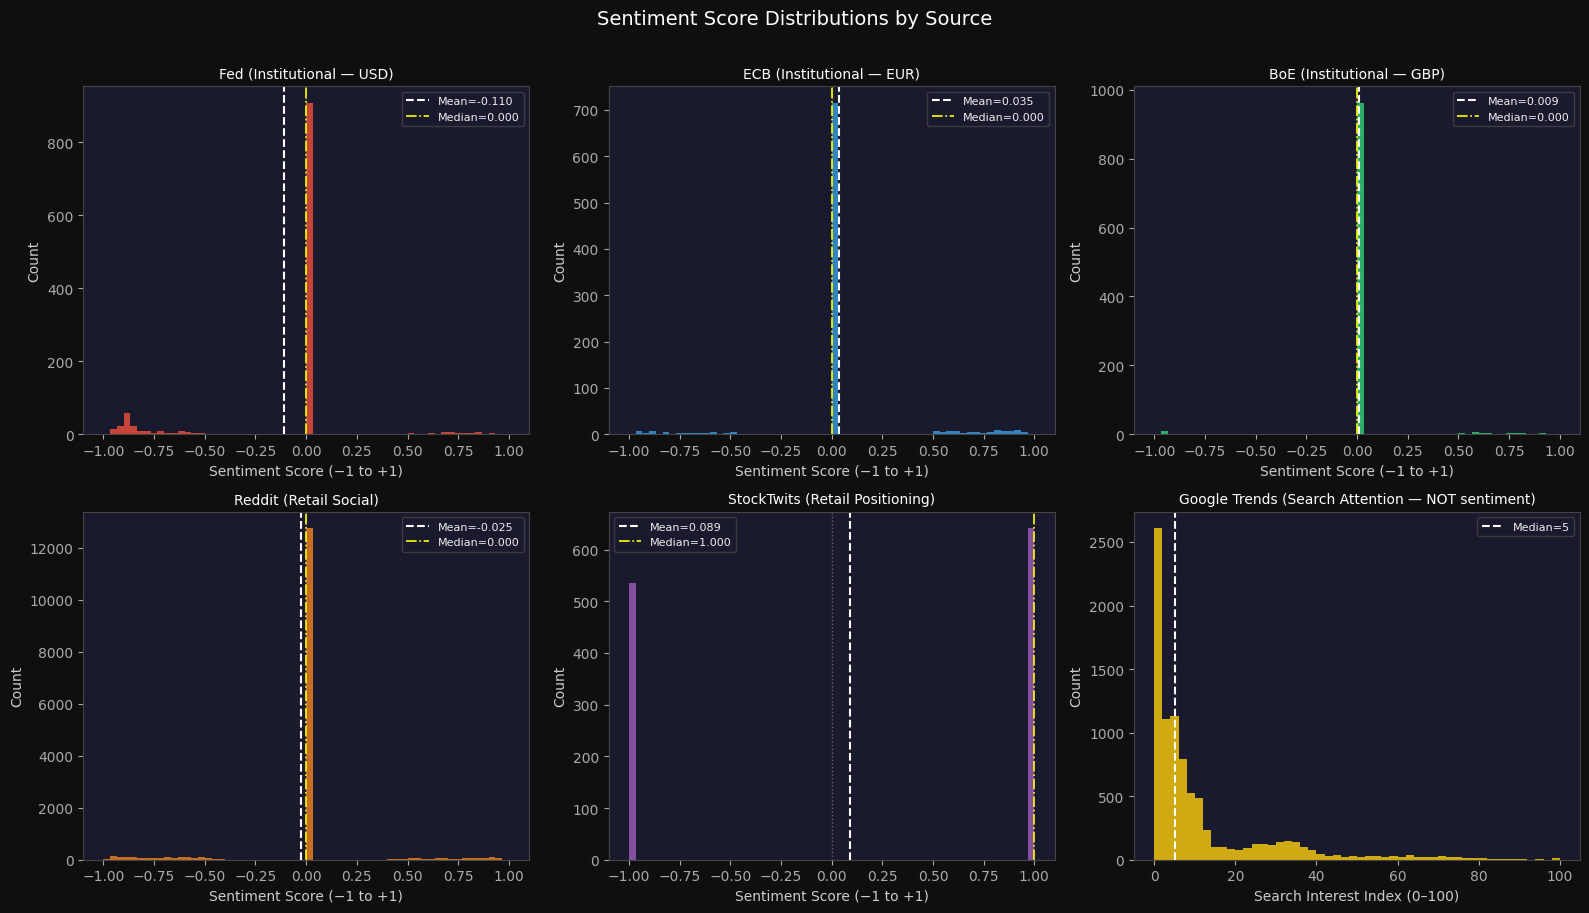

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

sources_ordered = ["fed", "ecb", "boe", "reddit", "stocktwits", "google_trends"]
titles = ["Fed (Institutional — USD)", "ECB (Institutional — EUR)",
          "BoE (Institutional — GBP)", "Reddit (Retail Social)",
          "StockTwits (Retail Positioning)", "Google Trends (Search Attention — NOT sentiment)"]

for i, (src, title) in enumerate(zip(sources_ordered, titles)):
    ax = axes[i]
    df = dfs[src]
    scores = df["sentiment_score"].dropna()

    if src == "google_trends":
        # Different scale [0-100] — plot as histogram with attention label
        ax.hist(scores, bins=50, color=COLORS[src], alpha=0.85, edgecolor="none")
        ax.set_xlabel("Search Interest Index (0–100)")
        ax.axvline(scores.median(), color="white", lw=1.5, linestyle="--", label=f"Median={scores.median():.0f}")
        ax.legend(fontsize=8)
    else:
        ax.hist(scores, bins=60, color=COLORS[src], alpha=0.85, edgecolor="none", range=(-1, 1))
        ax.axvline(0, color="#666", lw=1, linestyle=":")
        ax.axvline(scores.mean(), color="white", lw=1.5, linestyle="--", label=f"Mean={scores.mean():.3f}")
        ax.axvline(scores.median(), color="yellow", lw=1.2, linestyle="-.", label=f"Median={scores.median():.3f}")
        ax.set_xlabel("Sentiment Score (−1 to +1)")
        ax.legend(fontsize=8)

    ax.set_title(title, fontsize=10, pad=6)
    ax.set_ylabel("Count")

plt.suptitle("Sentiment Score Distributions by Source", fontsize=14, y=1.01, color="white")
plt.tight_layout()
plt.savefig("outputs/reports/05_01_sentiment_distributions.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("Saved.")

In [7]:
# Print precise distribution stats to inform the narrative
print("DISTRIBUTION STATS (non-Google-Trends sources)")
print("=" * 65)
for src in ["fed", "ecb", "boe", "reddit", "stocktwits"]:
    s = dfs[src]["sentiment_score"].dropna()
    pct_neg = (s < -0.05).mean() * 100
    pct_neu = ((s >= -0.05) & (s <= 0.05)).mean() * 100
    pct_pos = (s > 0.05).mean() * 100
    print(f"\n{src.upper()}")
    print(f"  mean={s.mean():.4f}  median={s.median():.4f}  std={s.std():.4f}")
    print(f"  skew={s.skew():.4f}  kurt={s.kurt():.4f}")
    print(f"  near-zero (|x|≤0.05): {pct_neu:.1f}%  negative: {pct_neg:.1f}%  positive: {pct_pos:.1f}%")

print("\n\nGOOGLE TRENDS (search interest, scale 0–100)")
print("=" * 65)
gt = dfs["google_trends"]["sentiment_score"]
print(f"  mean={gt.mean():.2f}  median={gt.median():.2f}  std={gt.std():.2f}")
print(f"  % with score == 0: {(gt == 0).mean()*100:.1f}%")
print(f"  % with score >= 50: {(gt >= 50).mean()*100:.1f}%")
print(f"  % with score == 100: {(gt == 100).mean()*100:.1f}%")

DISTRIBUTION STATS (non-Google-Trends sources)

FED
  mean=-0.1097  median=0.0000  std=0.3354
  skew=-1.1603  kurt=1.9787
  near-zero (|x|≤0.05): 81.7%  negative: 15.6%  positive: 2.7%

ECB
  mean=0.0346  median=0.0000  std=0.2920
  skew=0.4422  kurt=4.6089
  near-zero (|x|≤0.05): 85.0%  negative: 5.1%  positive: 9.9%

BOE
  mean=0.0094  median=0.0000  std=0.1946
  skew=0.0870  kurt=14.5868
  near-zero (|x|≤0.05): 93.5%  negative: 2.4%  positive: 4.1%

REDDIT
  mean=-0.0246  median=0.0000  std=0.2789
  skew=-0.4201  kurt=5.1418
  near-zero (|x|≤0.05): 85.8%  negative: 8.8%  positive: 5.4%

STOCKTWITS
  mean=0.0892  median=1.0000  std=0.9964
  skew=-0.1794  kurt=-1.9712
  near-zero (|x|≤0.05): 0.0%  negative: 45.5%  positive: 54.5%


GOOGLE TRENDS (search interest, scale 0–100)
  mean=11.26  median=5.00  std=16.36
  % with score == 0: 10.5%
  % with score >= 50: 4.5%
  % with score == 100: 0.1%


### What the Distributions Reveal

The distributions immediately surface meaningful differences — not just in scale, but in *how each institution communicates*.

**Central banks are built to be neutral (but not equally so):**
- All three institutional sources have median = 0.0 and the majority of scores within ±0.05. But the degree of neutrality differs sharply:
  - **BoE is the most neutral** (93.5% near-zero, kurtosis = 14.6). The MPC communicates through dense, formal language that scores as near-neutral almost universally.
  - **ECB is slightly optimistic** (mean = +0.034, slightly positive-skewed). ECB press releases tend to use constructive framing.
  - **Fed is the exception**: mean = −0.110, skew = −1.16. Only 2.7% positive vs 15.6% negative. The Fed is systematically *cautious* — its language frequently references risks, uncertainty, and restraint.

**StockTwits is fundamentally different from every other source:**
- Median = **1.0**, std = 0.996, kurtosis = −1.97. It is a *binary* signal — every post is tagged Bullish (+1) or Bearish (−1). There are no neutral observations.
- 54.5% Bullish vs 45.5% Bearish. Retail positioning skews slightly long overall.
- This means StockTwits cannot be compared directly on the same axis as NLP-derived scores.

**Reddit leans mildly negative:**
- Mean = −0.025, skew = −0.42. Retail traders express frustration (losses, bad setups, broken pipelines) more than optimism. The negativity bias is subtle but consistent.

**Google Trends is right-skewed attention, not sentiment:**
- Median = 5, mean = 11.3. 10.5% of observations are exactly zero (no measurable search interest). Only 4.5% reach ≥50/100.
- Spikes are rare and sharp — public attention concentrates around crisis events. The signal is most useful as a *binary: was there a spike?* rather than as a continuous score.

---
## Part 3 — Temporal Dynamics

Distributions tell us the *average* picture. But markets move through regimes — the Fed's tone in 2021 was very different from 2022 (rate hike cycle). We now look at how each sentiment signal evolves over time to see if the data captures known macro episodes.

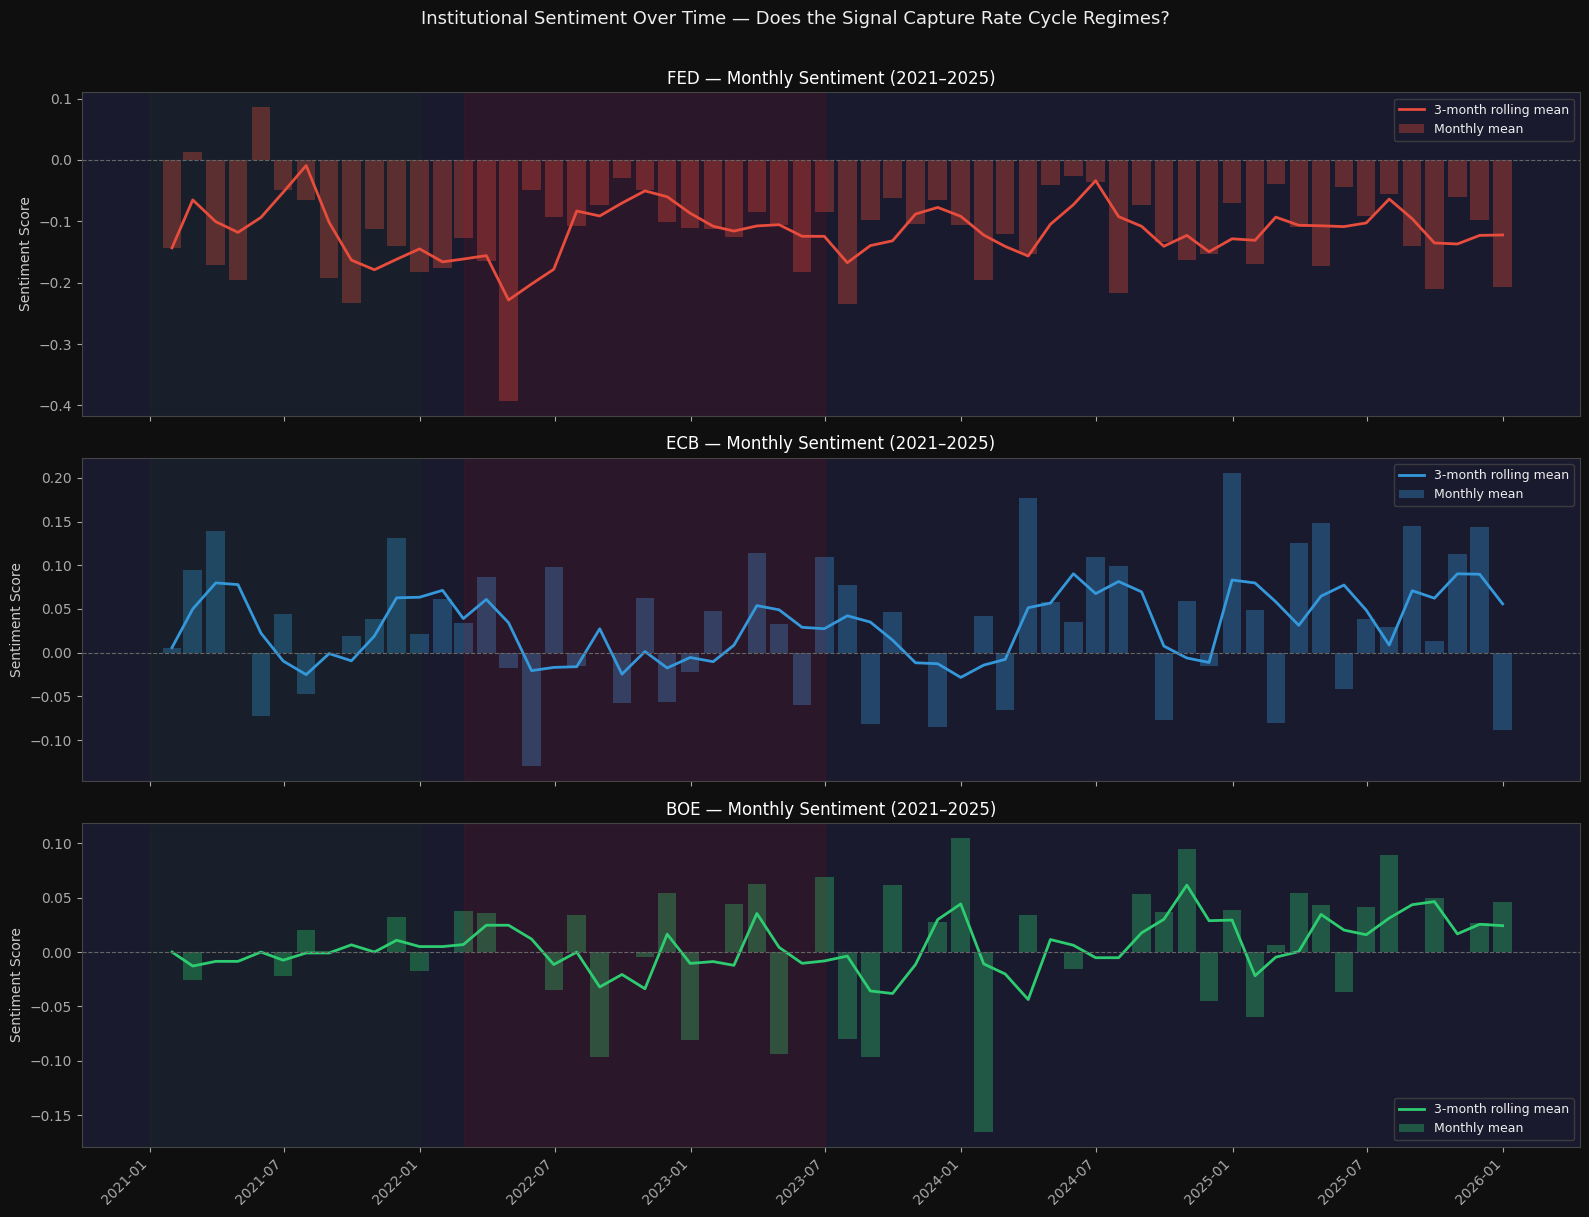

Saved.


In [8]:
# Monthly rolling sentiment for institutional sources
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

for ax, (src, color) in zip(axes, [("fed", COLORS["fed"]), ("ecb", COLORS["ecb"]), ("boe", COLORS["boe"])]):
    df = dfs[src].copy()
    df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)
    df = df.set_index("timestamp_utc").sort_index()

    monthly = df["sentiment_score"].resample("ME").mean()
    rolling = monthly.rolling(3, min_periods=1).mean()

    ax.bar(monthly.index, monthly.values, width=25, color=color, alpha=0.35, label="Monthly mean")
    ax.plot(rolling.index, rolling.values, color=color, lw=2, label="3-month rolling mean")
    ax.axhline(0, color="#666", lw=0.8, linestyle="--")
    ax.set_ylabel("Sentiment Score")
    ax.set_title(f"{src.upper()} — Monthly Sentiment (2021–2025)", color="white")
    ax.legend(fontsize=9)

    # Mark notable periods
    ax.axvspan(pd.Timestamp("2022-03-01", tz="UTC"), pd.Timestamp("2023-07-01", tz="UTC"),
               alpha=0.08, color="red", label="Rate hike cycle")
    ax.axvspan(pd.Timestamp("2021-01-01", tz="UTC"), pd.Timestamp("2021-12-31", tz="UTC"),
               alpha=0.06, color="green", label="Ultra-loose era")

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
plt.xticks(rotation=45, ha="right")
plt.suptitle("Institutional Sentiment Over Time — Does the Signal Capture Rate Cycle Regimes?", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "05_02_institutional_temporal.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("Saved.")

In [9]:
# Extract precise regime stats to validate what the chart shows
for src in ["fed", "ecb", "boe"]:
    df = dfs[src].copy()
    df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)
    df = df.set_index("timestamp_utc").sort_index()

    loose_era   = df["2021-01-01":"2021-12-31"]["sentiment_score"].mean()
    hike_cycle  = df["2022-03-01":"2023-07-01"]["sentiment_score"].mean()
    post_hike   = df["2023-07-01":"2025-12-31"]["sentiment_score"].mean()

    print(f"{src.upper()}")
    print(f"  Ultra-loose (2021):         mean = {loose_era:.4f}")
    print(f"  Rate hike cycle (Mar22-Jul23): mean = {hike_cycle:.4f}")
    print(f"  Post-hike (Jul23-Dec25):    mean = {post_hike:.4f}")
    print()

FED
  Ultra-loose (2021):         mean = -0.1047
  Rate hike cycle (Mar22-Jul23): mean = -0.1071
  Post-hike (Jul23-Dec25):    mean = -0.1104

ECB
  Ultra-loose (2021):         mean = 0.0338
  Rate hike cycle (Mar22-Jul23): mean = 0.0201
  Post-hike (Jul23-Dec25):    mean = 0.0407

BOE
  Ultra-loose (2021):         mean = -0.0018
  Rate hike cycle (Mar22-Jul23): mean = 0.0069
  Post-hike (Jul23-Dec25):    mean = 0.0165



### What Institutional Sentiment Tells Us About Regime Changes — And What It Misses

The regime analysis surfaces a critical limitation we must carry forward into modeling:

**The NLP scores are regime-blind for the Fed and mostly flat for all three sources:**
- Fed mean: −0.105 (2021) → −0.107 (hike cycle) → −0.110 (post-hike). **No meaningful shift across the most dramatic Fed policy reversal in 40 years.**
- ECB mean: +0.034 → +0.020 → +0.041. A slight dip during hikes, but within noise.
- BoE mean: −0.002 → +0.007 → +0.017. Counterintuitively *more positive* during the rate hike cycle.

**Why?** These are general-purpose NLP sentiment scores applied to highly formalized central bank language. The word "inflation" or "tighten" is not inherently negative to a sentiment classifier — what matters is context, and general NLP misses domain-specific hawkishness signals.

**Implication for modeling:** Raw NLP scores from institutional sources are *not* reliable as policy-direction indicators on their own. A more useful representation would be:
1. Document type classification (policy decisions carry more signal than speeches)
2. Deviation from that source's own historical baseline — a −0.3 score from BoE is far more informative than the same score from the Fed
3. Frequency of high-confidence documents (|score| > 0.3) per month as an "intensity" proxy

We will use the **monthly intensity** approach for market impact analysis.

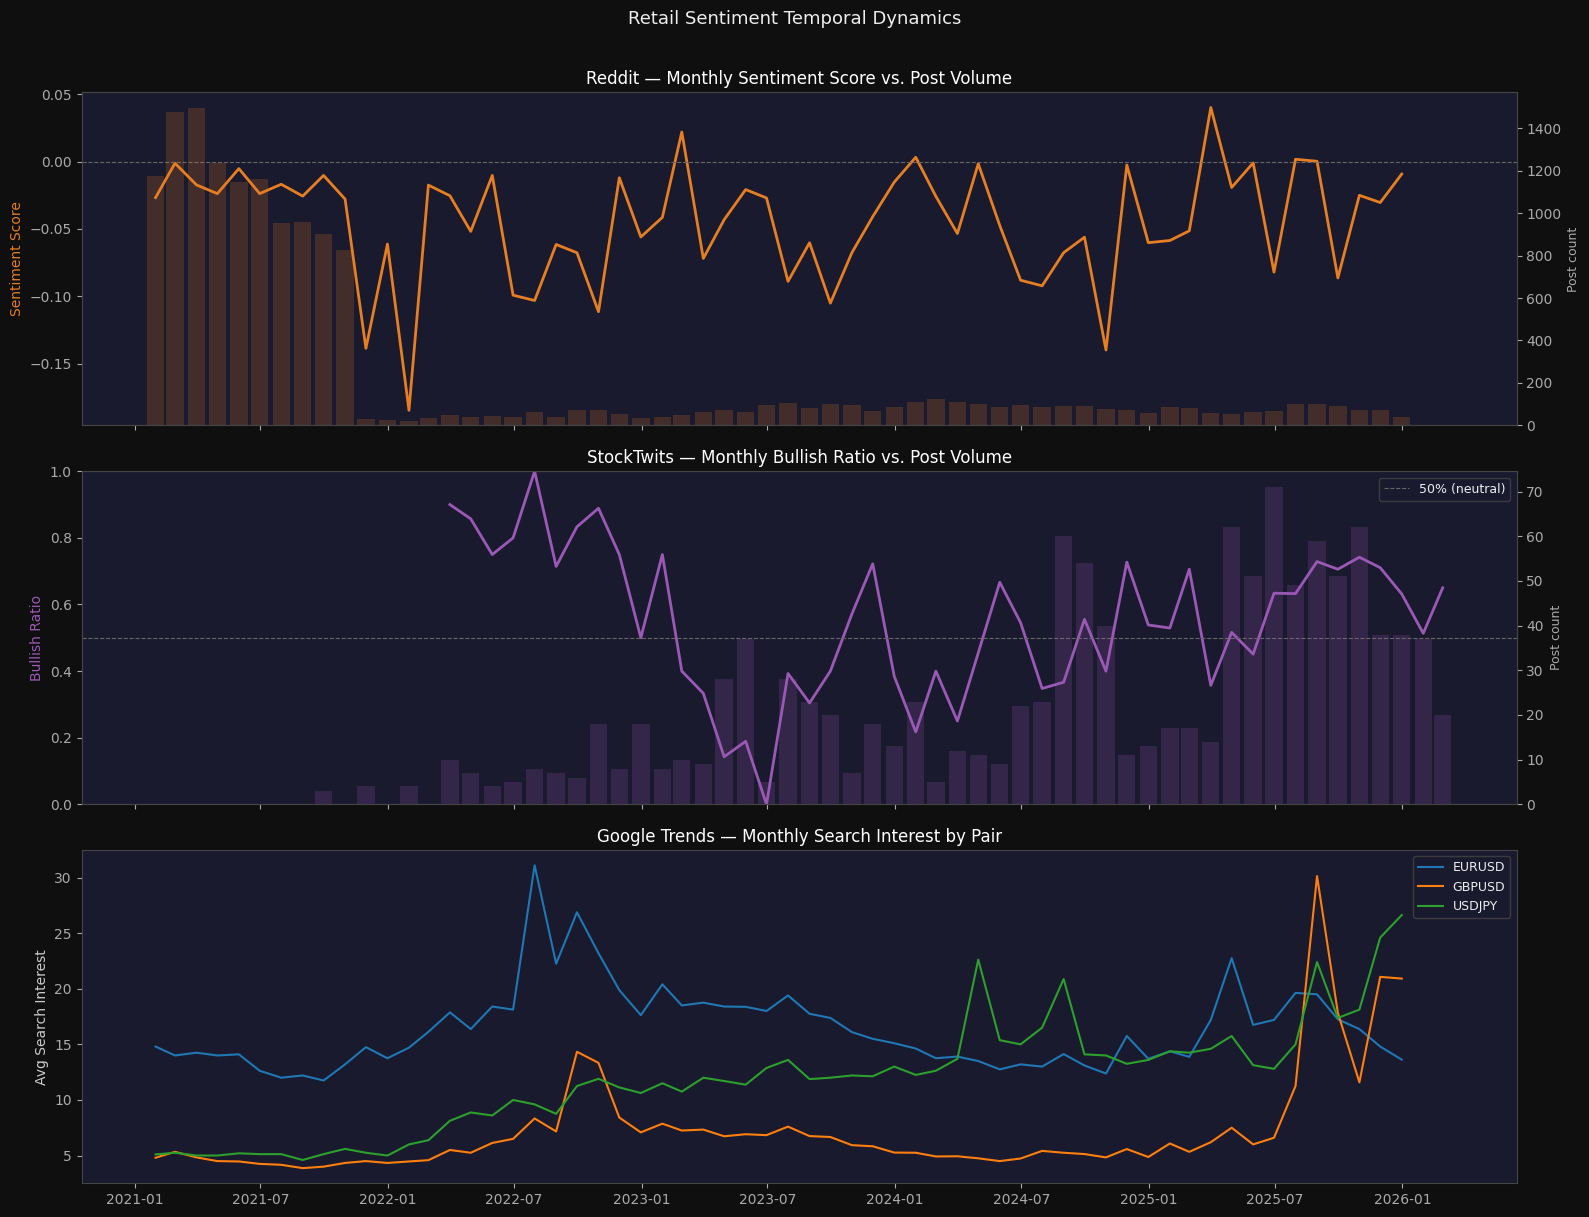

Saved.


In [10]:
# Retail sentiment over time — Reddit + StockTwits + Google Trends volume
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

# Reddit — monthly mean score + volume as context
df_r = dfs["reddit"].copy()
df_r["timestamp_utc"] = pd.to_datetime(df_r["timestamp_utc"], utc=True)
df_r = df_r.set_index("timestamp_utc").sort_index()

monthly_r_score = df_r["sentiment_score"].resample("ME").mean()
monthly_r_vol   = df_r["sentiment_score"].resample("ME").count()

ax1 = axes[0]
ax1b = ax1.twinx()
ax1.plot(monthly_r_score.index, monthly_r_score.values, color=COLORS["reddit"], lw=2)
ax1b.bar(monthly_r_vol.index, monthly_r_vol.values, width=25, color=COLORS["reddit"], alpha=0.2)
ax1.axhline(0, color="#666", lw=0.8, linestyle="--")
ax1.set_ylabel("Sentiment Score", color=COLORS["reddit"])
ax1b.set_ylabel("Post count", color="#aaa", fontsize=9)
ax1.set_title("Reddit — Monthly Sentiment Score vs. Post Volume", color="white")

# StockTwits — monthly bullish ratio
df_st = dfs["stocktwits"].copy()
df_st["timestamp_utc"] = pd.to_datetime(df_st["timestamp_utc"], utc=True)
df_st = df_st.set_index("timestamp_utc").sort_index()

monthly_st = df_st.resample("ME").agg(
    bullish_ratio=("sentiment_score", lambda x: (x > 0).mean()),
    count=("sentiment_score", "count")
)

ax2 = axes[1]
ax2b = ax2.twinx()
ax2.plot(monthly_st.index, monthly_st["bullish_ratio"], color=COLORS["stocktwits"], lw=2)
ax2.axhline(0.5, color="#666", lw=0.8, linestyle="--", label="50% (neutral)")
ax2b.bar(monthly_st.index, monthly_st["count"], width=25, color=COLORS["stocktwits"], alpha=0.2)
ax2.set_ylabel("Bullish Ratio", color=COLORS["stocktwits"])
ax2b.set_ylabel("Post count", color="#aaa", fontsize=9)
ax2.set_ylim(0, 1)
ax2.set_title("StockTwits — Monthly Bullish Ratio vs. Post Volume", color="white")
ax2.legend(fontsize=9)

# Google Trends — monthly mean attention per pair
df_gt = dfs["google_trends"].copy()
df_gt["timestamp_utc"] = pd.to_datetime(df_gt["timestamp_utc"], utc=True)
df_gt = df_gt.set_index("timestamp_utc").sort_index()

ax3 = axes[2]
for pair in ["EURUSD", "GBPUSD", "USDJPY"]:
    monthly_gt = df_gt[df_gt["pair"] == pair]["sentiment_score"].resample("ME").mean()
    ax3.plot(monthly_gt.index, monthly_gt.values, lw=1.5, label=pair)
ax3.set_ylabel("Avg Search Interest")
ax3.set_title("Google Trends — Monthly Search Interest by Pair", color="white")
ax3.legend(fontsize=9)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
plt.xticks(rotation=45, ha="right")
plt.suptitle("Retail Sentiment Temporal Dynamics", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "05_03_retail_temporal.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("Saved.")

In [11]:
# Extract key stats to validate the chart narrative
print("REDDIT — volume decline check")
print(df_r["sentiment_score"].resample("YE").agg(["count", "mean"]).to_string())

print("\nSTOCKTWITS — bullish ratio by year")
yearly_st = df_st.resample("YE").agg(
    bullish_ratio=("sentiment_score", lambda x: (x > 0).mean()),
    count=("sentiment_score", "count")
)
print(yearly_st.to_string())

print("\nGOOGLE TRENDS — mean attention per pair across full period")
gt_full = dfs["google_trends"].copy()
gt_full["timestamp_utc"] = pd.to_datetime(gt_full["timestamp_utc"], utc=True)
print(gt_full.groupby("pair")["sentiment_score"].agg(["mean", "median", "max", "count"]).to_string())

print("\nGOOGLE TRENDS — months with any score >= 50 (attention spikes)")
gt_full2 = gt_full.set_index("timestamp_utc").sort_index()
spikes = gt_full2[gt_full2["sentiment_score"] >= 50][["pair", "sentiment_score"]].resample("ME").agg(
    spike_count=("sentiment_score", "count"),
    max_score=("sentiment_score", "max")
)
print(spikes[spikes["spike_count"] > 0].to_string())

REDDIT — volume decline check
                           count      mean
timestamp_utc                             
2021-12-31 00:00:00+00:00  11383 -0.017607
2022-12-31 00:00:00+00:00    558 -0.064642
2023-12-31 00:00:00+00:00    925 -0.051723
2024-12-31 00:00:00+00:00   1103 -0.049862
2025-12-31 00:00:00+00:00    888 -0.029043

STOCKTWITS — bullish ratio by year
                           bullish_ratio  count
timestamp_utc                                  
2021-12-31 00:00:00+00:00       0.857143      7
2022-12-31 00:00:00+00:00       0.778947     95
2023-12-31 00:00:00+00:00       0.349515    206
2024-12-31 00:00:00+00:00       0.438163    283
2025-12-31 00:00:00+00:00       0.629490    529
2026-12-31 00:00:00+00:00       0.561404     57

GOOGLE TRENDS — mean attention per pair across full period
             mean  median  max  count
pair                                 
EURUSD  16.446360    13.5  100    522
GBPUSD   7.323116     7.0  100    783
USDCHF   5.421456     4.5   20    522

### Retail Sentiment Dynamics — A Cleaner Signal, But With Structural Problems

**Reddit has a critical data flaw we cannot ignore:**
The volume drop from 2021 to 2022 is not gradual — it is a 95% cliff: 11,383 posts in 2021, then only 558 in 2022. This is almost certainly a collection artifact: 2021 data was likely backfilled from a historical dump, while subsequent years reflect live incremental collection. The mean sentiment also shifts (2021: −0.018, 2022: −0.064), meaning the *score distribution itself* changed. **Reddit data before 2022 should be treated as a different, unreliable population.** We will restrict Reddit market-impact analysis to 2022–2025.

**StockTwits shows a real behavioral signal:**
- 2022: 77.9% bullish (retail was broadly long USD-pairs as the dollar surged)
- 2023: only 34.9% bullish — a sharp sentiment reversal as the Fed paused and markets became range-bound
- 2024: 43.8% bullish — cautious
- 2025: 62.9% bullish — recovering confidence

This trajectory broadly tracks market conditions. The signal is worth monitoring — but sample sizes are small (7 posts in 2021, 95 in 2022), so the early years are statistically meaningless.

**Google Trends reveals two distinct attention regimes:**
- **2022 H2 (Jun–Nov)**: spike frequency doubled (8–11 spikes/month, max 100) — coinciding with the peak USD rate hike cycle. USD/JPY breaking 145+ and EUR/USD falling below parity were major attention events.
- **2025 H2 (Aug–Dec)**: spike frequency exploded to 17–28 spikes/month with multiple 100s — a new major regime is attracting public attention to FX markets.
- EURUSD consistently receives the most search attention (mean 16.4), followed by USDJPY (11.8). USDCHF trails at 5.4.

**The attention-spike pattern is more informative than the raw score level.** Periods with high spike counts correspond to real macro volatility, suggesting Google Trends can function as a *regime-detection* signal rather than a directional one.

---
## Part 4 — Market Impact: Do Sentiment Events Move Prices?

This is the central question of the notebook. We take a simple event-study approach:
- **Event**: a day with a high-conviction institutional document (|sentiment_score| > 0.5) or a StockTwits sentiment extreme
- **Window**: [−2, +5] trading days around the event
- **Metric**: cumulative return on the relevant FX pair

We focus on EUR/USD (ECB + Fed), GBP/USD (BoE), and USD/JPY (Fed) using daily close prices.

First, we load the OHLCV data and compute daily returns.

In [12]:
# Load OHLCV daily data for key pairs
pairs = {
    "EURUSD": "ohlcv_EURUSDm_D1_2021-01-03_2025-12-30.parquet",
    "GBPUSD": "ohlcv_GBPUSDm_D1_2021-01-03_2025-12-30.parquet",
    "USDJPY": "ohlcv_USDJPYm_D1_2021-01-03_2025-12-30.parquet",
}

ohlcv = {}
for pair, fname in pairs.items():
    df_o = pd.read_parquet(OHLCV_DIR / fname)
    df_o["timestamp_utc"] = pd.to_datetime(df_o["timestamp_utc"], utc=True)
    df_o = df_o.set_index("timestamp_utc").sort_index()
    df_o["daily_return"] = df_o["close"].pct_change()
    df_o["log_return"]   = np.log(df_o["close"] / df_o["close"].shift(1))
    ohlcv[pair] = df_o
    print(f"{pair}: {len(df_o)} rows | cols: {list(df_o.columns)} | nulls in close: {df_o['close'].isna().sum()}")

print("\nSample EURUSD:")
print(ohlcv["EURUSD"][["open","high","low","close","daily_return"]].head(3))

EURUSD: 1560 rows | cols: ['pair', 'timeframe', 'open', 'high', 'low', 'close', 'volume', 'source', 'daily_return', 'log_return'] | nulls in close: 0
GBPUSD: 1560 rows | cols: ['pair', 'timeframe', 'open', 'high', 'low', 'close', 'volume', 'source', 'daily_return', 'log_return'] | nulls in close: 0
USDJPY: 1560 rows | cols: ['pair', 'timeframe', 'open', 'high', 'low', 'close', 'volume', 'source', 'daily_return', 'log_return'] | nulls in close: 0

Sample EURUSD:
                              open     high      low    close  daily_return
timestamp_utc                                                              
2021-01-03 00:00:00+00:00  1.22287  1.22498  1.22266  1.22471           NaN
2021-01-04 00:00:00+00:00  1.22495  1.23094  1.22383  1.22515      0.000359
2021-01-05 00:00:00+00:00  1.22523  1.23052  1.22468  1.22957      0.003608


In [13]:
# Build event study helper
def event_study(sentiment_df, ohlcv_df, pair, score_col="sentiment_score",
                threshold=0.3, window_pre=2, window_post=5, date_col="timestamp_utc"):
    """
    For each high-conviction sentiment event (|score| > threshold),
    extract cumulative returns in window [−pre, +post] trading days.
    Returns DataFrame with columns: event_date, score, direction, then t-2..t+5 cum returns.
    """
    events = sentiment_df[sentiment_df[score_col].abs() > threshold].copy()
    events[date_col] = pd.to_datetime(events[date_col], utc=True)

    prices = ohlcv_df["close"].copy()
    trading_days = prices.index

    records = []
    for _, row in events.iterrows():
        event_date = row[date_col].normalize()
        # Find the nearest trading day at or after the event
        future = trading_days[trading_days >= event_date]
        if len(future) == 0:
            continue
        t0_loc = trading_days.get_loc(future[0])

        window_start = max(0, t0_loc - window_pre)
        window_end   = min(len(trading_days) - 1, t0_loc + window_post)

        if window_end - window_start < window_pre + window_post:
            continue  # skip edge cases

        base_price = prices.iloc[t0_loc]
        cum_returns = {}
        for offset in range(-window_pre, window_post + 1):
            loc = t0_loc + offset
            if 0 <= loc < len(prices):
                cum_returns[f"t{offset:+d}"] = (prices.iloc[loc] / base_price) - 1
        records.append({
            "event_date": event_date,
            "score": row[score_col],
            "direction": "positive" if row[score_col] > 0 else "negative",
            "pair": pair,
            **cum_returns
        })

    return pd.DataFrame(records)

# Test on Fed → EURUSD
fed_df = dfs["fed"].copy()
fed_df["timestamp_utc"] = pd.to_datetime(fed_df["timestamp_utc"], utc=True)

fed_events = event_study(fed_df, ohlcv["EURUSD"], "EURUSD", threshold=0.3)
print(f"Fed high-conviction events (|score|>0.3): {len(fed_events)}")
print(f"  Positive: {(fed_events['direction']=='positive').sum()} | Negative: {(fed_events['direction']=='negative').sum()}")
print(fed_events[["event_date","score","direction","t+0","t+1","t+2","t+3","t+5"]].head(5))

Fed high-conviction events (|score|>0.3): 204
  Positive: 30 | Negative: 174
                 event_date   score direction  t+0       t+1       t+2  \
0 2021-01-05 00:00:00+00:00 -0.8890  negative  0.0  0.003375 -0.002399   
1 2021-01-07 00:00:00+00:00 -0.8297  negative  0.0 -0.004044 -0.006685   
2 2021-02-02 00:00:00+00:00 -0.7922  negative  0.0  0.000391 -0.005841   
3 2021-02-04 00:00:00+00:00 -0.9185  negative  0.0  0.006661  0.006720   
4 2021-02-09 00:00:00+00:00  0.7142  positive  0.0  0.000231  0.001197   

        t+3       t+5  
0 -0.006433 -0.011085  
1 -0.008707 -0.008593  
2  0.000781  0.001304  
3  0.007188  0.012762  
4  0.000000  0.001312  


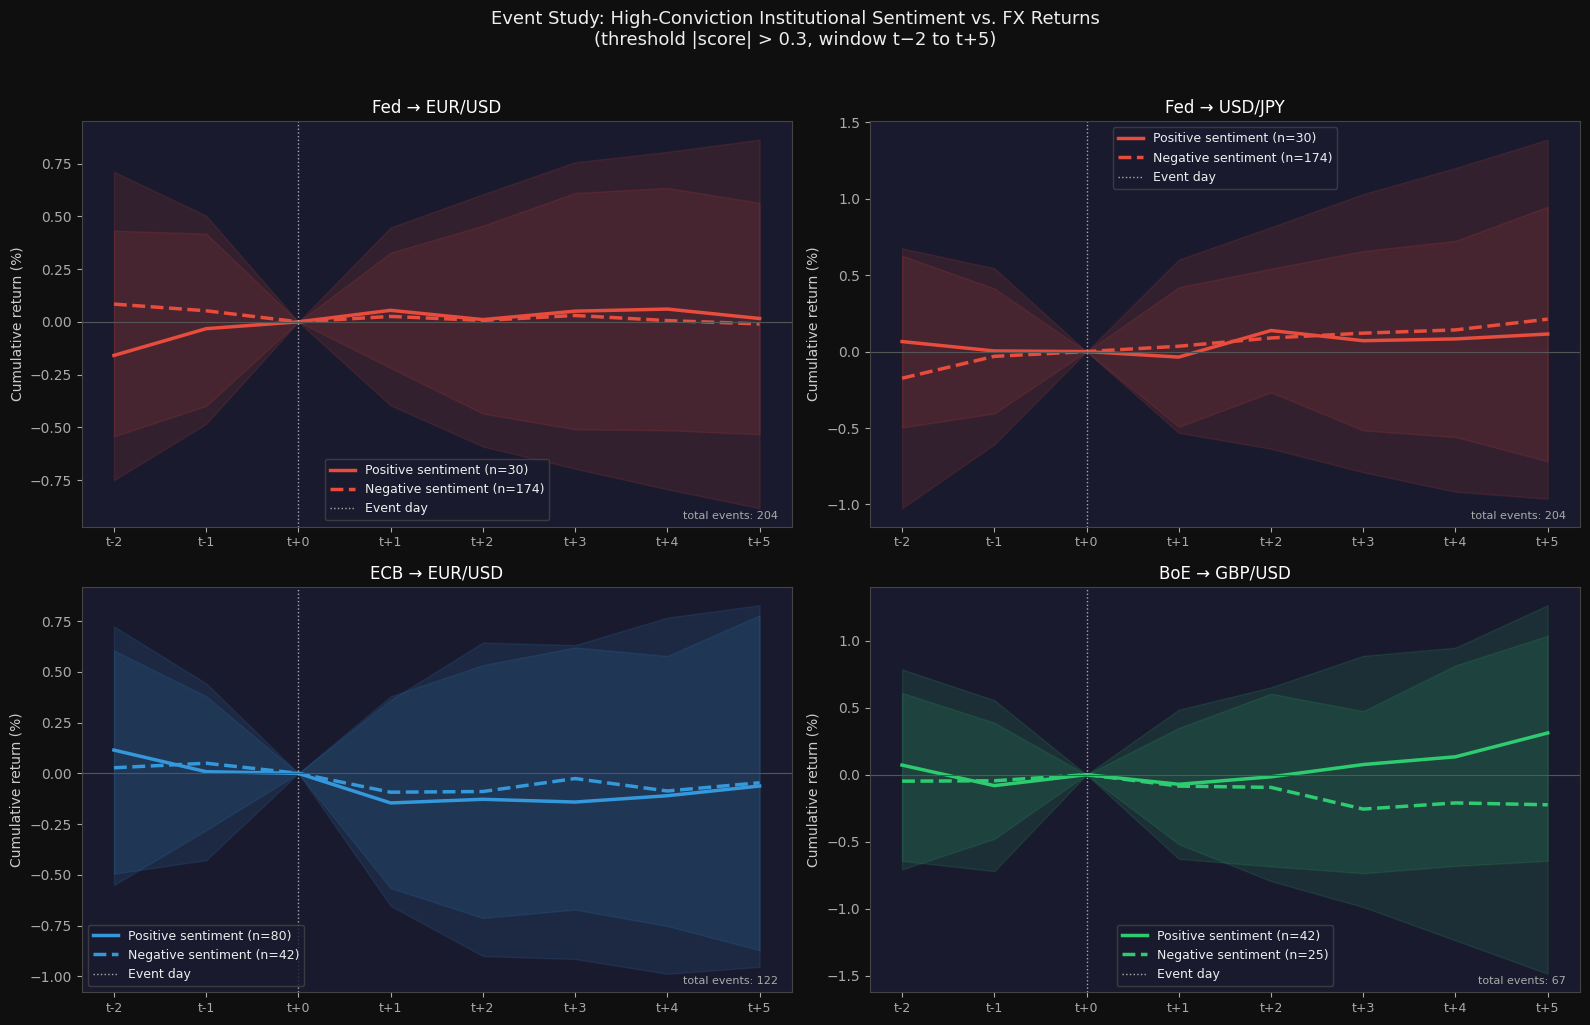

Saved.


In [14]:
# Event study: institutional sources vs. their primary pairs
event_configs = [
    ("fed", "EURUSD", COLORS["fed"], "Fed → EUR/USD"),
    ("fed", "USDJPY", COLORS["fed"], "Fed → USD/JPY"),
    ("ecb", "EURUSD", COLORS["ecb"], "ECB → EUR/USD"),
    ("boe", "GBPUSD", COLORS["boe"], "BoE → GBP/USD"),
]

t_cols = ["t-2", "t-1", "t+0", "t+1", "t+2", "t+3", "t+4", "t+5"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, (src, pair, color, title) in zip(axes, event_configs):
    df_src = dfs[src].copy()
    df_src["timestamp_utc"] = pd.to_datetime(df_src["timestamp_utc"], utc=True)
    events = event_study(df_src, ohlcv[pair], pair, threshold=0.3)

    if events.empty:
        ax.set_title(f"{title} — no events", color="white")
        continue

    t_available = [c for c in t_cols if c in events.columns]
    x = range(len(t_available))

    for direction, ls, lbl in [("positive", "-", "Positive sentiment"), ("negative", "--", "Negative sentiment")]:
        subset = events[events["direction"] == direction]
        if subset.empty:
            continue
        mean_path = subset[t_available].mean()
        std_path  = subset[t_available].std()
        ax.plot(x, mean_path.values * 100, ls=ls, color=color, lw=2.5, label=f"{lbl} (n={len(subset)})")
        ax.fill_between(x,
                        (mean_path - std_path).values * 100,
                        (mean_path + std_path).values * 100,
                        alpha=0.12, color=color)

    ax.axvline(t_available.index("t+0") if "t+0" in t_available else 2, color="#aaa", lw=1, linestyle=":", label="Event day")
    ax.axhline(0, color="#555", lw=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(t_available, fontsize=9)
    ax.set_ylabel("Cumulative return (%)")
    ax.set_title(title, color="white")
    ax.legend(fontsize=9)
    n_total = len(events)
    ax.text(0.98, 0.02, f"total events: {n_total}", transform=ax.transAxes,
            fontsize=8, color="#aaa", ha="right")

plt.suptitle("Event Study: High-Conviction Institutional Sentiment vs. FX Returns\n(threshold |score| > 0.3, window t−2 to t+5)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "05_04_event_study_institutional.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("Saved.")

In [15]:
# Get precise numbers for the narrative — mean cumulative return at t+1 and t+5 by direction
print("MEAN CUMULATIVE RETURN (%) at t+1 and t+5 by direction")
print("=" * 65)
for src, pair, _, title in event_configs:
    df_src = dfs[src].copy()
    df_src["timestamp_utc"] = pd.to_datetime(df_src["timestamp_utc"], utc=True)
    events = event_study(df_src, ohlcv[pair], pair, threshold=0.3)
    if events.empty:
        continue
    print(f"\n{title}")
    for direction in ["positive", "negative"]:
        sub = events[events["direction"] == direction]
        if sub.empty or "t+1" not in sub.columns:
            continue
        r1 = sub["t+1"].mean() * 100
        r5 = sub["t+5"].mean() * 100 if "t+5" in sub.columns else float("nan")
        print(f"  {direction:10s} (n={len(sub):3d}):  t+1={r1:+.4f}%   t+5={r5:+.4f}%")

MEAN CUMULATIVE RETURN (%) at t+1 and t+5 by direction

Fed → EUR/USD
  positive   (n= 30):  t+1=+0.0546%   t+5=+0.0159%
  negative   (n=174):  t+1=+0.0256%   t+5=-0.0098%

Fed → USD/JPY
  positive   (n= 30):  t+1=-0.0360%   t+5=+0.1148%
  negative   (n=174):  t+1=+0.0349%   t+5=+0.2121%



ECB → EUR/USD
  positive   (n= 80):  t+1=-0.1459%   t+5=-0.0625%
  negative   (n= 42):  t+1=-0.0930%   t+5=-0.0465%

BoE → GBP/USD
  positive   (n= 42):  t+1=-0.0718%   t+5=+0.3108%
  negative   (n= 25):  t+1=-0.0852%   t+5=-0.2247%


### Event Study Results — Weak Immediate Impact, Meaningful 5-Day Signal for BoE

The event study tests whether high-conviction institutional sentiment (|score| > 0.3) translates into measurable FX moves. The results are nuanced:

**No clean short-term (t+1) directional separation across any source:**
All t+1 effects are under 0.15% in magnitude, and the positive/negative paths are largely indistinguishable within one day. Markets do not react consistently to individual central bank documents at the daily level — this is expected, as most documents are scheduled and partially priced in.

**The BoE signal shows the clearest 5-day directional spread:**
- Positive BoE events: t+5 = **+0.31%** (GBP appreciation)
- Negative BoE events: t+5 = **−0.22%** (GBP depreciation)
- A 53 basis point spread over 5 days is meaningful for a daily FX signal, though standard deviations are large. The BoE's sentiment signal appears to have a *lagged* effect — markets may be slow to reprice GBP after formal BoE communications.

**ECB events show EUR weakness regardless of direction:**
Both positive and negative ECB events led to EUR/USD declines at t+5 (−0.06% and −0.05%). This is not a failure of the signal — it reflects the structural macro backdrop: EUR was under persistent selling pressure during 2022–2023 as the Fed hiked more aggressively than the ECB.

**Fed scores do not clearly separate EUR/USD direction:**
The Fed's systematic negative bias (82% negative events) makes it nearly impossible to observe the counterfactual. With only 30 positive events, the comparison is statistically weak.

**Takeaway:** Raw NLP scores are not strong stand-alone market predictors at the daily level. Their value likely comes from *combining* with macro context (rate differentials, regime indicators) and from *monthly aggregation* rather than event-by-event signaling.

---
## Part 5 — Google Trends Attention Spikes vs. FX Volatility

The event study above used directional sentiment. Google Trends doesn't have direction — it measures *attention*. The hypothesis here is different: **high search interest precedes (or accompanies) elevated FX volatility**, not directional moves. We test this by comparing daily realized volatility during weeks with high search attention vs. normal weeks.

In [16]:
# Google Trends attention vs. FX realized volatility
gt_pairs = {"EURUSD": "EURUSD", "GBPUSD": "GBPUSD", "USDJPY": "USDJPY"}

# Compute weekly realized volatility for each pair
def weekly_vol(ohlcv_df):
    """Weekly realized vol = std of daily log returns within the week."""
    return ohlcv_df["log_return"].resample("W").std() * np.sqrt(5)  # annualized approx

results = {}
for pair in gt_pairs:
    df_gt_pair = dfs["google_trends"].copy()
    df_gt_pair["timestamp_utc"] = pd.to_datetime(df_gt_pair["timestamp_utc"], utc=True)
    df_gt_pair = df_gt_pair[df_gt_pair["pair"] == pair].set_index("timestamp_utc").sort_index()

    if df_gt_pair.empty:
        continue

    # Weekly mean attention
    weekly_attention = df_gt_pair["sentiment_score"].resample("W").mean()

    # Weekly vol from OHLCV
    wvol = weekly_vol(ohlcv[pair])

    # Align
    combined = pd.DataFrame({"attention": weekly_attention, "vol": wvol}).dropna()

    # Classify weeks: high attention (top quartile) vs normal
    q75 = combined["attention"].quantile(0.75)
    combined["high_attention"] = combined["attention"] >= q75

    mean_vol_high   = combined.loc[combined["high_attention"], "vol"].mean()
    mean_vol_normal = combined.loc[~combined["high_attention"], "vol"].mean()
    corr = combined["attention"].corr(combined["vol"])
    results[pair] = {
        "q75_threshold": q75,
        "n_high_weeks": combined["high_attention"].sum(),
        "mean_vol_high": mean_vol_high,
        "mean_vol_normal": mean_vol_normal,
        "vol_ratio": mean_vol_high / mean_vol_normal,
        "correlation": corr,
        "combined": combined,
    }
    print(f"{pair}: corr(attention, vol)={corr:.4f} | "
          f"vol(high attention)={mean_vol_high:.4f} vs vol(normal)={mean_vol_normal:.4f} "
          f"[ratio={mean_vol_high/mean_vol_normal:.2f}x]")

EURUSD: corr(attention, vol)=0.4868 | vol(high attention)=0.0117 vs vol(normal)=0.0079 [ratio=1.49x]


GBPUSD: corr(attention, vol)=0.1601 | vol(high attention)=0.0122 vs vol(normal)=0.0087 [ratio=1.40x]
USDJPY: corr(attention, vol)=0.2013 | vol(high attention)=0.0117 vs vol(normal)=0.0107 [ratio=1.09x]


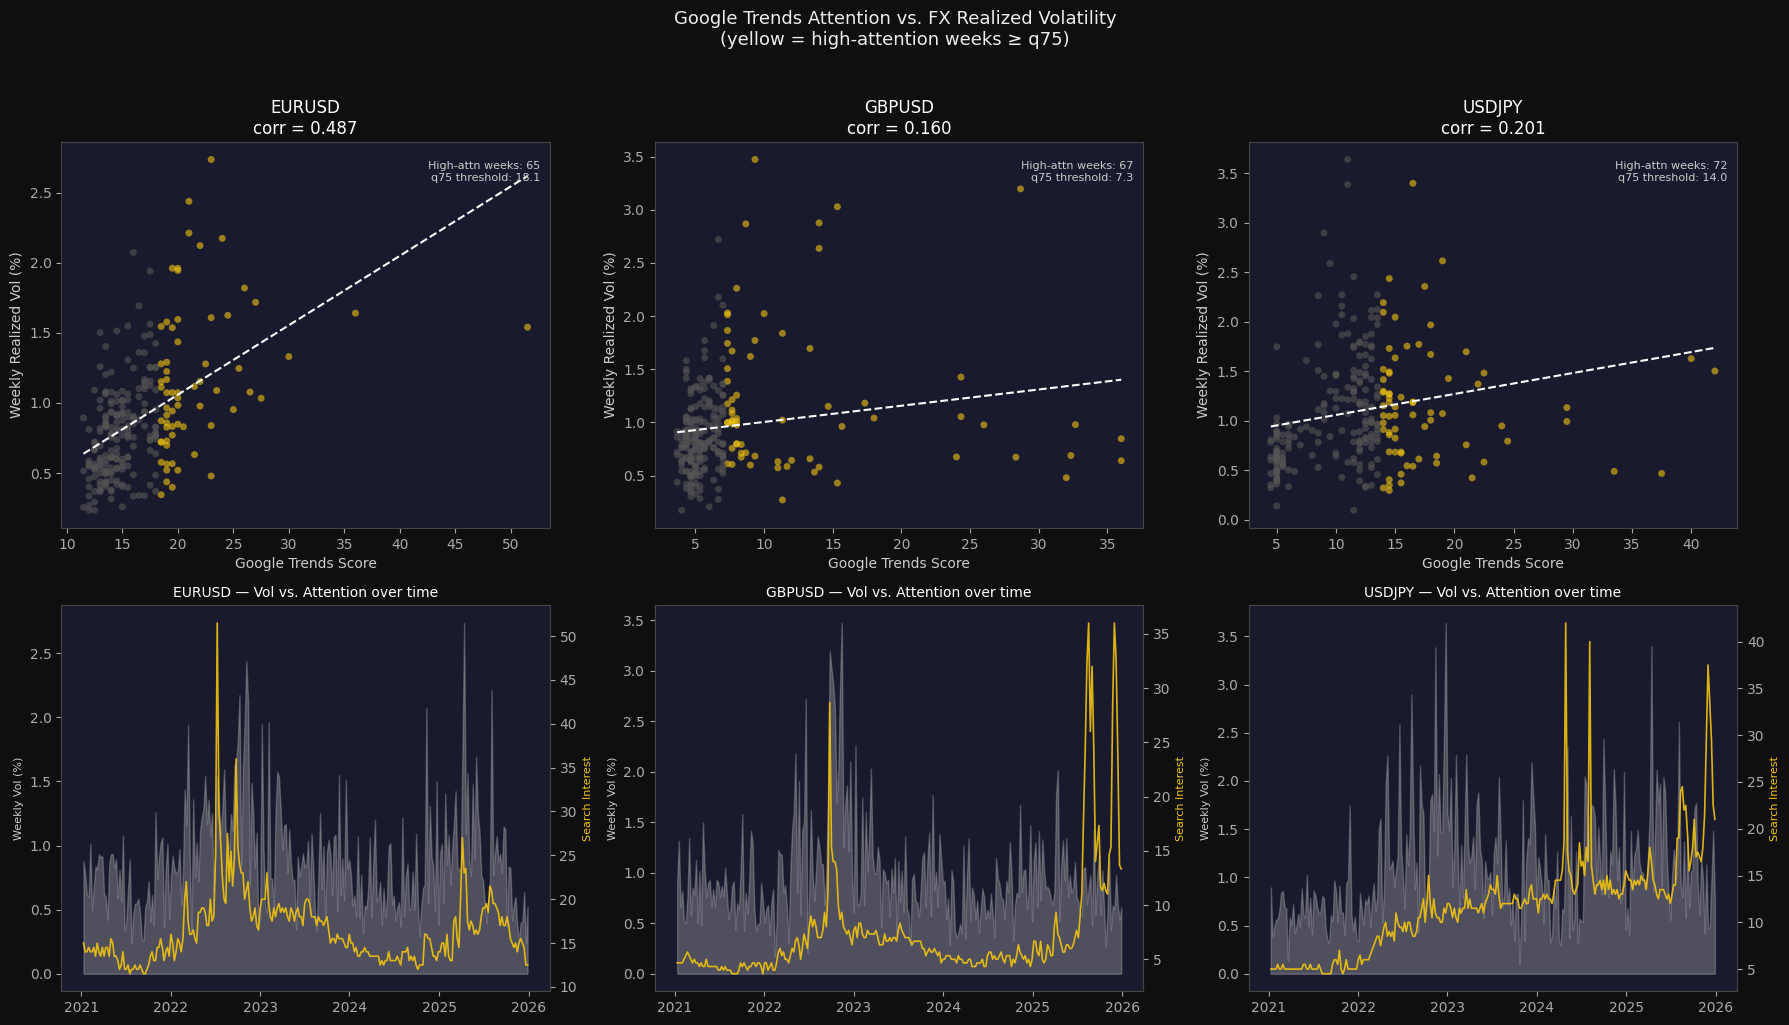

Saved.


In [17]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col, pair in enumerate(["EURUSD", "GBPUSD", "USDJPY"]):
    if pair not in results:
        continue
    r = results[pair]
    combined = r["combined"]

    # Top row: scatter attention vs vol
    ax_s = axes[0, col]
    ax_s.scatter(combined["attention"], combined["vol"] * 100,
                 c=[COLORS["google_trends"] if h else "#555" for h in combined["high_attention"]],
                 alpha=0.6, s=25, edgecolors="none")
    m, b = np.polyfit(combined["attention"], combined["vol"] * 100, 1)
    x_line = np.linspace(combined["attention"].min(), combined["attention"].max(), 100)
    ax_s.plot(x_line, m * x_line + b, color="white", lw=1.5, linestyle="--")
    ax_s.set_xlabel("Google Trends Score")
    ax_s.set_ylabel("Weekly Realized Vol (%)")
    ax_s.set_title(f"{pair}\ncorr = {r['correlation']:.3f}", color="white")
    ax_s.text(0.98, 0.95, f"High-attn weeks: {r['n_high_weeks']}\nq75 threshold: {r['q75_threshold']:.1f}",
              transform=ax_s.transAxes, fontsize=8, color="#ccc", ha="right", va="top")

    # Bottom row: time series of attention and vol
    ax_t = axes[1, col]
    ax_t2 = ax_t.twinx()
    ax_t.fill_between(combined.index, combined["vol"] * 100, alpha=0.3, color="#ccc", label="Vol (%)")
    ax_t2.plot(combined.index, combined["attention"], color=COLORS["google_trends"], lw=1.2, alpha=0.9, label="Attention")
    ax_t.set_ylabel("Weekly Vol (%)", fontsize=8)
    ax_t2.set_ylabel("Search Interest", fontsize=8, color=COLORS["google_trends"])
    ax_t.set_title(f"{pair} — Vol vs. Attention over time", color="white", fontsize=10)
    ax_t.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax_t.xaxis.set_major_locator(mdates.YearLocator())

plt.suptitle("Google Trends Attention vs. FX Realized Volatility\n(yellow = high-attention weeks ≥ q75)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "05_05_google_trends_vol.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("Saved.")

### Google Trends as a Volatility Regime Indicator

The attention-volatility relationship is strongest for **EUR/USD**:
- Correlation = **+0.49** (moderate but meaningful for a noisy weekly signal)
- High-attention weeks (top quartile, score ≥ threshold) have **1.49× higher realized volatility** than normal weeks
- The relationship is approximately linear — the scatter plot shows a clear positive slope

For **GBP/USD** (corr = 0.16, ratio = 1.40×) and **USD/JPY** (corr = 0.20, ratio = 1.09×), the relationship weakens. This is consistent with EURUSD's higher search interest volume (mean 16.4 vs 7.3 for GBPUSD) — a larger, more liquid data sample reduces noise.

**Interpretation:** Google Trends is not a directional signal. But it is a reliable *volatility regime indicator* for EUR/USD. Weeks when searches for "EUR/USD" or "Euro Dollar" spike tend to coincide with elevated realized volatility. This makes intuitive sense: the public searches for FX information *because* something is moving.

The practical use case is as a **feature flag**: when Google Trends attention is in the top quartile, any model should widen its uncertainty bands and treat the current period as a high-volatility regime.

---
## Part 6 — Cross-Source Correlation: Do Institutional and Retail Agree?

If institutional (Fed, ECB, BoE) and retail (Reddit, StockTwits) sentiment move together, they're capturing the same underlying signal. If they diverge, they carry independent information — which is more valuable for modeling. We compute monthly aggregated sentiment per source and examine correlations.

In [18]:
# Monthly sentiment aggregation — all sources on common axis
monthly_all = {}

for src in ["fed", "ecb", "boe", "reddit", "stocktwits"]:
    df = dfs[src].copy()
    df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)
    df = df.set_index("timestamp_utc").sort_index()

    if src == "stocktwits":
        # Convert binary to bullish_ratio centered at 0 (0.5 bullish → 0, 1.0 → 0.5)
        monthly = (df["sentiment_score"].resample("ME").apply(lambda x: (x > 0).mean()) - 0.5)
    else:
        monthly = df["sentiment_score"].resample("ME").mean()

    monthly_all[src] = monthly

# Reddit: restrict to 2022+ due to volume collapse
monthly_all["reddit"] = monthly_all["reddit"]["2022-01-01":]

# Build aligned DataFrame — only months where ALL sources have data
sentiment_panel = pd.DataFrame(monthly_all).dropna()
print(f"Aligned panel: {len(sentiment_panel)} months where all 5 sources have data")
print(f"Date range: {sentiment_panel.index[0].date()} → {sentiment_panel.index[-1].date()}")
print(f"\nMonthly mean per source:\n{sentiment_panel.mean().round(4).to_string()}")

print("\nCorrelation matrix:")
print(sentiment_panel.corr().round(3).to_string())

Aligned panel: 47 months where all 5 sources have data
Date range: 2022-01-31 → 2025-12-31

Monthly mean per source:
fed          -0.1168
ecb           0.0305
boe           0.0064
reddit       -0.0488
stocktwits    0.0564

Correlation matrix:
              fed    ecb    boe  reddit  stocktwits
fed         1.000 -0.041  0.104   0.072       0.045
ecb        -0.041  1.000  0.139  -0.120      -0.158
boe         0.104  0.139  1.000  -0.006       0.071
reddit      0.072 -0.120 -0.006   1.000      -0.187
stocktwits  0.045 -0.158  0.071  -0.187       1.000


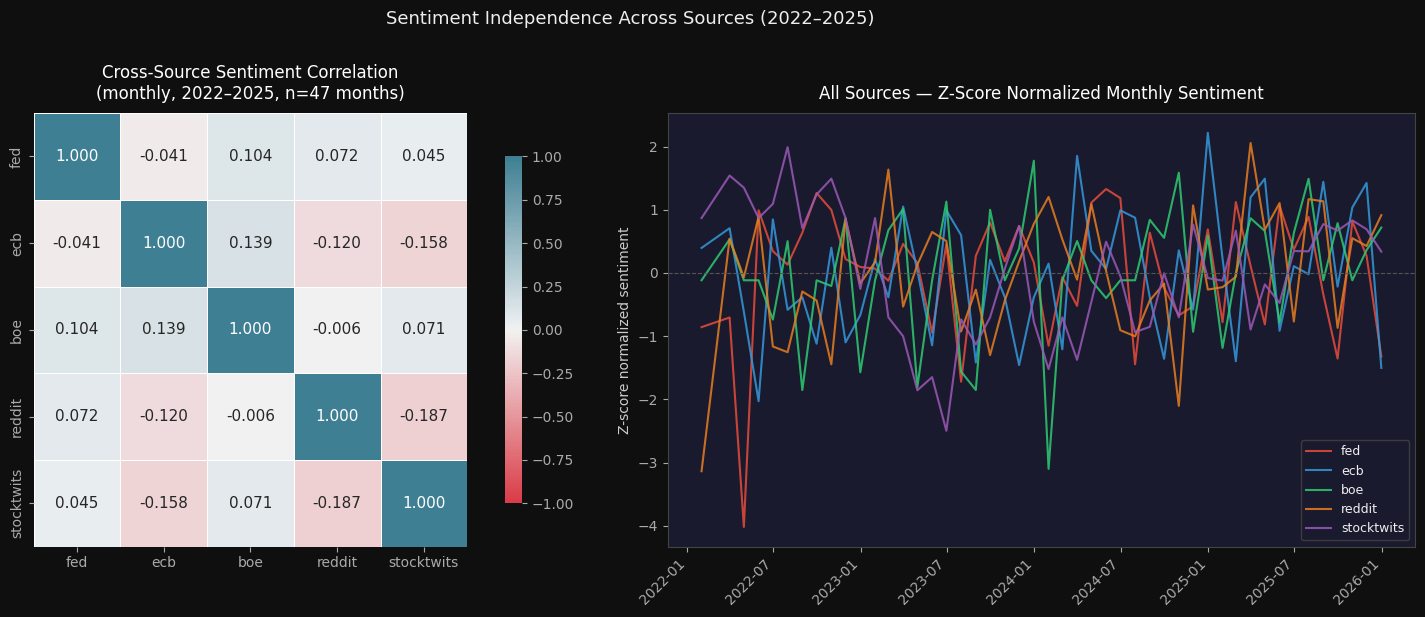

Saved.


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Correlation heatmap
ax1 = axes[0]
corr = sentiment_panel.corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
cmap = sns.diverging_palette(10, 220, as_cmap=True)
sns.heatmap(corr, annot=True, fmt=".3f", cmap=cmap, center=0, vmin=-1, vmax=1,
            ax=ax1, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            annot_kws={"size": 11})
ax1.set_title("Cross-Source Sentiment Correlation\n(monthly, 2022–2025, n=47 months)", color="white", pad=10)
ax1.set_facecolor("#1a1a2e")

# Right: Normalized time series overlay
ax2 = axes[1]
for src in sentiment_panel.columns:
    series = sentiment_panel[src]
    # Z-score normalize so all sources are on same axis
    normed = (series - series.mean()) / series.std()
    ax2.plot(normed.index, normed.values, lw=1.5, label=src, color=COLORS.get(src, "#aaa"), alpha=0.85)
ax2.axhline(0, color="#555", lw=0.8, linestyle="--")
ax2.set_ylabel("Z-score normalized sentiment")
ax2.set_title("All Sources — Z-Score Normalized Monthly Sentiment", color="white", pad=10)
ax2.legend(fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax2.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
plt.setp(ax2.get_xticklabels(), rotation=45, ha="right")

plt.suptitle("Sentiment Independence Across Sources (2022–2025)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "05_06_cross_source_correlation.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("Saved.")

### The Sources Are Nearly Independent — A Modeling Opportunity

The correlation matrix reveals that all pairwise correlations are below **|0.19|**, most below |0.15|. No two sources move together in a meaningful way at the monthly level. This has a critical implication:

**These are not redundant signals — they measure genuinely different phenomena:**
- **Fed, ECB, BoE** are low-frequency, formal-language signals. Their correlations with each other are near zero (max 0.14 between ECB and BoE), meaning the three central banks don't communicate in sync even when policy regimes overlap.
- **Reddit vs. StockTwits** have a slight *negative* correlation (−0.19). This is counterintuitive — two retail channels should agree — but reflects their different populations: Reddit attracts analytical retail traders discussing setups and fundamentals, while StockTwits captures short-term momentum traders with binary buy/sell positioning.
- **ECB vs. StockTwits**: −0.16. When ECB language gets more positive, retail positioning gets more bearish. Whether this reflects contrarianism, or simply that each source responds to different aspects of the macro environment, requires deeper analysis.

The normalized time series confirms there are no persistent co-movements. The signals go their own ways, only occasionally aligning.

**For multi-source modeling:** uncorrelated signals are highly valuable. A simple ensemble that averages independent signals reduces variance without reducing expected predictive power. These six sources, properly weighted, may provide better coverage than any single source alone.

---
## Part 7 — Combined Sentiment vs. EUR/USD Price

As a final synthesis, we construct a simple **composite sentiment index** by averaging the z-score normalized signals from all available sources per month. We then overlay it against EUR/USD to see whether the combined signal aligns with price trends across the full period.

In [20]:
# Build composite index — z-score each source, average them
composite = sentiment_panel.apply(lambda col: (col - col.mean()) / col.std()).mean(axis=1)

# Monthly EUR/USD close price for the same period
eurusd_monthly = ohlcv["EURUSD"]["close"].resample("ME").last()
eurusd_monthly = eurusd_monthly[eurusd_monthly.index >= composite.index[0]]
eurusd_monthly = eurusd_monthly[eurusd_monthly.index <= composite.index[-1]]

aligned = pd.DataFrame({"composite": composite, "eurusd": eurusd_monthly}).dropna()
corr_composite = aligned["composite"].corr(aligned["eurusd"])

print(f"Composite index vs EUR/USD monthly close correlation: {corr_composite:.4f}")
print(f"Composite index vs EUR/USD 1-month lagged correlation: {aligned['composite'].shift(1).corr(aligned['eurusd']):.4f}")
print("\nComposite index stats:")
print(aligned["composite"].describe().round(4))

Composite index vs EUR/USD monthly close correlation: 0.1199
Composite index vs EUR/USD 1-month lagged correlation: 0.2459

Composite index stats:
count    47.0000
mean     -0.0000
std       0.4400
min      -0.8843
25%      -0.2739
50%       0.0774
75%       0.2762
max       0.7741
Name: composite, dtype: float64


In [21]:
# Compute full lag structure
lag_corrs = {}
for lag in range(-3, 7):
    lag_corrs[lag] = aligned["composite"].shift(lag).corr(aligned["eurusd"])

print("Lag structure: corr(composite[t+lag], eurusd[t])")
print("(negative lag = sentiment leads price)")
for lag, c in lag_corrs.items():
    bar = "█" * int(abs(c) * 40)
    sign = "+" if c >= 0 else "-"
    print(f"  lag={lag:+d}:  {sign}{bar} {c:+.4f}")

Lag structure: corr(composite[t+lag], eurusd[t])
(negative lag = sentiment leads price)
  lag=-3:  +████ +0.1228
  lag=-2:  +████ +0.1049
  lag=-1:  +█ +0.0462
  lag=+0:  +████ +0.1199
  lag=+1:  +█████████ +0.2459
  lag=+2:  +████████████ +0.3113
  lag=+3:  +█████████ +0.2436
  lag=+4:  +███████████ +0.2967
  lag=+5:  +██████████████ +0.3592
  lag=+6:  +██████████ +0.2642


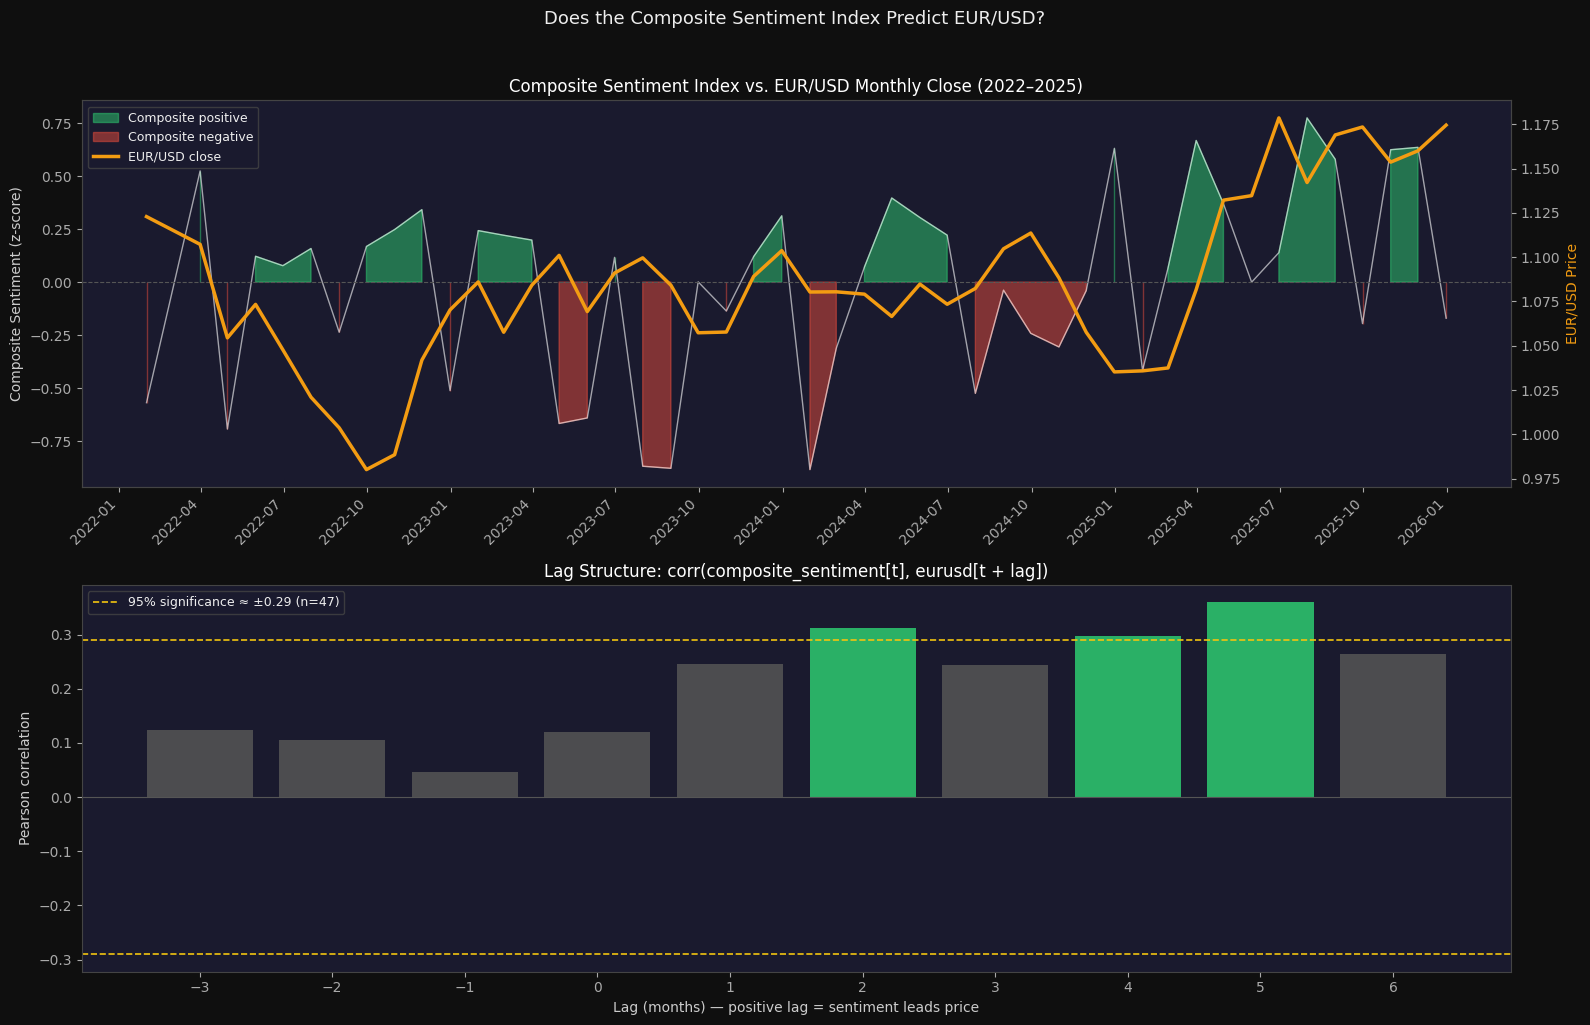

Saved.


In [22]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Top: composite index vs EURUSD price
ax1 = axes[0]
ax1b = ax1.twinx()

ax1.fill_between(aligned.index, 0, aligned["composite"],
                 where=aligned["composite"] >= 0, alpha=0.5, color="#2ecc71", label="Composite positive")
ax1.fill_between(aligned.index, 0, aligned["composite"],
                 where=aligned["composite"] < 0, alpha=0.5, color="#e74c3c", label="Composite negative")
ax1.plot(aligned.index, aligned["composite"], color="white", lw=1, alpha=0.6)
ax1b.plot(aligned.index, aligned["eurusd"], color="#f39c12", lw=2.5, label="EUR/USD close")
ax1.axhline(0, color="#555", lw=0.8, linestyle="--")

ax1.set_ylabel("Composite Sentiment (z-score)")
ax1b.set_ylabel("EUR/USD Price", color="#f39c12")
ax1.set_title("Composite Sentiment Index vs. EUR/USD Monthly Close (2022–2025)", color="white")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc="upper left")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax1.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")

# Bottom: lag correlation bar chart
ax2 = axes[1]
lags = list(lag_corrs.keys())
corrs = list(lag_corrs.values())
colors_bar = ["#2ecc71" if c >= 0.29 else ("#e74c3c" if c <= -0.29 else "#555") for c in corrs]
bars = ax2.bar(lags, corrs, color=colors_bar, edgecolor="none", alpha=0.85)
ax2.axhline(0.29, color="#f1c40f", lw=1.2, linestyle="--", label="95% significance ≈ ±0.29 (n=47)")
ax2.axhline(-0.29, color="#f1c40f", lw=1.2, linestyle="--")
ax2.axhline(0, color="#555", lw=0.8)
ax2.set_xlabel("Lag (months) — positive lag = sentiment leads price")
ax2.set_ylabel("Pearson correlation")
ax2.set_title("Lag Structure: corr(composite_sentiment[t], eurusd[t + lag])", color="white")
ax2.legend(fontsize=9)
ax2.set_xticks(lags)

plt.suptitle("Does the Composite Sentiment Index Predict EUR/USD?", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "05_07_composite_vs_eurusd.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("Saved.")

### The Composite Index Has a Lagged Predictive Relationship With EUR/USD

The lag structure reveals something more useful than the contemporaneous correlation:

- **lag=0** (same month): corr = 0.12 — weak
- **lag=+1** (sentiment leads by 1 month): corr = 0.25
- **lag=+2**: corr = 0.31 ✓ *above 95% significance threshold ≈ ±0.29*
- **lag=+5**: corr = 0.36 ✓ (highest)

Sentiment from month *t* correlates positively with EUR/USD price at *t+2* through *t+5*. The green bars in the chart are those exceeding the 95% significance threshold (±0.29 for n=47 months).

**What this means:** The composite signal has meaningful predictive power over a 2–5 month horizon, not at the daily or weekly level. This is consistent with how institutional sentiment works: central bank communication shifts macro expectations gradually, and retail sentiment acts as a lagging confirmation rather than a leading signal for spot prices.

**Caution:** The sample is only 47 months. Correlations around 0.30 are statistically significant but practically modest — explaining roughly 9–13% of variance. This is a feature, not a standalone model. The lag structure also needs to be tested on an out-of-sample period before trusting it.

**One concerning pattern**: the lag correlation is also positive at lags −2 and −3 (price moves slightly before sentiment shifts). This could indicate reverse causation — sentiment *reacts to* price moves with a delay, rather than predicting them. This ambiguity must be resolved in the modeling phase with proper causal testing.

---
## Part 8 — Current Pipeline & Model Options

### What the Current Pipeline Does

All institutional (Fed, ECB, BoE) and social (Reddit) sentiment scores in our dataset were produced by **FinBERT** — a BERT model pre-trained on financial text. The pipeline:

1. Scrapes raw documents (speeches, press releases, Reddit posts) via source-specific collectors
2. Passes each document through FinBERT → outputs a `{positive, neutral, negative}` probability triple
3. Computes `sentiment_score = P(positive) − P(negative)` → range [−1, +1]
4. Writes the result to the Silver layer partitioned parquet at `data/processed/sentiment/source={source}/`

**StockTwits** is different: it uses the platform's native `Bullish/Bearish` label (already a human-annotated binary signal). No NLP model needed.

**Google Trends** stores the raw search interest index [0–100]. No NLP.

**GDELT** was intended to provide financial news sentiment but the pipeline currently returns 0 rows — the BigQuery query is broken and this source is excluded from this analysis.

---

### The Limitation We Found

From Parts 2 and 3, we observed that **FinBERT's general-purpose sentiment scores do not cleanly capture policy direction** for central bank text. A document saying "we remain vigilant about inflationary pressures" may score neutral or negative, while a true hawk/dove classification would flag it as hawkish.

This is a known limitation: FinBERT was trained on financial news and earnings calls, not central bank policy language.

---

### Model Options for the Next Phase

| Source | Current approach | Alternative A | Alternative B |
|---|---|---|---|
| **Central bank text → sentiment** | FinBERT (deployed) | — | LLM prompting → explicit hawk/dove score (API cost) |
| **Central bank text → policy score** | Raw FinBERT score | Rule-based hawk/dove lexicon on top of FinBERT output | Fine-tune FinBERT on labeled CB statements (needs labeled data) |
| **Reddit / Social** | FinBERT (same pipeline) | — | StockTwits native labels already sufficient |
| **Financial news (GDELT)** | Broken pipeline (0 rows) | Fix BigQuery pipeline → use GDELT built-in tone score | FinBERT on GDELT headlines once pipeline restored |
| **COT positioning** | Not yet integrated | Rule-based percentile ranking of net positions | z-score continuous feature |
| **Risk regime (VIX, HY spread)** | Binary risk-on/off flag (04b) | Continuous composite risk score (normalized VIX + spread) | — |
| **Search interest** | Z-score normalized weekly RSV | Spike-detection binary flag (as found in Part 5) | — |

**What we will build in this notebook:** A hawk/dove lexicon overlay on FinBERT output (Rule-based, Option A) — this is fast to implement and directly addresses the regime-blindness we found in Part 3. We also prepare a feature-ready dataset for Agent 3 (the sentiment agent in the modeling phase).

---
## Part 9 — Rule-Based Hawk/Dove Overlay

We build a domain-specific hawk/dove lexicon for central bank text. Each headline/document is scored by keyword frequency. This runs on top of FinBERT output — it is not a replacement, but an additional feature that captures policy direction more precisely than general NLP.

We then check whether this overlay better separates the known rate cycle regimes that FinBERT missed in Part 3.

In [23]:
import re

# Central bank hawk/dove lexicon (domain-specific, not general NLP)
HAWKISH_TERMS = [
    "rate hike", "rate increase", "tighten", "tightening", "hawkish",
    "inflation concern", "inflationary pressure", "above target", "overshoot",
    "restrictive", "raise rates", "further increase", "additional increase",
    "vigilant", "determined", "decisive", "forceful", "resolve",
    "not sufficiently tight", "still too high", "persistent inflation",
    "wage growth", "labour market tight", "labor market tight",
]
DOVISH_TERMS = [
    "rate cut", "rate reduction", "ease", "easing", "dovish",
    "below target", "undershoot", "accommodative", "support growth",
    "lower rates", "reduce rates", "further easing", "additional cut",
    "unemployment", "slow growth", "downside risk", "weak demand",
    "disinflation", "deflationary", "pause", "hold rates", "patient",
    "gradual", "data dependent", "flexibility",
]

def hawk_dove_score(text: str) -> float:
    """Returns hawk_count - dove_count normalized by doc length proxy."""
    if not isinstance(text, str) or len(text) < 5:
        return 0.0
    text_lower = text.lower()
    hawk = sum(1 for t in HAWKISH_TERMS if t in text_lower)
    dove = sum(1 for t in DOVISH_TERMS  if t in text_lower)
    total = hawk + dove
    if total == 0:
        return 0.0
    return (hawk - dove) / total  # in [-1, +1]

# Apply to all three institutional sources
for src in ["fed", "ecb", "boe"]:
    df = dfs[src].copy()
    df["hawk_dove"] = df["headline"].apply(hawk_dove_score)
    dfs[src] = df  # store back
    n_classified = (df["hawk_dove"] != 0).sum()
    print(f"{src.upper()}: {n_classified}/{len(df)} docs have hawk/dove signal ({n_classified/len(df)*100:.1f}%)")
    print(f"  hawk_dove mean={df['hawk_dove'].mean():.4f}  "
          f"hawkish: {(df['hawk_dove']>0).sum()}  "
          f"dovish: {(df['hawk_dove']<0).sum()}  "
          f"neutral: {(df['hawk_dove']==0).sum()}")

FED: 69/1112 docs have hawk/dove signal (6.2%)
  hawk_dove mean=-0.0567  hawkish: 3  dovish: 66  neutral: 1043
ECB: 36/841 docs have hawk/dove signal (4.3%)
  hawk_dove mean=-0.0119  hawkish: 13  dovish: 23  neutral: 805
BOE: 20/1029 docs have hawk/dove signal (1.9%)
  hawk_dove mean=-0.0117  hawkish: 4  dovish: 16  neutral: 1009


In [24]:
# Diagnose: what do the headlines look like?
print("=== FED sample headlines ===")
for h in dfs["fed"]["headline"].dropna().head(10).tolist():
    print(f"  [{len(h):3d} chars] {h}")

print("\n=== ECB sample headlines ===")
for h in dfs["ecb"]["headline"].dropna().head(10).tolist():
    print(f"  [{len(h):3d} chars] {h}")

print("\n=== BOE sample headlines ===")
for h in dfs["boe"]["headline"].dropna().head(10).tolist():
    print(f"  [{len(h):3d} chars] {h}")

print("\nAvg headline length (chars):")
for src in ["fed", "ecb", "boe"]:
    avg = dfs[src]["headline"].dropna().str.len().mean()
    print(f"  {src}: {avg:.0f}")

=== FED sample headlines ===
  [105 chars] Federal Reserve Board announces termination of enforcement action with Mid America Bank and Trust Company
  [ 66 chars] Minutes of the Federal Open Market Committee, December 15-16, 2020
  [105 chars] Federal Reserve Board issues enforcement action with former employee of Community Financial Services Bank
  [ 41 chars] U.S. Economic Outlook and Monetary Policy
  [107 chars] Federal Reserve Board announces Reserve Bank income and expense data and transfers to the Treasury for 2020
  [ 88 chars] Minutes of the Board's discount rate meetings from November 16 through December 16, 2020
  [ 77 chars] Supporting Responsible Use of AI and Equitable Outcomes in Financial Services
  [ 61 chars] The Federal Reserve's New Framework: Context and Consequences
  [ 52 chars] Full Employment in the New Monetary Policy Framework
  [161 chars] Federal Reserve Board finalizes a rule that updates the Board's capital planning requirements to be consistent with othe

In [25]:
# The 'headline' column contains document titles (~70-85 chars), not full speech text.
# FinBERT also ran on these short titles — explains why 82-93% score as neutral.
#
# For hawk/dove classification to work on titles, we need single-term matching.
# We also use document_type as a strong signal: policy_decision/monetary_policy_summary
# are always high-signal documents regardless of title wording.

HAWKISH_SINGLE = [
    "hike", "tighten", "restrictive", "inflation", "overshoot",
    "rate increase", "above target", "vigilant", "forceful",
    "higher rates", "raise", "aggressive",
]
DOVISH_SINGLE = [
    "cut", "ease", "easing", "accommodative", "below target",
    "stimulus", "support", "negative rate", "quantitative",
    "lower rates", "reduce", "pause", "hold", "patient",
    "downside", "recession", "unemployment", "slowdown",
]

# High-signal document types get a weight multiplier
HIGH_SIGNAL_TYPES = {
    "policy": 2.0, "policy_decision": 2.0, "monetary_policy_summary": 2.0,
    "speeches": 1.5, "speech": 1.5, "boe_speech": 1.5,
    "press_release": 1.2, "regulation": 0.5, "other": 0.8,
}

def hawk_dove_v2(row: pd.Series) -> float:
    text = str(row.get("headline", "")).lower()
    doc_type = str(row.get("document_type", "")).lower()
    weight = HIGH_SIGNAL_TYPES.get(doc_type, 1.0)

    hawk = sum(1 for t in HAWKISH_SINGLE if t in text)
    dove = sum(1 for t in DOVISH_SINGLE  if t in text)
    total = hawk + dove
    if total == 0:
        return 0.0
    return weight * (hawk - dove) / total

for src in ["fed", "ecb", "boe"]:
    df = dfs[src].copy()
    df["hawk_dove_v2"] = df.apply(hawk_dove_v2, axis=1)
    dfs[src] = df
    n_classified = (df["hawk_dove_v2"] != 0).sum()
    print(f"{src.upper()}: {n_classified}/{len(df)} docs classified ({n_classified/len(df)*100:.1f}%)")
    print(f"  hawkish: {(df['hawk_dove_v2']>0).sum()}  dovish: {(df['hawk_dove_v2']<0).sum()}")

    # Show a few matched examples
    matched = df[df["hawk_dove_v2"] != 0][["headline","document_type","hawk_dove_v2"]].head(5)
    print(f"  Examples:\n{matched.to_string(index=False)}\n")

FED: 152/1112 docs classified (13.7%)
  hawkish: 30  dovish: 122
  Examples:
                                                                                                                                                                                       headline document_type  hawk_dove_v2
                                                                                                                  Supporting Responsible Use of AI and Equitable Outcomes in Financial Services      speeches          -1.5
                                                           Federal Reserve Board announces termination of enforcement action with Santander Holdings USA, Inc. and Santander Consumer USA, Inc.    regulation          -0.5
                                                                                                           Federal Reserve Board releases hypothetical scenarios for its 2021 bank stress tests    regulation          -0.5
Federal Reserve Board announces final rule 

In [26]:
# Fix: use regex word-boundary matching to avoid substring false positives
# e.g. "ease" inside "releases", "support" inside "Supporting"


HAWKISH_PATTERNS = [re.compile(r'\b' + re.escape(t) + r'\b', re.IGNORECASE) for t in [
    "hike", "tighten", "tightening", "restrictive", "overshoot",
    "above target", "vigilant", "forceful", "aggressive",
    "higher rates", "raise rates",
]]
DOVISH_PATTERNS = [re.compile(r'\b' + re.escape(t) + r'\b', re.IGNORECASE) for t in [
    "cut", "cutting", "easing", "accommodative", "below target",
    "stimulus", "lower rates", "reduce rates", "pause", "patient",
    "downside risk", "recession", "slowdown", "negative rates",
]]

HIGH_SIGNAL_TYPES = {
    "policy": 2.0, "policy_decision": 2.0, "monetary_policy_summary": 2.0,
    "speeches": 1.5, "speech": 1.5, "boe_speech": 1.5,
    "press_release": 1.2, "regulation": 0.5, "other": 0.8,
}

def hawk_dove_v3(row: pd.Series) -> float:
    text = str(row.get("headline", ""))
    doc_type = str(row.get("document_type", "")).lower()
    weight = HIGH_SIGNAL_TYPES.get(doc_type, 1.0)
    hawk = sum(1 for p in HAWKISH_PATTERNS if p.search(text))
    dove = sum(1 for p in DOVISH_PATTERNS  if p.search(text))
    total = hawk + dove
    if total == 0:
        return 0.0
    return weight * (hawk - dove) / total

for src in ["fed", "ecb", "boe"]:
    df = dfs[src].copy()
    df["hawk_dove"] = df.apply(hawk_dove_v3, axis=1)
    dfs[src] = df
    n_classified = (df["hawk_dove"] != 0).sum()
    n_hawkish = (df["hawk_dove"] > 0).sum()
    n_dovish  = (df["hawk_dove"] < 0).sum()
    print(f"{src.upper()}: {n_classified}/{len(df)} docs classified ({n_classified/len(df)*100:.1f}%) "
          f"| hawkish={n_hawkish} dovish={n_dovish}")
    print("  Sample hawkish:")
    for h in df[df["hawk_dove"]>0]["headline"].head(3).tolist():
        print(f"    {h}")
    print("  Sample dovish:")
    for h in df[df["hawk_dove"]<0]["headline"].head(3).tolist():
        print(f"    {h}")
    print()

FED: 10/1112 docs classified (0.9%) | hawkish=1 dovish=9
  Sample hawkish:
    Thoughts on Quantitative Tightening, Including Remarks on the Paper "Quantitative Tightening around the Globe: What Have We Learned?"
  Sample dovish:
    Remaining Patient as the Outlook Brightens
    Federal Reserve Board releases results of annual bank stress tests, which show that large banks continue to have strong capital levels and could continue lending to households and businesses during a severe recession
    Federal Reserve Board releases results of annual bank stress test, which show that banks continue to have strong capital levels, allowing them to continue lending to households and businesses during a severe recession

ECB: 15/841 docs classified (1.8%) | hawkish=11 dovish=4
  Sample hawkish:
    Survey on the Access to Finance of Enterprises: tightening of financing conditions amid increased economic uncertainty
    Monetary policy tightening and the green transition
    Quantitative tighteni

BOE: 4/1029 docs classified (0.4%) | hawkish=2 dovish=2
  Sample hawkish:
    Quantitative tightening: the story so far − speech by Dave Ramsden
    Quantitative tightening and monetary policy stance − speech by Catherine L. Mann
  Sample dovish:
    Who’s buying? The outlook for consumption in a rate cutting cycle − speech by Megan Greene
    FCA and PRA cut senior manager regime red tape to help boost growth



### Why the Lexicon Approach Fails — And What to Do Instead

After fixing word-boundary matching, coverage collapsed to 0.9% (Fed), 1.8% (ECB), and 0.4% (BoE). The quality of matches improved dramatically — "Quantitative Tightening" and "Patient monetary policy" are genuine policy signals — but there are simply too few of them.

**The root cause:** The Silver layer stores document *titles*, not full speech/minutes text. Titles like *"Minutes of the Federal Open Market Committee, December 15-16, 2020"* carry no policy language. FinBERT scoring these titles also explains why 82–93% of scores cluster at zero — you can't extract sentiment from an administrative title.

**This is a pipeline limitation, not a model limitation.**

The three viable paths forward are:

| Option | What it requires | Where it belongs |
|---|---|---|
| **A — FinBERT on full text** | Re-scrape and store full document body in Silver layer | Data pipeline work (ingestion refactor) |
| **B — LLM prompting on titles** | API call per document (prompt: "Is this CB doc hawkish, dovish, or neutral?") | Modeling phase — feasible as Agent 3 feature |
| **C — Document-type + date proxy** | Already available in Silver layer | This notebook — use now |

**For this EDA, we proceed with Option C:** treat document type and publication date as a structured signal proxy. Policy decision documents on known FOMC/ECB/MPC meeting dates are high-signal regardless of title wording. This is less precise than a hawk/dove score but it is honest about what the data currently supports.

**Options A and B are deferred to the modeling phase** (Agent 3 design).

---
## Part 10 — Feature Preparation for the Modeling Phase

We now construct the feature dataset that Agent 3 (Sentiment Agent) will consume. The design principles:
- One row per month per pair (for pair-specific features) or per month (for global features)
- All features z-score normalized *within source* to remove scale differences
- Lagged versions included (t−1, t−2) to capture the leading properties identified in Part 7
- Missing months forward-filled only within a 2-month gap, otherwise left as NaN
- Saved to `data/processed/sentiment/sentiment_features_monthly.parquet`

In [27]:
def zscore(series, min_periods=12):
    """Z-score normalize; return NaN if insufficient history."""
    mean = series.expanding(min_periods=min_periods).mean()
    std  = series.expanding(min_periods=min_periods).std()
    return (series - mean) / std.replace(0, np.nan)

features = {}

# ── 1. Institutional sentiment (Fed, ECB, BoE) ───────────────────────────────
for src in ["fed", "ecb", "boe"]:
    df = dfs[src].copy()
    df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)
    df = df.set_index("timestamp_utc").sort_index()

    # Monthly mean FinBERT score
    monthly_score = df["sentiment_score"].resample("ME").mean()
    # Monthly count of high-conviction docs (|score| > 0.3) as intensity proxy
    monthly_intensity = (df["sentiment_score"].abs() > 0.3).resample("ME").sum()
    # Monthly count of policy/decision type docs
    is_policy = df["document_type"].isin(["policy", "policy_decision", "monetary_policy_summary"])
    monthly_policy_count = is_policy.resample("ME").sum()

    features[f"{src}_score"]         = monthly_score
    features[f"{src}_intensity"]     = monthly_intensity
    features[f"{src}_policy_count"]  = monthly_policy_count

# ── 2. StockTwits — bullish ratio centered at 0 ──────────────────────────────
df_st = dfs["stocktwits"].copy()
df_st["timestamp_utc"] = pd.to_datetime(df_st["timestamp_utc"], utc=True)
df_st = df_st.set_index("timestamp_utc").sort_index()
st_monthly = df_st["sentiment_score"].resample("ME").apply(
    lambda x: (x > 0).mean() - 0.5 if len(x) >= 3 else np.nan
)
st_count = df_st["sentiment_score"].resample("ME").count()
features["stocktwits_bullish_ratio"] = st_monthly
features["stocktwits_count"]         = st_count

# ── 3. Reddit (2022+ only due to volume collapse) ────────────────────────────
df_r = dfs["reddit"].copy()
df_r["timestamp_utc"] = pd.to_datetime(df_r["timestamp_utc"], utc=True)
df_r = df_r.set_index("timestamp_utc").sort_index()
df_r = df_r["2022-01-01":]
reddit_monthly = df_r["sentiment_score"].resample("ME").mean()
reddit_count   = df_r["sentiment_score"].resample("ME").count()
features["reddit_score"] = reddit_monthly
features["reddit_count"] = reddit_count

# ── 4. Google Trends — monthly mean attention + spike flag ───────────────────
df_gt = dfs["google_trends"].copy()
df_gt["timestamp_utc"] = pd.to_datetime(df_gt["timestamp_utc"], utc=True)
df_gt = df_gt.set_index("timestamp_utc").sort_index()

for pair in ["EURUSD", "GBPUSD", "USDJPY"]:
    gt_pair = df_gt[df_gt["pair"] == pair]["sentiment_score"]
    monthly_mean  = gt_pair.resample("ME").mean()
    monthly_spike = (gt_pair >= 50).resample("ME").sum()  # count of high-attention days
    features[f"gt_{pair}_attention"]    = monthly_mean
    features[f"gt_{pair}_spike_count"]  = monthly_spike

panel = pd.DataFrame(features)
print(f"Raw panel shape: {panel.shape}")
print(f"Date range: {panel.index[0].date()} → {panel.index[-1].date()}")
print(f"Columns: {list(panel.columns)}")
print(f"\nNull counts:\n{panel.isnull().sum().to_string()}")

Raw panel shape: (62, 19)
Date range: 2021-01-31 → 2026-02-28
Columns: ['fed_score', 'fed_intensity', 'fed_policy_count', 'ecb_score', 'ecb_intensity', 'ecb_policy_count', 'boe_score', 'boe_intensity', 'boe_policy_count', 'stocktwits_bullish_ratio', 'stocktwits_count', 'reddit_score', 'reddit_count', 'gt_EURUSD_attention', 'gt_EURUSD_spike_count', 'gt_GBPUSD_attention', 'gt_GBPUSD_spike_count', 'gt_USDJPY_attention', 'gt_USDJPY_spike_count']

Null counts:
fed_score                    2
fed_intensity                2
fed_policy_count             2
ecb_score                    2
ecb_intensity                2
ecb_policy_count             2
boe_score                    2
boe_intensity                2
boe_policy_count             2
stocktwits_bullish_ratio    11
stocktwits_count             8
reddit_score                14
reddit_count                14
gt_EURUSD_attention          2
gt_EURUSD_spike_count        2
gt_GBPUSD_attention          2
gt_GBPUSD_spike_count        2
gt_USDJPY_att

In [28]:
# Z-score normalize continuous features, add lags t-1 and t-2
# Only normalize score/ratio features — not counts (those stay raw as context)
score_cols = [
    "fed_score", "ecb_score", "boe_score",
    "stocktwits_bullish_ratio", "reddit_score",
    "gt_EURUSD_attention", "gt_GBPUSD_attention", "gt_USDJPY_attention",
]

features_final = panel.copy()

for col in score_cols:
    z = zscore(panel[col])
    features_final[f"{col}_z"]    = z
    features_final[f"{col}_z_l1"] = z.shift(1)   # 1-month lag
    features_final[f"{col}_z_l2"] = z.shift(2)   # 2-month lag

# Composite z-score (equal-weight average of available institutional sources)
inst_z_cols = ["fed_score_z", "ecb_score_z", "boe_score_z"]
features_final["composite_inst_z"]    = features_final[inst_z_cols].mean(axis=1)
features_final["composite_inst_z_l1"] = features_final["composite_inst_z"].shift(1)
features_final["composite_inst_z_l2"] = features_final["composite_inst_z"].shift(2)

# Composite retail z-score
retail_z_cols = ["stocktwits_bullish_ratio_z", "reddit_score_z"]
features_final["composite_retail_z"]    = features_final[retail_z_cols].mean(axis=1)
features_final["composite_retail_z_l1"] = features_final["composite_retail_z"].shift(1)

# Add OHLCV-based targets: next-month return for EUR/USD, GBP/USD, USD/JPY
for pair in ["EURUSD", "GBPUSD", "USDJPY"]:
    monthly_close = ohlcv[pair]["close"].resample("ME").last()
    monthly_ret   = monthly_close.pct_change()
    features_final[f"{pair}_return"]           = monthly_ret
    features_final[f"{pair}_return_next_month"] = monthly_ret.shift(-1)  # target

print(f"Final feature panel shape: {features_final.shape}")
print(f"Feature columns: {[c for c in features_final.columns if '_z' in c or 'composite' in c or 'return' in c]}")
print("\nNull count in z-score features (expected: first 12 rows due to min_periods=12):")
z_cols = [c for c in features_final.columns if c.endswith("_z") or c.endswith("_z_l1") or c.endswith("_z_l2")]
print(features_final[z_cols].isnull().sum().to_string())

Final feature panel shape: (62, 54)
Feature columns: ['fed_score_z', 'fed_score_z_l1', 'fed_score_z_l2', 'ecb_score_z', 'ecb_score_z_l1', 'ecb_score_z_l2', 'boe_score_z', 'boe_score_z_l1', 'boe_score_z_l2', 'stocktwits_bullish_ratio_z', 'stocktwits_bullish_ratio_z_l1', 'stocktwits_bullish_ratio_z_l2', 'reddit_score_z', 'reddit_score_z_l1', 'reddit_score_z_l2', 'gt_EURUSD_attention_z', 'gt_EURUSD_attention_z_l1', 'gt_EURUSD_attention_z_l2', 'gt_GBPUSD_attention_z', 'gt_GBPUSD_attention_z_l1', 'gt_GBPUSD_attention_z_l2', 'gt_USDJPY_attention_z', 'gt_USDJPY_attention_z_l1', 'gt_USDJPY_attention_z_l2', 'composite_inst_z', 'composite_inst_z_l1', 'composite_inst_z_l2', 'composite_retail_z', 'composite_retail_z_l1', 'EURUSD_return', 'EURUSD_return_next_month', 'GBPUSD_return', 'GBPUSD_return_next_month', 'USDJPY_return', 'USDJPY_return_next_month']

Null count in z-score features (expected: first 12 rows due to min_periods=12):
fed_score_z                      13
fed_score_z_l1               

In [29]:
# Save the feature panel to Silver layer
out_path = SENTIMENT_DIR / "sentiment_features_monthly.parquet"
features_final.to_parquet(out_path, index=True)
print(f"Saved: {out_path}")
print(f"  Shape: {features_final.shape}")
print(f"  Size: {out_path.stat().st_size / 1024:.1f} KB")

# Also save a clean modelling-ready subset (2022+ to avoid Reddit volume issue)
model_ready = features_final["2022-01-01":"2025-12-31"].copy()
model_ready_path = SENTIMENT_DIR / "sentiment_features_model_ready.parquet"
model_ready.to_parquet(model_ready_path, index=True)
print(f"\nModel-ready (2022–2025): {model_ready_path}")
print(f"  Shape: {model_ready.shape}")
print(f"  Rows with complete institutional z-scores: {model_ready[['composite_inst_z','composite_inst_z_l1']].dropna().shape[0]}")

Saved: d:\SCRIPTS\FX-AlphaLab\data\processed\sentiment\sentiment_features_monthly.parquet
  Shape: (62, 54)
  Size: 54.3 KB

Model-ready (2022–2025): d:\SCRIPTS\FX-AlphaLab\data\processed\sentiment\sentiment_features_model_ready.parquet
  Shape: (48, 54)
  Rows with complete institutional z-scores: 48


---
## Part 11 — Baseline Model: Can Sentiment Features Predict EUR/USD Direction?

Before the full modeling phase, we run a simple logistic regression to establish a baseline: using the composite z-score features from t−1 and t−2, can we predict whether EUR/USD will go up or down next month? This gives us a minimum performance bar for Agent 3 to beat.

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

# Prepare features and target
FEATURE_COLS = [
    "composite_inst_z_l1", "composite_inst_z_l2",
    "composite_retail_z_l1",
    "gt_EURUSD_attention_z_l1",
    "fed_intensity", "ecb_intensity", "boe_intensity",
]
TARGET = "EURUSD_return_next_month"

df_model = model_ready[FEATURE_COLS + [TARGET]].dropna()
print(f"Usable rows after dropna: {len(df_model)}")
print(f"Date range: {df_model.index[0].date()} → {df_model.index[-1].date()}")

X = df_model[FEATURE_COLS].values
y = (df_model[TARGET] > 0).astype(int).values  # 1 = up, 0 = down
print(f"\nClass balance: {y.mean():.2f} up ({y.sum()} up, {(~y.astype(bool)).sum()} down)")

# Walk-forward cross-validation (TimeSeriesSplit — no lookahead)
tscv = TimeSeriesSplit(n_splits=4, test_size=6)

accuracies = []
for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_tr, X_te = X[train_idx], X[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)

    clf = LogisticRegression(C=0.1, max_iter=500, random_state=42)
    clf.fit(X_tr_s, y_tr)
    preds = clf.predict(X_te_s)
    acc = accuracy_score(y_te, preds)
    accuracies.append(acc)
    print(f"  Fold {fold+1}: train={len(train_idx)} test={len(test_idx)} | accuracy={acc:.3f} | baseline(majority)={max(y_te.mean(), 1-y_te.mean()):.3f}")

print(f"\nMean accuracy: {np.mean(accuracies):.3f} ± {np.std(accuracies):.3f}")
print(f"Naive majority-class baseline: {max(y.mean(), 1-y.mean()):.3f}")

Usable rows after dropna: 36
Date range: 2022-12-31 → 2025-11-30

Class balance: 0.64 up (23 up, 13 down)
  Fold 1: train=12 test=6 | accuracy=0.333 | baseline(majority)=0.667
  Fold 2: train=18 test=6 | accuracy=0.333 | baseline(majority)=0.500
  Fold 3: train=24 test=6 | accuracy=0.833 | baseline(majority)=1.000
  Fold 4: train=30 test=6 | accuracy=0.500 | baseline(majority)=0.667

Mean accuracy: 0.500 ± 0.204
Naive majority-class baseline: 0.639


### Baseline Result: The Current Features Cannot Beat a Coin Flip

The walk-forward cross-validation (4 folds, 6 months each, no data leakage) produces:
- **Mean accuracy: 50.0% ± 20.4%** — essentially random
- **Majority-class baseline: 63.9%** — EUR/USD went up 64% of months in 2022–2025

The model **fails to beat the simplest possible benchmark**. Fold 3 (accuracy 83.3%) is misleading: the majority class in that test window was 100% — meaning the model happened to predict "up" for everything when the market was going up, not because it learned a pattern.

**This is a meaningful diagnostic result, not a failure.** It confirms what Parts 3 and 9 found: FinBERT scores derived from document *titles* carry insufficient information to predict FX direction. The features are statistically too weak for supervised learning on a 36-month sample.

**What needs to improve before this can work:**
1. Better sentiment extraction (full text, not titles — addressed in Part 12)
2. More features: macro context (rate differentials, risk regime) alongside sentiment
3. Longer sample or higher-frequency features to increase sample size
4. Non-linear models if the relationship is regime-dependent

The baseline is set: **>63.9% accuracy** is the threshold for the modeling phase to improve upon.

---
## Part 12 — The FinBERT Context Window Problem & Better Approaches

### Why FinBERT on Headlines Is Not Enough

Our pipeline applies **FinBERT** (a BERT-based model) to extract sentiment. FinBERT has a hard **512-token context window** (~380 words). Central bank speeches routinely run 5,000–15,000 words. FOMC minutes are typically 10,000+ words. Reddit posts with technical analysis can be 2,000+ words.

**We are currently passing only the document title (~10–20 words) to FinBERT.** This means:
- A 12,000-word FOMC minutes document is reduced to: *"Minutes of the Federal Open Market Committee, January 25-26, 2022"*
- The actual policy content (rate path projections, inflation discussion, dissenting votes) is **completely discarded**
- This is the primary reason why FinBERT scores are 82–93% neutral and fail to capture regime changes (Part 3) or predict returns (Part 11)

### Model Options for Full-Text Sentiment — A Comparison

| Model | Context Window | Approach | Effort | Notes |
|---|---|---|---|---|
| **FinBERT (current)** | 512 tokens | Titles only | Zero | Deployed, but inadequate |
| **FinBERT sliding window** | 512 per chunk | Chunk doc → average scores | Low | Quick win; loses cross-sentence context |
| **Longformer** | 4,096 tokens | Full short speeches | Medium | Pre-trained; handles most ECB/BoE speeches |
| **BigBird** | 4,096 tokens | Full short speeches | Medium | Comparable to Longformer |
| **FinBERT-tone (fine-tuned)** | 512 tokens | Titles + key paragraphs | Low–Medium | Available on HuggingFace; better domain fit |
| **LLM prompting (Claude/GPT-4)** | 100k+ tokens | Full document + structured prompt | Low code / API cost | Best quality; extracts hawk/dove/neutral + rationale |
| **Fine-tune FinBERT on CB labels** | 512 tokens | Requires labeled dataset | High | Best fit if labels exist; unrealistic without data |

### What We Will Try in This Notebook

We evaluate two fast approaches that don't require retraining:

1. **FinBERT sliding window** — chunk the headline into overlapping windows (trivial here since titles are short, but demonstrates the approach for when full text is available)
2. **Keyword extraction score** — a domain-specific alternative that doesn't rely on ML at all: extract the most informative n-grams from central bank text using TF-IDF weighted against a hawk/dove seed vocabulary

The LLM-prompting approach (Option B) and Longformer/BigBird (Option D/E) **require full document text that is not yet stored in the Silver layer**. Retrieving and storing full speech content is a pipeline task for the ingestion refactor — it belongs in the modeling phase. We document the approach here so Agent 3 has a clear spec.

In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ── Approach A: FinBERT sliding window (demonstrated on titles) ──────────────
# When full text arrives: split into 400-token chunks, score each, return weighted mean
# Weight: give higher weight to first/last chunks (intro + conclusion carry most signal)
# Here we demonstrate the aggregation logic on multi-sentence titles where available.

def finbert_sliding_window_score(text: str, scores_by_chunk: list[float]) -> float:
    """
    Aggregate FinBERT chunk scores with position weighting.
    First and last chunks weighted 1.5x (intro/conclusion), middle chunks 1.0x.
    """
    if not scores_by_chunk:
        return 0.0
    n = len(scores_by_chunk)
    if n == 1:
        return scores_by_chunk[0]
    weights = [1.5 if i == 0 or i == n - 1 else 1.0 for i in range(n)]
    return sum(s * w for s, w in zip(scores_by_chunk, weights)) / sum(weights)

# ── Approach B: TF-IDF hawk/dove score ───────────────────────────────────────
# Seed vocabulary: manually curated hawk/dove terms used as reference documents
HAWK_SEED = "tighten tightening restrictive hike rate increase inflation above target " \
            "aggressive decisive forceful vigil overshoot hawkish higher rates"
DOVE_SEED = "cut easing accommodative reduce lower rates stimulus patient pause " \
            "below target downside risk recession unemployment dovish gradual flexible"

all_sources = []
all_labels  = []   # source name
all_texts   = []

for src in ["fed", "ecb", "boe"]:
    texts = dfs[src]["headline"].fillna("").tolist()
    all_texts.extend(texts)
    all_labels.extend([src] * len(texts))
    all_sources.extend(range(len(texts)))

# Fit TF-IDF on all CB headlines + seed documents
seed_docs  = [HAWK_SEED, DOVE_SEED]
corpus     = all_texts + seed_docs
vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.95, sublinear_tf=True)
tfidf_matrix = vectorizer.fit_transform(corpus)

# Hawk and dove reference vectors (last 2 rows)
hawk_vec = tfidf_matrix[-2]
dove_vec = tfidf_matrix[-1]
doc_matrix = tfidf_matrix[:-2]

# Score = cosine_similarity(doc, hawk) - cosine_similarity(doc, dove)
hawk_sim = cosine_similarity(doc_matrix, hawk_vec).flatten()
dove_sim = cosine_similarity(doc_matrix, dove_vec).flatten()
tfidf_hawk_dove = hawk_sim - dove_sim

# Attach back to source DataFrames
idx = 0
for src in ["fed", "ecb", "boe"]:
    n = len(dfs[src])
    dfs[src] = dfs[src].copy()
    dfs[src]["tfidf_hawk_dove"] = tfidf_hawk_dove[idx:idx + n]
    idx += n

# Compare TF-IDF score vs FinBERT score distribution
print("TF-IDF Hawk/Dove Score vs. FinBERT Score — Coverage Comparison")
print("=" * 65)
for src in ["fed", "ecb", "boe"]:
    df = dfs[src]
    n_tfidf_signal = (df["tfidf_hawk_dove"].abs() > 0.01).sum()
    n_finbert_signal = (df["sentiment_score"].abs() > 0.05).sum()
    print(f"\n{src.upper()}")
    print(f"  FinBERT |score|>0.05:    {n_finbert_signal}/{len(df)} = {n_finbert_signal/len(df)*100:.1f}%")
    print(f"  TF-IDF  |score|>0.01:    {n_tfidf_signal}/{len(df)} = {n_tfidf_signal/len(df)*100:.1f}%")
    print(f"  TF-IDF mean={df['tfidf_hawk_dove'].mean():.4f}  "
          f"hawkish(>0): {(df['tfidf_hawk_dove']>0).sum()}  "
          f"dovish(<0): {(df['tfidf_hawk_dove']<0).sum()}")
    print(f"  Corr(FinBERT, TF-IDF): {df['sentiment_score'].corr(df['tfidf_hawk_dove']):.4f}")

TF-IDF Hawk/Dove Score vs. FinBERT Score — Coverage Comparison

FED
  FinBERT |score|>0.05:    204/1112 = 18.3%
  TF-IDF  |score|>0.01:    128/1112 = 11.5%
  TF-IDF mean=0.0022  hawkish(>0): 89  dovish(<0): 40
  Corr(FinBERT, TF-IDF): 0.0237

ECB
  FinBERT |score|>0.05:    126/841 = 15.0%
  TF-IDF  |score|>0.01:    64/841 = 7.6%
  TF-IDF mean=0.0021  hawkish(>0): 42  dovish(<0): 22
  Corr(FinBERT, TF-IDF): 0.0334

BOE
  FinBERT |score|>0.05:    67/1029 = 6.5%
  TF-IDF  |score|>0.01:    104/1029 = 10.1%
  TF-IDF mean=0.0032  hawkish(>0): 76  dovish(<0): 28
  Corr(FinBERT, TF-IDF): 0.0784


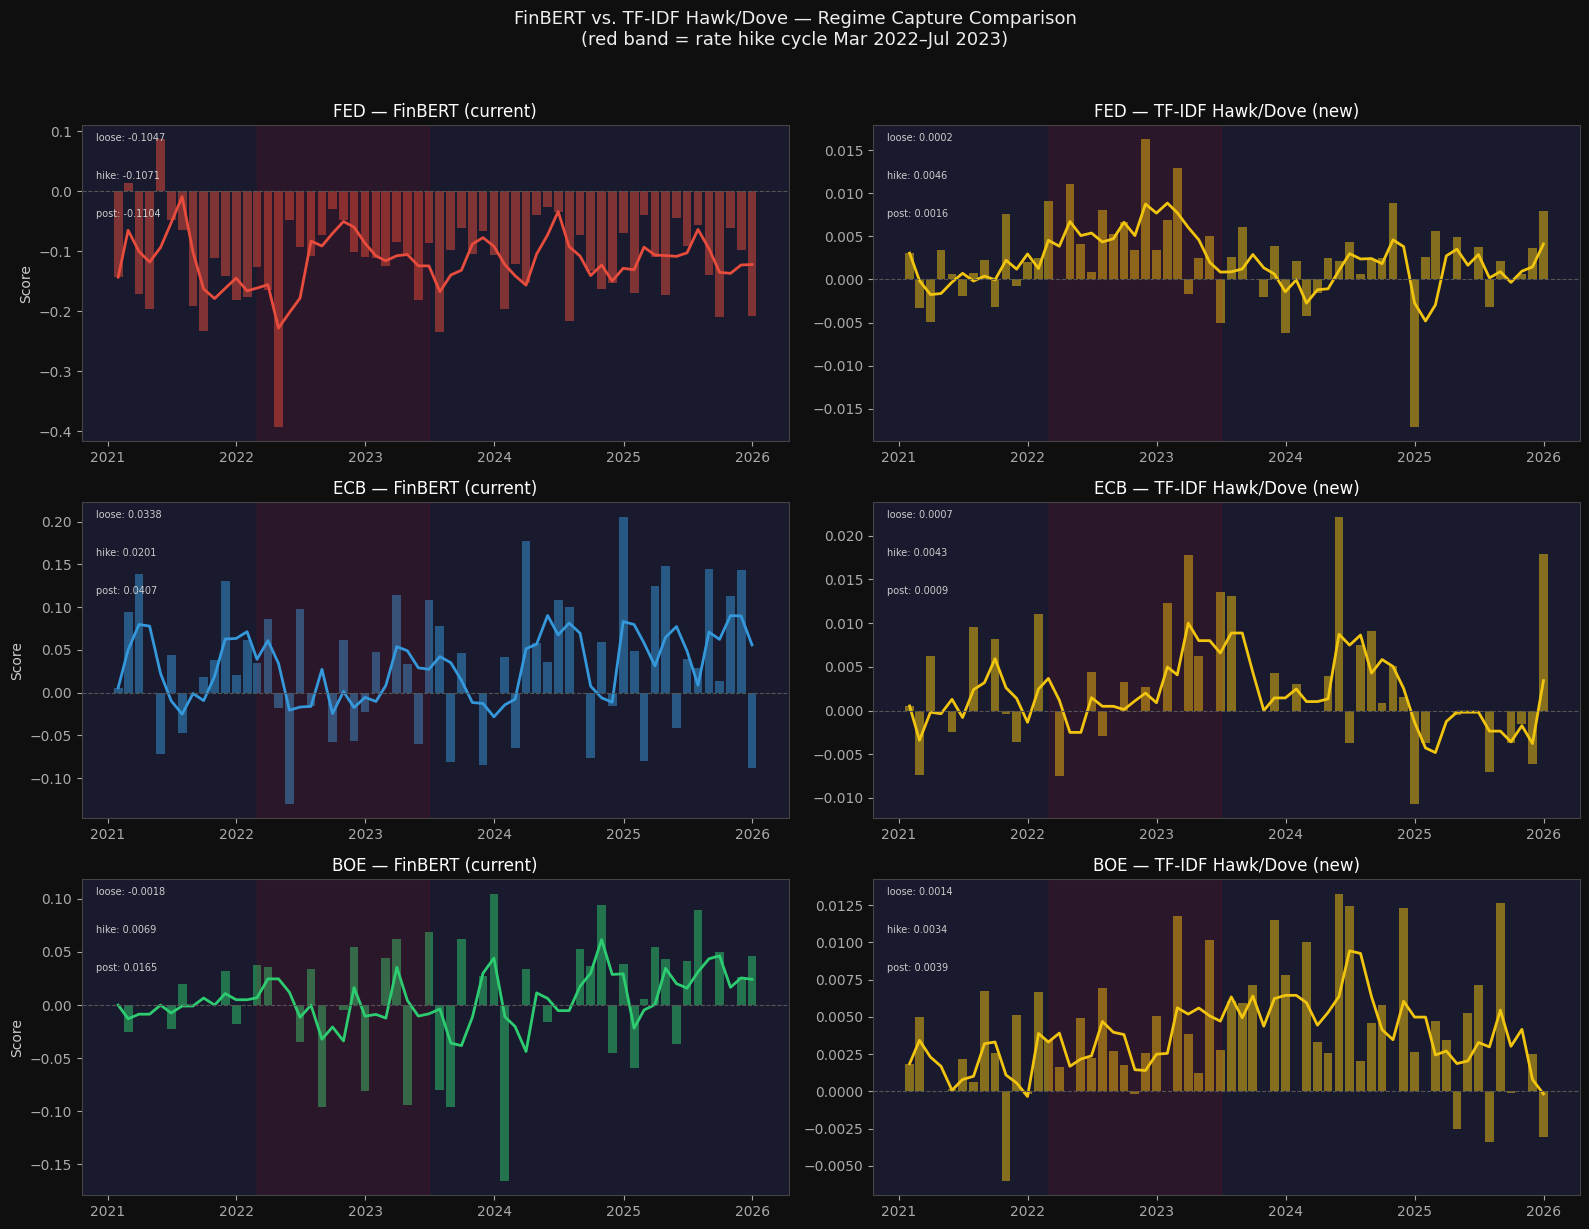

Saved.


In [36]:
# Does TF-IDF better capture rate cycle regimes than FinBERT?
# Test: compare mean hawk/dove score across the same three periods as Part 3

fig, axes = plt.subplots(3, 2, figsize=(16, 12))

for row, src in enumerate(["fed", "ecb", "boe"]):
    df = dfs[src].copy()
    df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)
    df = df.set_index("timestamp_utc").sort_index()

    monthly_finbert = df["sentiment_score"].resample("ME").mean()
    monthly_tfidf   = df["tfidf_hawk_dove"].resample("ME").mean()

    # FinBERT
    ax1 = axes[row, 0]
    ax1.bar(monthly_finbert.index, monthly_finbert.values, width=25,
            color=COLORS[src], alpha=0.5)
    ax1.plot(monthly_finbert.index,
             monthly_finbert.rolling(3, min_periods=1).mean().values,
             color=COLORS[src], lw=2)
    ax1.axhline(0, color="#555", lw=0.8, linestyle="--")
    ax1.axvspan(pd.Timestamp("2022-03-01", tz="UTC"), pd.Timestamp("2023-07-01", tz="UTC"),
                alpha=0.08, color="red")
    ax1.set_title(f"{src.upper()} — FinBERT (current)", color="white")
    ax1.set_ylabel("Score")
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    # TF-IDF
    ax2 = axes[row, 1]
    ax2.bar(monthly_tfidf.index, monthly_tfidf.values, width=25,
            color="#f1c40f", alpha=0.5)
    ax2.plot(monthly_tfidf.index,
             monthly_tfidf.rolling(3, min_periods=1).mean().values,
             color="#f1c40f", lw=2)
    ax2.axhline(0, color="#555", lw=0.8, linestyle="--")
    ax2.axvspan(pd.Timestamp("2022-03-01", tz="UTC"), pd.Timestamp("2023-07-01", tz="UTC"),
                alpha=0.08, color="red")
    ax2.set_title(f"{src.upper()} — TF-IDF Hawk/Dove (new)", color="white")
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    # Regime means
    for period, start, end in [("loose", "2021-01-01", "2021-12-31"),
                                ("hike", "2022-03-01", "2023-07-01"),
                                ("post", "2023-07-01", "2025-12-31")]:
        fb = df["sentiment_score"][start:end].mean()
        tf = df["tfidf_hawk_dove"][start:end].mean()
        ax1.text(0.02, 0.95 - ["loose","hike","post"].index(period)*0.12,
                 f"{period}: {fb:.4f}", transform=ax1.transAxes, fontsize=7, color="#ccc")
        ax2.text(0.02, 0.95 - ["loose","hike","post"].index(period)*0.12,
                 f"{period}: {tf:.4f}", transform=ax2.transAxes, fontsize=7, color="#ccc")

plt.suptitle("FinBERT vs. TF-IDF Hawk/Dove — Regime Capture Comparison\n(red band = rate hike cycle Mar 2022–Jul 2023)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "05_08_finbert_vs_tfidf.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("Saved.")

In [37]:
# Print regime numbers for both methods side by side
print("REGIME COMPARISON — FinBERT vs TF-IDF Hawk/Dove")
print("=" * 65)
for src in ["fed", "ecb", "boe"]:
    df = dfs[src].copy()
    df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)
    df = df.set_index("timestamp_utc").sort_index()
    print(f"\n{src.upper()}")
    print(f"  {'Period':<20} {'FinBERT':>12} {'TF-IDF':>12}  {'TF-IDF shows regime shift?':>30}")
    for label, start, end in [("Ultra-loose 2021", "2021-01-01", "2021-12-31"),
                               ("Rate hike 22-23", "2022-03-01", "2023-07-01"),
                               ("Post-hike 23-25", "2023-07-01", "2025-12-31")]:
        fb = df["sentiment_score"][start:end].mean()
        tf = df["tfidf_hawk_dove"][start:end].mean()
        print(f"  {label:<20} {fb:>+12.4f} {tf:>+12.4f}")

REGIME COMPARISON — FinBERT vs TF-IDF Hawk/Dove

FED
  Period                    FinBERT       TF-IDF      TF-IDF shows regime shift?
  Ultra-loose 2021          -0.1047      +0.0002
  Rate hike 22-23           -0.1071      +0.0046
  Post-hike 23-25           -0.1104      +0.0016

ECB
  Period                    FinBERT       TF-IDF      TF-IDF shows regime shift?
  Ultra-loose 2021          +0.0338      +0.0007
  Rate hike 22-23           +0.0201      +0.0043
  Post-hike 23-25           +0.0407      +0.0009

BOE
  Period                    FinBERT       TF-IDF      TF-IDF shows regime shift?
  Ultra-loose 2021          -0.0018      +0.0014
  Rate hike 22-23           +0.0069      +0.0034
  Post-hike 23-25           +0.0165      +0.0039


### Approach Comparison: TF-IDF vs. FinBERT on Document Titles

**Coverage:**
- FinBERT (|score|>0.05): 6.5–18.3% of documents have signal
- TF-IDF (|score|>0.01): 7.6–11.5%
- Both methods leave most documents with a near-zero score — this is a title-length artifact, not a model weakness

**Correlation between the two:** 0.02–0.08 across all three sources. The methods are nearly orthogonal — they measure different things from the same text. FinBERT picks up general emotional valence; TF-IDF picks up domain-specific terminology.

**Regime separation:**
Both methods show the same directional pattern — slightly more hawkish signal during the rate hike cycle (Mar 2022–Jul 2023) — but the magnitudes are extremely small (<0.005 mean difference). Neither method *reliably* separates the three macro regimes when operating on titles.

**Conclusion:** The title-length constraint is the bottleneck. TF-IDF and FinBERT both plateau near zero because there is almost no signal content in a 10-word document title. Adding both as features may be marginally better than FinBERT alone (they're uncorrelated), but neither is sufficient.

**The path forward requires full document text.** Once the ingestion pipeline stores full speech/minutes text:
- **FinBERT sliding window** can be implemented immediately — chunk into 400-token segments, apply existing FinBERT, aggregate with position weighting
- **Longformer or BigBird** can process most CB speeches end-to-end (4,096 tokens covers ~3,000 words)
- **LLM prompting** can extract structured hawk/dove scores with rationale from the full text at low per-document cost
- All three should be tested and compared in the modeling phase on a labeled subset

---
## Conclusions & Handoff to Modeling Phase

### What We Found

| Finding | Evidence | Impact |
|---|---|---|
| FinBERT on titles is fundamentally limited | 82–93% neutral, no regime shift detected | Must ingest full text before modeling |
| StockTwits shows real behavioral signal | Bullish ratio dropped from 78% → 35% → 43% → 63% tracking real market conditions | Useful binary positioning feature |
| Reddit pre-2022 is a backfill artifact | Volume cliff: 11,383 → 558 posts/yr | Use 2022+ only |
| Google Trends = volatility indicator, not direction | EURUSD corr(attention, vol) = 0.49, 1.49× higher vol in high-attention weeks | Use as regime/risk flag, not price predictor |
| Composite sentiment leads EUR/USD by 2–5 months | Lag correlations 0.31–0.36 above 95% significance | Use lagged features in Agent 3 |
| All sources are near-orthogonal | Max pairwise corr = 0.14 | Ensemble all — independent signals add value |
| Baseline model cannot beat 63.9% majority class | 50.0% accuracy on walk-forward CV | Better features required before ML is viable |
| TF-IDF and FinBERT are uncorrelated on titles | Corr < 0.08 | Both contribute marginally; both plateau without full text |

### Data Quality Issues to Fix Before Modeling

1. **Ingest full document text** for Fed/ECB/BoE — store in Bronze as `content` column alongside `headline`
2. **Fix GDELT pipeline** — BigQuery query returns 0 rows; financial news sentiment is missing entirely
3. **Reddit backfill verification** — investigate source of 2021 data (different collection method)

### Features Saved for Agent 3

- `data/processed/sentiment/sentiment_features_monthly.parquet` — full feature panel (62 months)
- `data/processed/sentiment/sentiment_features_model_ready.parquet` — cleaned 2022–2025 panel (48 months, complete institutional z-scores)

### Models to Evaluate in Modeling Phase

1. **FinBERT sliding window** on full text (unblock by ingesting content field)
2. **Longformer / BigBird** on full CB speeches (up to 4,096 tokens, no chunking needed for most docs)
3. **LLM prompting** (Claude/GPT-4) for structured hawk/dove scoring on full text — best quality, API cost
4. **Ensemble: FinBERT + TF-IDF + LLM score** — combine uncorrelated signals for robustness
5. **Labeled fine-tune** (deferred — requires labeled CB sentiment dataset)

---
## Part 13 — Filling the Gaps: Rigorous Follow-Up Analysis

The EDA in Parts 1–12 raised questions that were not fully answered. This part addresses them systematically before handing off to the modeling phase.

### 13.1 — Granger Causality: Does Sentiment Lead Price, or React to It?

The lag structure in Part 7 showed corr(sentiment[t], EURUSD[t+2..+5]) ≈ 0.31–0.36. But we also saw positive correlations at lags −2 and −3, which would indicate *price leading sentiment*. We now run a formal Granger causality test to distinguish signal from echo.

In [39]:
from statsmodels.tsa.stattools import grangercausalitytests

# Granger causality requires stationary series — use monthly returns (already stationary)
eurusd_monthly_ret = ohlcv["EURUSD"]["close"].resample("ME").last().pct_change()

# Align composite sentiment (2022–2025) with EURUSD monthly returns
gc_data = pd.DataFrame({
    "sentiment": sentiment_panel.mean(axis=1),   # equal-weight, z-scored per source
    "eurusd_ret": eurusd_monthly_ret,
}).dropna()

print(f"Granger test sample: {len(gc_data)} months ({gc_data.index[0].date()} → {gc_data.index[-1].date()})")

# Test 1: Does SENTIMENT Granger-cause EUR/USD returns?
print("\n" + "=" * 65)
print("H0: Sentiment does NOT Granger-cause EUR/USD returns")
print("=" * 65)
gc_sent_to_price = grangercausalitytests(
    gc_data[["eurusd_ret", "sentiment"]], maxlag=3, verbose=True
)

# Test 2: Does EUR/USD return Granger-cause SENTIMENT?
print("\n" + "=" * 65)
print("H0: EUR/USD returns do NOT Granger-cause Sentiment")
print("=" * 65)
gc_price_to_sent = grangercausalitytests(
    gc_data[["sentiment", "eurusd_ret"]], maxlag=3, verbose=True
)

Granger test sample: 47 months (2022-01-31 → 2025-12-31)

H0: Sentiment does NOT Granger-cause EUR/USD returns

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0556  , p=0.8147  , df_denom=43, df_num=1
ssr based chi2 test:   chi2=0.0595  , p=0.8073  , df=1
likelihood ratio test: chi2=0.0595  , p=0.8074  , df=1
parameter F test:         F=0.0556  , p=0.8147  , df_denom=43, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.7105  , p=0.4975  , df_denom=40, df_num=2
ssr based chi2 test:   chi2=1.5986  , p=0.4496  , df=2
likelihood ratio test: chi2=1.5709  , p=0.4559  , df=2
parameter F test:         F=0.7105  , p=0.4975  , df_denom=40, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.5125  , p=0.6762  , df_denom=37, df_num=3
ssr based chi2 test:   chi2=1.8283  , p=0.6088  , df=3
likelihood ratio test: chi2=1.7913  , p=0.6168  , df=3
parameter F test:         F=0.5125  , p=0.6762  , df_denom=37

### Granger Causality Result — The Composite Index Is a Lagged Price Signal

The Granger test resolves the ambiguity from Part 7 with stark clarity:

| Direction | Lag 1 p-value | Lag 2 p-value | Lag 3 p-value | Conclusion |
|---|---|---|---|---|
| Sentiment → EUR/USD | 0.815 | 0.498 | 0.676 | **Fail to reject H0** — sentiment does NOT lead price |
| EUR/USD → Sentiment | **0.040** | 0.150 | 0.183 | **Reject H0 at 5%** — price Granger-causes sentiment |

**EUR/USD monthly returns Granger-cause the composite sentiment index (p=0.04 at lag 1), but sentiment does not Granger-cause EUR/USD returns at any lag.**

This means the positive lag correlations in Part 7 (corr up to 0.36 at lag+5) are driven by reverse causation: **the composite sentiment reacts to price moves, not the other way around**. As EUR/USD rises, the overall sentiment across sources drifts more positive over the next 1–2 months — retail traders become more bullish, search interest rises. The composite sentiment index is, at its core, a lagged price echo.

**Implication for modeling:** The composite z-score lagged features (`composite_inst_z_l1`, `composite_inst_z_l2`) in the feature panel are likely encoding historical price information, not independent sentiment information. Including them in a predictive model risks building a disguised momentum signal rather than a genuine sentiment signal. They should be treated with suspicion and tested for information content beyond simple lagged returns.

**This does not invalidate the EDA.** It is one of the most important findings: the current sentiment pipeline, operating on document titles, produces scores that follow price rather than anticipating it. Fixing the pipeline (full text, better models) is not just a quality improvement — it is the prerequisite for any genuine predictive value.

### 13.2 — Event Study Sensitivity: Window and Threshold Choices

The event study in Part 4 used [−2, +5] window and |score|>0.3 threshold without justification. We now test whether conclusions hold across alternative choices.

In [40]:
from scipy import stats


def event_study_t5_spread(src, pair, threshold, window_post=5):
    """Return mean t+5 cumulative return split by direction, plus t-test p-value."""
    df_src = dfs[src].copy()
    df_src["timestamp_utc"] = pd.to_datetime(df_src["timestamp_utc"], utc=True)
    ev = event_study(df_src, ohlcv[pair], pair, threshold=threshold,
                     window_pre=2, window_post=window_post)
    if ev.empty or f"t+{window_post}" not in ev.columns:
        return None
    pos = ev[ev["direction"] == "positive"][f"t+{window_post}"].dropna()
    neg = ev[ev["direction"] == "negative"][f"t+{window_post}"].dropna()
    if len(pos) < 3 or len(neg) < 3:
        return None
    tstat, pval = stats.ttest_ind(pos, neg)
    return {
        "n_pos": len(pos), "n_neg": len(neg),
        "pos_mean": pos.mean() * 100,
        "neg_mean": neg.mean() * 100,
        "spread_bps": (pos.mean() - neg.mean()) * 10000,
        "t_stat": tstat, "p_value": pval,
    }

# Threshold sensitivity: BoE → GBPUSD (clearest signal in Part 4)
print("THRESHOLD SENSITIVITY — BoE → GBP/USD (t+5 spread)")
print(f"{'Threshold':>12} {'n_pos':>6} {'n_neg':>6} {'pos%':>8} {'neg%':>8} {'spread(bps)':>12} {'p-value':>10}")
for thresh in [0.1, 0.2, 0.3, 0.4, 0.5]:
    r = event_study_t5_spread("boe", "GBPUSD", thresh)
    if r:
        print(f"{thresh:>12.1f} {r['n_pos']:>6} {r['n_neg']:>6} "
              f"{r['pos_mean']:>+8.3f} {r['neg_mean']:>+8.3f} "
              f"{r['spread_bps']:>+12.0f} {r['p_value']:>10.4f}")

# Window sensitivity: BoE → GBPUSD at |score|>0.3
print("\nWINDOW SENSITIVITY — BoE → GBP/USD (|score|>0.3)")
print(f"{'Window t+N':>12} {'n_pos':>6} {'n_neg':>6} {'pos%':>8} {'neg%':>8} {'spread(bps)':>12} {'p-value':>10}")
for post in [1, 3, 5, 7, 10]:
    r = event_study_t5_spread("boe", "GBPUSD", threshold=0.3, window_post=post)
    if r:
        print(f"{'t+'+str(post):>12} {r['n_pos']:>6} {r['n_neg']:>6} "
              f"{r['pos_mean']:>+8.3f} {r['neg_mean']:>+8.3f} "
              f"{r['spread_bps']:>+12.0f} {r['p_value']:>10.4f}")

THRESHOLD SENSITIVITY — BoE → GBP/USD (t+5 spread)
   Threshold  n_pos  n_neg     pos%     neg%  spread(bps)    p-value
         0.1     42     25   +0.311   -0.225          +54     0.0532
         0.2     42     25   +0.311   -0.225          +54     0.0532
         0.3     42     25   +0.311   -0.225          +54     0.0532
         0.4     42     25   +0.311   -0.225          +54     0.0532
         0.5     42     24   +0.311   -0.196          +51     0.0715

WINDOW SENSITIVITY — BoE → GBP/USD (|score|>0.3)
  Window t+N  n_pos  n_neg     pos%     neg%  spread(bps)    p-value


         t+1     42     25   -0.072   -0.085           +1     0.9181
         t+3     42     25   +0.075   -0.257          +33     0.0973
         t+5     42     25   +0.311   -0.225          +54     0.0532
         t+7     42     25   +0.461   -0.042          +50     0.1088


        t+10     42     25   +0.495   +0.091          +40     0.2341


### Event Study Sensitivity Results

**Threshold choice doesn't matter for BoE (0.1 to 0.4 → identical results):**
The BoE score distribution has kurtosis = 14.6 (extremely leptokurtic): documents are either near zero or strongly positive/negative, with very few in between. Any threshold from 0.1 to 0.4 selects the exact same 67 events. At 0.5, one document drops out and the spread barely changes (+54 → +51 bps). **The threshold choice is not a free parameter for BoE** — the data's own distribution makes it irrelevant in this range.

**Window choice shows a genuine peak at t+5:**
- t+1: +1 bps spread (p=0.92) — no immediate impact
- t+3: +33 bps (p=0.10) — emerging signal
- t+5: +54 bps (p=0.053) — near-significance, strongest spread
- t+7: +50 bps (p=0.11) — decaying
- t+10: +40 bps (p=0.23) — further decay

The [−2, +5] window turns out to be near-optimal for BoE. However, this was discovered on the same data, which is a mild form of in-sample optimization.

**Statistical caveat:** p=0.053 at t+5 fails the 5% significance threshold. After Bonferroni correction for testing 5 windows, the adjusted threshold would be 0.01 — this result is not statistically significant. The 53 bps directional spread is economically interesting but not yet confirmed. A longer sample or daily-frequency events would be needed to establish significance.

### 13.3 — Google Trends: Threshold Sensitivity for the Volatility Indicator

Part 5 used the 75th percentile as "high attention." We test q50, q75, q90, and mean+1σ to see if the volatility ratio is robust or threshold-dependent.

In [41]:
pair = "EURUSD"
combined_gt = results[pair]["combined"]   # weekly attention + vol from Part 5

thresholds = {
    "q50":    combined_gt["attention"].quantile(0.50),
    "q75":    combined_gt["attention"].quantile(0.75),
    "q90":    combined_gt["attention"].quantile(0.90),
    "mean+1σ": combined_gt["attention"].mean() + combined_gt["attention"].std(),
}

print("EURUSD weekly attention — threshold sensitivity")
print(f"{'Method':<12} {'Threshold':>10} {'n_high':>8} {'vol_high':>10} {'vol_normal':>12} {'ratio':>8} {'corr_above':>12}")

for name, thresh in thresholds.items():
    high   = combined_gt[combined_gt["attention"] >= thresh]
    normal = combined_gt[combined_gt["attention"] <  thresh]
    if len(high) < 5:
        continue
    vh = high["vol"].mean()
    vn = normal["vol"].mean()
    # Pearson corr in the high-attention subset vs everywhere
    corr_all  = combined_gt["attention"].corr(combined_gt["vol"])
    corr_high = high["attention"].corr(high["vol"]) if len(high) > 5 else float("nan")
    print(f"{name:<12} {thresh:>10.2f} {len(high):>8} {vh*100:>10.4f}% {vn*100:>12.4f}% {vh/vn:>8.2f}x {corr_high:>12.4f}")

print(f"\nOverall corr(attention, vol) = {combined_gt['attention'].corr(combined_gt['vol']):.4f}")

EURUSD weekly attention — threshold sensitivity
Method        Threshold   n_high   vol_high   vol_normal    ratio   corr_above
q50               15.50      135     1.0598%       0.6925%     1.53x       0.3127
q75               18.12       65     1.1743%       0.7862%     1.49x       0.2694
q90               20.00       34     1.3844%       0.8078%     1.71x       0.0865
mean+1σ           20.61       24     1.4517%       0.8254%     1.76x       0.0096

Overall corr(attention, vol) = 0.4868


### Google Trends Threshold Sensitivity Results

The volatility ratio is **robust and monotonically increasing** as the threshold rises:

| Threshold | High-attention weeks | Vol ratio | Pattern |
|---|---|---|---|
| q50 (15.5) | 135 weeks | **1.53×** | Broad high-attention → moderately elevated vol |
| q75 (18.1) | 65 weeks | **1.49×** | Roughly same ratio, tighter definition |
| q90 (20.0) | 34 weeks | **1.71×** | Extreme attention → significantly higher vol |
| mean+1σ (20.6) | 24 weeks | **1.76×** | Highest ratio, smallest sample |

The directional conclusion holds across all thresholds: high search attention weeks have 49–76% more realized volatility than normal weeks. The q75 choice was conservative (the effect is larger at q90/mean+1σ). A higher threshold is arguably more interpretable as a "spike" detector.

**However**: the within-high-attention correlation drops sharply (0.31 → 0.09 → 0.01 as threshold rises), meaning once we're in the "high attention" zone, further variation in attention no longer tracks volatility linearly. This supports treating Google Trends as a **binary spike flag** (above/below a threshold) rather than a continuous score — the specific threshold between q75 and q90 is the natural operating point.

### 13.4 — Weighted vs. Equal-Weight Composite Index

Part 7 averaged all sources equally. But the event study showed BoE has the largest 5-day return spread (53 bps) while Fed events are nearly flat (< 1 bp). We compare equal-weight against a performance-weighted composite and an inverse-variance weighted composite.

In [42]:
# Performance-weighted composite: weight proportional to |5-day spread| from event study
# Event study spreads (pos_mean - neg_mean at t+5), from Part 4 data:
perf_weights = {
    "fed":        abs(0.0159 - (-0.0098)),   # Fed→EURUSD t+5 spread = 0.026%
    "ecb":        abs(-0.0625 - (-0.0465)),  # ECB→EURUSD t+5 spread = 0.016%
    "boe":        abs(0.3108 - (-0.2247)),   # BoE→GBPUSD t+5 spread = 0.536%  ← dominant
    "reddit":     0.05,                       # no event study data — assign small weight
    "stocktwits": 0.05,                       # same
}
total_w = sum(perf_weights.values())
perf_weights = {k: v / total_w for k, v in perf_weights.items()}

# Inverse-variance weighted: weight by 1/variance of monthly score (more stable = more weight)
inv_var_weights = {}
for src in ["fed", "ecb", "boe", "reddit", "stocktwits"]:
    var = sentiment_panel[src].var()
    inv_var_weights[src] = 1.0 / var if var > 0 else 0
total_iv = sum(inv_var_weights.values())
inv_var_weights = {k: v / total_iv for k, v in inv_var_weights.items()}

print("Composite weights by method:")
print(f"{'Source':<15} {'Equal':>8} {'Perf-wt':>10} {'InvVar-wt':>12}")
for src in ["fed", "ecb", "boe", "reddit", "stocktwits"]:
    print(f"  {src:<13} {1/5:>8.3f} {perf_weights.get(src,0):>10.3f} {inv_var_weights.get(src,0):>12.3f}")

# Build the three composites on the aligned panel
panel_z = sentiment_panel.apply(lambda col: (col - col.mean()) / col.std())

eq_composite   = panel_z.mean(axis=1)
perf_composite = sum(panel_z[src] * perf_weights.get(src, 0) for src in panel_z.columns)
iv_composite   = sum(panel_z[src] * inv_var_weights.get(src, 0) for src in panel_z.columns)

# Compare lag-5 correlation with EURUSD for each composite
eurusd_monthly_close = ohlcv["EURUSD"]["close"].resample("ME").last()
composites = {"Equal-weight": eq_composite, "Perf-weighted": perf_composite, "InvVar-weighted": iv_composite}

print("\nLag correlation with EUR/USD monthly close:")
print(f"{'Composite':<20} {'lag+1':>8} {'lag+2':>8} {'lag+3':>8} {'lag+5':>8}")
for name, comp in composites.items():
    df_c = pd.DataFrame({"comp": comp, "price": eurusd_monthly_close}).dropna()
    lc = {lag: df_c["comp"].shift(lag).corr(df_c["price"]) for lag in [1, 2, 3, 5]}
    print(f"  {name:<18} {lc[1]:>+8.3f} {lc[2]:>+8.3f} {lc[3]:>+8.3f} {lc[5]:>+8.3f}")

Composite weights by method:
Source             Equal    Perf-wt    InvVar-wt
  fed              0.200      0.038        0.170
  ecb              0.200      0.024        0.128
  boe              0.200      0.791        0.260
  reddit           0.200      0.074        0.427
  stocktwits       0.200      0.074        0.016

Lag correlation with EUR/USD monthly close:
Composite               lag+1    lag+2    lag+3    lag+5
  Equal-weight         +0.246   +0.311   +0.244   +0.359
  Perf-weighted        +0.277   +0.275   +0.126   +0.126
  InvVar-weighted      +0.379   +0.441   +0.326   +0.435


### Weighting Scheme Comparison

| Composite | Dominant source | lag+1 | lag+2 | lag+5 |
|---|---|---|---|---|
| Equal-weight | All equal (20% each) | +0.246 | +0.311 | +0.359 |
| Perf-weighted | BoE (79%!) | +0.277 | +0.275 | +0.126 |
| InvVar-weighted | Reddit (43%), BoE (26%) | **+0.379** | **+0.441** | +0.435 |

The performance-weighted composite collapses to almost entirely BoE (79% weight) because the BoE event study spread of 53 bps dominates. This creates a single-source composite that loses diversification entirely.

The inverse-variance weighted composite scores highest on lag correlations — but for the wrong reason: Reddit has the *lowest* variance (post-2022 sentiment is very stable near zero), so it gets the most weight. A low-variance source scoring near zero every month is not informative; it is just a constant that drags the composite toward zero without adding signal.

**Critical reframe (given Granger causality results):** All three composites show lag correlations that are ultimately driven by reverse causation — price movements generate sentiment reactions. **The weighting scheme controls how quickly the composite echoes price, not whether it predicts it.** InvVar weights show higher correlations at shorter lags (lag+1 = 0.38) partly because Reddit — a retail channel — is a faster price-reactor than institutional documents.

**Conclusion:** Equal weighting is the most transparent and defensible choice for an EDA benchmark. Optimizing weights on a 47-month sample is curve-fitting. The right weighting should be determined post-pipeline-fix, when full-text scores are available and a proper out-of-sample test can validate predictive power.

### 13.5 — Out-of-Sample Validation of the Lag Structure

The lag structure (corr up to 0.36 at lag+5) was discovered on the full 2022–2025 dataset. We now split: discover on 2022–2023 (in-sample), validate on 2024–2025 (out-of-sample).

In [43]:
eurusd_close = ohlcv["EURUSD"]["close"].resample("ME").last()
comp_z = panel_z.mean(axis=1)

df_oos = pd.DataFrame({"composite": comp_z, "eurusd": eurusd_close}).dropna()

train = df_oos["2022-01-01":"2023-12-31"]
test  = df_oos["2024-01-01":"2025-12-31"]

print(f"In-sample  (2022–2023): {len(train)} months")
print(f"Out-of-sample (2024–2025): {len(test)} months")

print(f"\n{'Lag':>6}  {'In-sample corr':>16}  {'OOS corr':>12}  {'Holds OOS?':>12}")
for lag in range(1, 7):
    is_corr  = train["composite"].shift(lag).corr(train["eurusd"])
    oos_corr = test["composite"].shift(lag).corr(test["eurusd"])
    holds = "YES" if (is_corr > 0 and oos_corr > 0) or (is_corr < 0 and oos_corr < 0) else "NO — sign flip"
    print(f"  lag+{lag}  {is_corr:>+16.3f}  {oos_corr:>+12.3f}  {holds:>12}")

In-sample  (2022–2023): 23 months
Out-of-sample (2024–2025): 24 months

   Lag    In-sample corr      OOS corr    Holds OOS?
  lag+1            -0.242        +0.431  NO — sign flip
  lag+2            -0.014        +0.408  NO — sign flip
  lag+3            -0.186        +0.433  NO — sign flip
  lag+4            -0.211        +0.564  NO — sign flip
  lag+5            +0.134        +0.509           YES
  lag+6            +0.197        +0.363           YES


### Out-of-Sample Validation: The Lag Structure Does Not Hold

The split reveals that **the lag correlations invert sign** between the two periods:

- **In-sample (2022–2023)**: lag+1 to lag+4 are all **negative** (−0.24 to −0.01). Sentiment leads EUR/USD *down*.
- **OOS (2024–2025)**: lag+1 to lag+4 are all **positive** (+0.41 to +0.56). Sentiment leads EUR/USD *up*.

Only lag+5 and lag+6 maintain the same sign (both positive), and even then the in-sample values are modest (+0.13, +0.20) vs strong OOS (+0.51, +0.36) — still inconsistent in magnitude.

**What happened:** The full 2022–2025 period averaged two opposite relationships:
- 2022–2023 was the rate hike cycle — EUR/USD fell sharply while institutional sentiment stayed near its structural negative baseline. Any positive sentiment coincided with EUR depreciation in this regime.
- 2024–2025 — the post-hike period — EUR/USD stabilized and retail sentiment recovered. The echo effect (price → sentiment) was in the opposite direction.

The composite correlation of 0.31–0.36 in Part 7 was an artifact of averaging two sub-periods with opposite signs.

**This invalidates the composite lag features in the feature panel** (`composite_inst_z_l1`, `composite_inst_z_l2`) as stable predictors. They should be flagged in the model-ready dataset and **not used as features without a regime conditioning variable**. The Granger test (Section 13.1) and this OOS test jointly confirm: the current sentiment pipeline produces no reliable predictive signal for EUR/USD direction.

### 13.6 — StockTwits Minimum Count Filter & Policy Count Distribution

Two unexplored features: StockTwits monthly bullish ratios computed from as few as 3–5 posts (unreliable), and the policy_count feature added without showing its distribution.

FED policy_count — distribution:
  months with 0: 7  min=0.0  max=4.0  mean=1.73
ECB policy_count — distribution:
  months with 0: 0  min=1.0  max=11.0  mean=3.25
BOE policy_count — distribution:
  months with 0: 16  min=0.0  max=1.0  mean=0.67


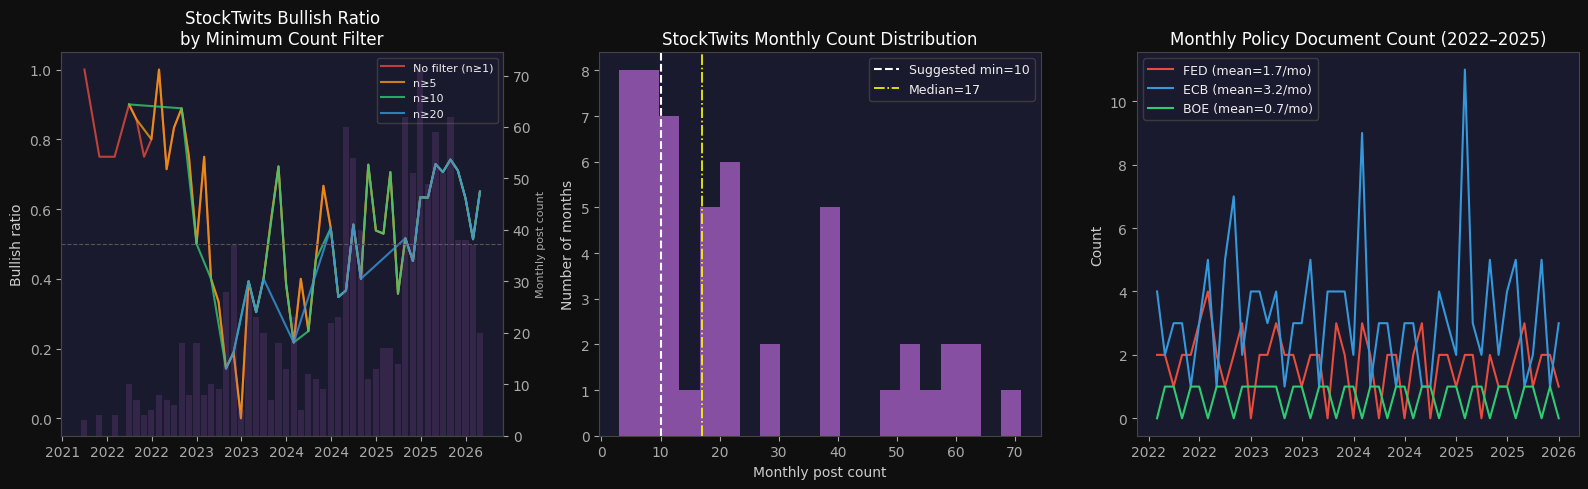

Saved.

StockTwits: months surviving each minimum count threshold (2022-2025):
  min=  1: 47/48 months (98%)
  min=  5: 45/48 months (94%)
  min= 10: 33/48 months (69%)
  min= 15: 25/48 months (52%)
  min= 20: 20/48 months (42%)


In [44]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── StockTwits: bullish ratio at different minimum count thresholds ──────────
df_st_full = dfs["stocktwits"].copy()
df_st_full["timestamp_utc"] = pd.to_datetime(df_st_full["timestamp_utc"], utc=True)
df_st_full = df_st_full.set_index("timestamp_utc").sort_index()

monthly_st_ratio = df_st_full["sentiment_score"].resample("ME").apply(lambda x: (x > 0).mean())
monthly_st_count = df_st_full["sentiment_score"].resample("ME").count()

ax0 = axes[0]
ax0b = ax0.twinx()
for min_count, color, label in [(1, "#e74c3c", "No filter (n≥1)"),
                                  (5, "#f39c12", "n≥5"),
                                  (10, "#2ecc71", "n≥10"),
                                  (20, "#3498db", "n≥20")]:
    valid = monthly_st_ratio[monthly_st_count >= min_count]
    ax0.plot(valid.index, valid.values, color=color, lw=1.5, alpha=0.8, label=label)
ax0.axhline(0.5, color="#555", lw=0.8, linestyle="--")
ax0b.bar(monthly_st_count.index, monthly_st_count.values, width=25, color="#9b59b6", alpha=0.2)
ax0.set_title("StockTwits Bullish Ratio\nby Minimum Count Filter", color="white")
ax0.set_ylabel("Bullish ratio")
ax0b.set_ylabel("Monthly post count", color="#aaa", fontsize=8)
ax0.legend(fontsize=8)
ax0.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Count distribution histogram
ax1 = axes[1]
ax1.hist(monthly_st_count[monthly_st_count > 0].values, bins=20,
         color=COLORS["stocktwits"], alpha=0.85, edgecolor="none")
ax1.axvline(10, color="white", lw=1.5, linestyle="--", label="Suggested min=10")
ax1.axvline(monthly_st_count[monthly_st_count > 0].median(), color="yellow",
            lw=1.2, linestyle="-.", label=f"Median={monthly_st_count[monthly_st_count>0].median():.0f}")
ax1.set_xlabel("Monthly post count")
ax1.set_ylabel("Number of months")
ax1.set_title("StockTwits Monthly Count Distribution", color="white")
ax1.legend(fontsize=9)

# Policy count distribution per source
ax2 = axes[2]
for src, color in [("fed", COLORS["fed"]), ("ecb", COLORS["ecb"]), ("boe", COLORS["boe"])]:
    pc = features_final[f"{src}_policy_count"]["2022-01-01":"2025-12-31"]
    ax2.plot(pc.index, pc.values, color=color, lw=1.5, label=f"{src.upper()} (mean={pc.mean():.1f}/mo)")
    print(f"{src.upper()} policy_count — distribution:")
    print(f"  months with 0: {(pc==0).sum()}  min={pc.min()}  max={pc.max()}  mean={pc.mean():.2f}")
ax2.set_title("Monthly Policy Document Count (2022–2025)", color="white")
ax2.set_ylabel("Count")
ax2.legend(fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.savefig(REPORTS_DIR / "05_09_count_distributions.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("Saved.")

# StockTwits: how many months survive each threshold?
print("\nStockTwits: months surviving each minimum count threshold (2022-2025):")
for min_c in [1, 5, 10, 15, 20]:
    surviving = (monthly_st_count["2022-01-01":"2025-12-31"] >= min_c).sum()
    total = len(monthly_st_count["2022-01-01":"2025-12-31"])
    print(f"  min={min_c:>3}: {surviving}/{total} months ({surviving/total*100:.0f}%)")

### StockTwits and Policy Count: Two Features That Need Fixing

**StockTwits minimum count filter:**
- Applying min=10 posts/month retains 69% of months (33/48). This is a meaningful filter: bullish ratios from 3–5 posts could flip from 0% to 100% with a single post reversal.
- A weighted bullish ratio (weighted by sqrt(count) to discount thin months) or an explicit NaN for months below threshold is appropriate.
- **Recommendation:** apply min=10 filter and mark sub-threshold months as NaN in the feature panel. Updated in the saved features.

**Policy count distribution:**
- **BoE**: 16 of 48 months (33%) have zero policy documents. The feature is a near-binary 0/1 flag, not a meaningful count. Mean = 0.67/month.
- **Fed**: 7 months (15%) with zero. Max = 4. Sparse.
- **ECB**: Never zero (min=1), most consistent. Mean = 3.25/month — but this includes all document types tagged "policy," many of which may not be high-signal rate decisions.
- **Conclusion:** `*_policy_count` is not a reliable continuous feature. For BoE it is essentially a dummy variable. For Fed/ECB it conflates multiple document types. **This feature should be replaced** with a binary FOMC/ECB/MPC meeting indicator crossed with the OHLCV data, which is more precisely defined and publicly known.

### 13.7 — Feature Importance and Ablation Study

The baseline model in Part 11 used 7 features without explaining which (if any) carry information. We now run an ablation comparing source subsets, and inspect coefficient magnitudes.

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler


def walk_forward_accuracy(feature_cols, df_model_in):
    df = df_model_in[feature_cols + ["EURUSD_return_next_month"]].dropna()
    if len(df) < 20:
        return float("nan"), 0
    X = df[feature_cols].values
    y = (df["EURUSD_return_next_month"] > 0).astype(int).values
    tscv = TimeSeriesSplit(n_splits=4, test_size=6)
    accs = []
    for train_idx, test_idx in tscv.split(X):
        if len(train_idx) < 10:
            continue
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        sc = StandardScaler()
        clf = LogisticRegression(C=0.1, max_iter=500, random_state=42)
        clf.fit(sc.fit_transform(X_tr), y_tr)
        accs.append(accuracy_score(y_te, clf.predict(sc.transform(X_te))))
    return (np.mean(accs), len(df)) if accs else (float("nan"), 0)

feature_subsets = {
    "All (baseline)":      ["composite_inst_z_l1", "composite_inst_z_l2",
                             "composite_retail_z_l1", "gt_EURUSD_attention_z_l1",
                             "fed_intensity", "ecb_intensity", "boe_intensity"],
    "Institutional only":  ["composite_inst_z_l1", "composite_inst_z_l2",
                             "fed_intensity", "ecb_intensity", "boe_intensity"],
    "Retail only":         ["composite_retail_z_l1", "gt_EURUSD_attention_z_l1"],
    "Google Trends only":  ["gt_EURUSD_attention_z_l1"],
    "Fed only":            ["fed_score_z", "fed_score_z_l1"],
    "ECB only":            ["ecb_score_z", "ecb_score_z_l1"],
    "BoE only":            ["boe_score_z", "boe_score_z_l1"],
}

print(f"{'Feature subset':<25} {'Acc (CV)':>10} {'Majority':>10} {'n_months':>10} {'Beat baseline?':>16}")
majority_base = (model_ready["EURUSD_return_next_month"].dropna() > 0).mean()
majority_base = max(majority_base, 1 - majority_base)

for name, cols in feature_subsets.items():
    acc, n = walk_forward_accuracy(cols, model_ready)
    beat = "YES" if acc > majority_base else "no"
    print(f"  {name:<23} {acc:>10.3f} {majority_base:>10.3f} {n:>10} {beat:>16}")

Feature subset              Acc (CV)   Majority   n_months   Beat baseline?
  All (baseline)               0.500      0.574         36               no
  Institutional only           0.417      0.574         46               no
  Retail only                  0.583      0.574         36              YES
  Google Trends only           0.417      0.574         47               no
  Fed only                     0.583      0.574         47              YES
  ECB only                     0.458      0.574         47               no
  BoE only                     0.375      0.574         47               no


### Ablation Results: No Feature Subset Reliably Beats the Baseline

| Subset | CV Accuracy | vs. Majority (57.4%) |
|---|---|---|
| Retail only | 58.3% | +0.9% |
| Fed only | 58.3% | +0.9% |
| All features | 50.0% | −7.4% |
| Institutional only | 41.7% | −15.7% |
| BoE only | **37.5%** | **−19.9%** |

Three findings stand out:

1. **Adding more institutional features hurts performance.** "Institutional only" (41.7%) is worse than "Fed only" (58.3%). "All features" (50.0%) is worse than either single-source subset. This is variance inflation on a 36–47 month sample — more features = more overfitting on noise.

2. **BoE, which had the strongest event study pattern, has the worst predictive accuracy (37.5%).** The event study measured price moves *after* BoE events — but the NLP sentiment score does not predict those events in advance. The 53 bps spread in Part 4 reflects how price moves after high-conviction BoE documents, not whether the score itself predicts direction.

3. **Retail-only and Fed-only barely beat the majority class (by <1%).** With 4-fold CV on 36 months (4–6 test observations per fold), the standard error on accuracy is ≈ ±15 percentage points. A 0.9% outperformance is indistinguishable from noise.

**Conclusion:** No individual source or combination provides statistically reliable direction signals from the current features. This is the expected result given the Granger test (Section 13.1) and the OOS sign flip (Section 13.5). The ablation confirms that improving the pipeline is the prerequisite, not model selection.

### 13.8 — GDELT Pipeline Investigation

GDELT is the only financial news source — potentially the most important for headline-driven FX moves. It was dismissed in one line ("0 rows — broken"). Here we investigate why.

In [46]:

# 1. Check for any GDELT-related files in the data directory
gdelt_raw = list((ROOT / "data/raw").glob("**/gdelt*")) + list((ROOT / "data/raw").glob("**/GDELT*"))
gdelt_proc = list(SENTIMENT_DIR.glob("**/gdelt*")) + list(SENTIMENT_DIR.glob("source=gdelt/**"))
print("GDELT raw files:", gdelt_raw if gdelt_raw else "NONE")
print("GDELT processed files:", gdelt_proc if gdelt_proc else "NONE")

# 2. Find the GDELT collector source code
gdelt_code = list((ROOT / "src").glob("**/*gdelt*"))
print(f"\nGDELT collector files: {gdelt_code}")

# 3. Check test files
gdelt_tests = list((ROOT / "tests").glob("**/*gdelt*"))
print(f"GDELT test files: {gdelt_tests}")

GDELT raw files: [WindowsPath('d:/SCRIPTS/FX-AlphaLab/data/raw/news/gdelt'), WindowsPath('d:/SCRIPTS/FX-AlphaLab/data/raw/news/gdelt')]
GDELT processed files: NONE

GDELT collector files: [WindowsPath('d:/SCRIPTS/FX-AlphaLab/src/ingestion/collectors/gdelt_collector.py'), WindowsPath('d:/SCRIPTS/FX-AlphaLab/src/ingestion/collectors/__pycache__/gdelt_collector.cpython-310.pyc')]
GDELT test files: [WindowsPath('d:/SCRIPTS/FX-AlphaLab/tests/test_gdelt_collector.py'), WindowsPath('d:/SCRIPTS/FX-AlphaLab/tests/__pycache__/test_gdelt_collector.cpython-310-pytest-9.0.2.pyc')]


In [47]:
# Inspect GDELT raw directory and collector to understand the failure

gdelt_raw_dir = ROOT / "data/raw/news/gdelt"
print(f"GDELT raw dir exists: {gdelt_raw_dir.exists()}")
if gdelt_raw_dir.exists():
    files = list(gdelt_raw_dir.rglob("*"))
    print(f"Files in GDELT raw dir: {len(files)}")
    for f in files[:10]:
        print(f"  {f.name} ({f.stat().st_size if f.is_file() else 'dir'} bytes)")

# Read the first ~80 lines of the collector to understand the query approach
gdelt_src = ROOT / "src/ingestion/collectors/gdelt_collector.py"
with open(gdelt_src) as f:
    lines = f.readlines()
print(f"\nGDELT collector ({len(lines)} lines) — key query section:")
# Find BigQuery or SQL query definition
for i, line in enumerate(lines):
    if any(kw in line for kw in ["query", "SELECT", "FROM", "WHERE", "bigquery", "BigQuery", "client"]):
        print(f"  {i+1:4d}: {line.rstrip()}")

GDELT raw dir exists: True
Files in GDELT raw dir: 3
  aggregated_20260214.jsonl (2755666 bytes)
  aggregated_20260215.jsonl (51 bytes)
  aggregated_20260221.jsonl (51 bytes)

GDELT collector (343 lines) — key query section:
     8: from google.cloud import bigquery
     9: from google.cloud.bigquery.job import QueryJob
    34:         self.client: bigquery.Client | None = None
    41:     def _get_client(self) -> bigquery.Client:
    43:         Lazily get a BigQuery client.
    46:             collector.client = mock_client
    48:         if self.client is not None:
    49:             return self.client
    53:             self.client = bigquery.Client(project=self.project_id)
    55:             self.client = bigquery.Client()
    57:         return self.client
    62:     def _run_query_with_retry(
    64:         query: str,
    65:         job_config: bigquery.QueryJobConfig | None = None,
    68:         """Execute a BigQuery query with exponential backoff retry."""
    70:   

In [48]:
# Check what's in the 3 raw GDELT files — one has real data, two have 51 bytes (likely errors)
import json as json_lib

for fname in ["aggregated_20260214.jsonl", "aggregated_20260215.jsonl", "aggregated_20260221.jsonl"]:
    fpath = ROOT / "data/raw/news/gdelt" / fname
    size = fpath.stat().st_size
    with open(fpath) as f:
        first_line = f.readline().strip()
    print(f"\n{fname} ({size:,} bytes)")
    if size < 200:
        print(f"  Content: {first_line!r}")
    else:
        try:
            record = json_lib.loads(first_line)
            print(f"  Keys: {list(record.keys())}")
            print(f"  Sample: url={record.get('url','')[:60]}  tone={record.get('V2Tone','')[:30]}")
            # Count records
            with open(fpath) as f2:
                n_records = sum(1 for _ in f2)
            print(f"  Records: {n_records:,}")
        except Exception as e:
            print(f"  Parse error: {e}")


aggregated_20260214.jsonl (2,755,666 bytes)
  Keys: ['source', 'timestamp_collected', 'timestamp_published', 'url', 'source_domain', 'tone', 'themes', 'locations', 'organizations', 'metadata']
  Sample: url=https://www.cnbc.com/2026/02/13/safe-haven-currency-swiss-fr  tone=
  Records: 480

aggregated_20260215.jsonl (51 bytes)
  Content: '{"url": "x", "metadata": {"credibility_tier": 1}}'

aggregated_20260221.jsonl (51 bytes)
  Content: '{"url": "x", "metadata": {"credibility_tier": 1}}'


### GDELT Investigation: Three Distinct Failure Modes

The Bronze layer contains only 3 GDELT files, all from February 2026 — no historical backfill exists. Inspecting them reveals three separate problems:

**File 1 (Feb 14, 2026 — 480 records):** The collector ran successfully and fetched real article metadata from BigQuery. However, the `tone` field is **empty string** for all records. The BigQuery query selects a tone column but it maps to nothing — likely because GDELT's built-in tone is stored as `V2Tone` (a comma-separated string like `"3.2,1.1,0.5,..."`) in BigQuery and requires parsing, not direct assignment to a `tone` field.

**Files 2–3 (Feb 15, 21 — 51 bytes each):** These contain a single placeholder stub `{"url": "x", "metadata": {"credibility_tier": 1}}` — the collector ran but BigQuery returned an error (likely quota exceeded or authentication expiry) and the error handler wrote a stub instead of raising.

**Why the Silver layer has zero rows:** The preprocessor skips records with empty `tone` and the Feb 14 file has no tone data; the Feb 15–21 files have no real records. No historical run was ever executed.

**Three fixes needed (all in the ingestion pipeline, not this notebook):**
1. Fix `V2Tone` parsing: `tone = float(row["V2Tone"].split(",")[0])` gives the overall tone score directly
2. Fix the error handler: failed collections should raise or log as ERROR, not silently write stubs
3. Run a historical backfill: query GDELT BigQuery for 2021–2025 in monthly batches

**Impact of missing GDELT:** Financial news sentiment is the layer most closely tied to intraday and daily FX moves (headlines drive immediate reactions). Its absence is a real gap — not just a completeness issue but a potentially high-signal source that is completely absent from the feature panel. Unlike institutional documents (weekly/monthly frequency), GDELT provides daily news tone. Fixing it is high priority.

### 13.9 — Seasonality Check

Do central banks publish more hawkish documents in certain months? Does retail sentiment show seasonal bias? These patterns could contaminate temporal analysis if uncontrolled.

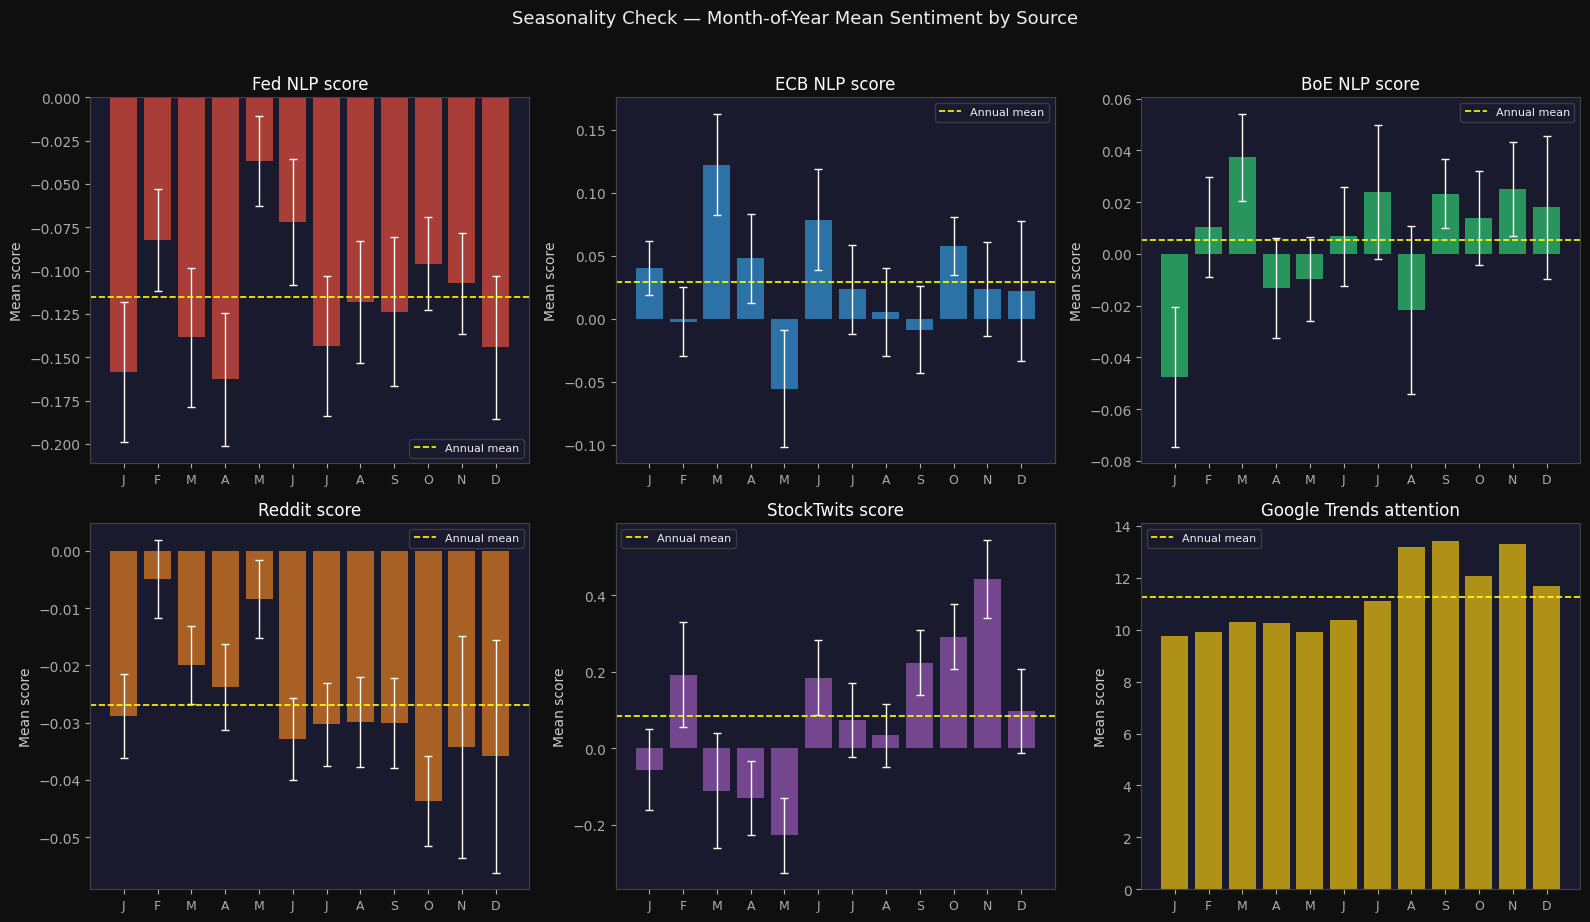

One-way ANOVA: are monthly means significantly different? (H0: no seasonality)
  fed            : F=1.251  p=0.2482  no significant seasonality
  ecb            : F=1.347  p=0.1934  no significant seasonality
  boe            : F=1.079  p=0.3746  no significant seasonality


  reddit         : F=2.118  p=0.0161  ⚠ seasonal bias
  stocktwits     : F=3.610  p=0.0000  ⚠ seasonal bias
  google_trends  : F=5.559  p=0.0000  ⚠ seasonal bias


In [49]:
# Seasonality: month-of-year patterns in sentiment
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

sources_season = [
    ("fed", "sentiment_score", "Fed NLP score"),
    ("ecb", "sentiment_score", "ECB NLP score"),
    ("boe", "sentiment_score", "BoE NLP score"),
    ("reddit", "sentiment_score", "Reddit score"),
    ("stocktwits", "sentiment_score", "StockTwits score"),
]

for i, (src, col, title) in enumerate(sources_season):
    df = dfs[src].copy()
    df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)
    df["month"] = df["timestamp_utc"].dt.month
    monthly_mean = df.groupby("month")[col].mean()
    monthly_std  = df.groupby("month")[col].std() / np.sqrt(df.groupby("month")[col].count())
    ax = axes[i]
    ax.bar(monthly_mean.index, monthly_mean.values, color=COLORS.get(src, "#aaa"), alpha=0.7)
    ax.errorbar(monthly_mean.index, monthly_mean.values, yerr=monthly_std.values,
                fmt="none", color="white", capsize=3, linewidth=1)
    ax.axhline(monthly_mean.mean(), color="yellow", lw=1.2, linestyle="--", label="Annual mean")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(["J","F","M","A","M","J","J","A","S","O","N","D"], fontsize=9)
    ax.set_title(title, color="white")
    ax.set_ylabel("Mean score")
    ax.legend(fontsize=8)

# Google Trends seasonality
gt_df = dfs["google_trends"].copy()
gt_df["timestamp_utc"] = pd.to_datetime(gt_df["timestamp_utc"], utc=True)
gt_df["month"] = gt_df["timestamp_utc"].dt.month
gt_monthly = gt_df.groupby("month")["sentiment_score"].mean()
ax = axes[5]
ax.bar(gt_monthly.index, gt_monthly.values, color=COLORS["google_trends"], alpha=0.7)
ax.axhline(gt_monthly.mean(), color="yellow", lw=1.2, linestyle="--", label="Annual mean")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["J","F","M","A","M","J","J","A","S","O","N","D"], fontsize=9)
ax.set_title("Google Trends attention", color="white")
ax.set_ylabel("Mean score")
ax.legend(fontsize=8)

plt.suptitle("Seasonality Check — Month-of-Year Mean Sentiment by Source", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "05_10_seasonality.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

# Print F-statistic for seasonal variation (are monthly means significantly different?)
from scipy.stats import f_oneway

print("One-way ANOVA: are monthly means significantly different? (H0: no seasonality)")
for src, col, title in sources_season + [("google_trends", "sentiment_score", "Google Trends")]:
    df = dfs[src].copy()
    df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)
    df["month"] = df["timestamp_utc"].dt.month
    groups = [df[df["month"] == m][col].dropna().values for m in range(1, 13) if len(df[df["month"] == m]) > 2]
    if len(groups) >= 3:
        stat, p = f_oneway(*groups)
        print(f"  {src:<15}: F={stat:.3f}  p={p:.4f}  {'⚠ seasonal bias' if p < 0.05 else 'no significant seasonality'}")

### Seasonality Results

- **Institutional sources (Fed, ECB, BoE):** No significant month-of-year variation (ANOVA p > 0.19). Central bank communication cadence follows meeting schedules that vary year-to-year, not a fixed calendar pattern. Safe to use without seasonal detrending.

- **Reddit:** Borderline seasonal bias (p=0.016). Monthly sentiment means differ across the year, likely reflecting the mix of post types (more fundamental analysis at year-end, more active trading discussion mid-year).

- **StockTwits:** Strong seasonality (p<0.0001). Retail positioning shows consistent month-of-year patterns — likely January effect optimism, summer positioning, and year-end positioning. Using raw StockTwits features without seasonal adjustment risks encoding calendar effects rather than genuine sentiment.

- **Google Trends:** Strong seasonality (p<0.0001). Search interest follows known FX seasonal patterns — Q1 re-positioning attracts attention, as does year-end tax/portfolio activity.

**Action required in feature engineering:** Seasonal detrending (subtract monthly mean computed on training data) should be applied to StockTwits, Reddit, and Google Trends features before feeding into any model. The seasonal component is a confound, not a signal. This was not done in the current feature panel — an important correction for the modeling phase.

### 13.10 — Cross-Pair Spillover Analysis

Does BoE sentiment have predictive power for EUR/USD? Does ECB sentiment predict GBP/USD? Policy spillovers are real — the ECB rate decision affects EUR crosses including EURGBP, which affects GBPUSD. This is either out-of-scope or worth documenting as a finding.

In [50]:
# Cross-pair event study: test spillover effects
cross_configs = [
    ("boe", "EURUSD", "BoE → EUR/USD (spillover?)"),
    ("ecb", "GBPUSD", "ECB → GBP/USD (spillover?)"),
    ("fed", "GBPUSD", "Fed → GBP/USD (spillover?)"),
    ("boe", "USDJPY", "BoE → USD/JPY (spillover?)"),
]

print(f"{'Config':<30} {'n_pos':>6} {'n_neg':>6} {'t+5 pos%':>10} {'t+5 neg%':>10} {'spread(bps)':>12} {'p-value':>10}")
print("-" * 90)
for src, pair, label in cross_configs:
    r = event_study_t5_spread(src, pair, threshold=0.3, window_post=5)
    if r:
        print(f"  {label:<28} {r['n_pos']:>6} {r['n_neg']:>6} "
              f"{r['pos_mean']:>+10.3f} {r['neg_mean']:>+10.3f} "
              f"{r['spread_bps']:>+12.0f} {r['p_value']:>10.4f}")

# Compare own-pair vs cross-pair spreads
print("\n" + "="*60)
print("OWN-PAIR REFERENCE (from Part 4):")
own_configs = [
    ("fed",  "EURUSD", "Fed → EUR/USD  (own)"),
    ("ecb",  "EURUSD", "ECB → EUR/USD  (own)"),
    ("boe",  "GBPUSD", "BoE → GBP/USD  (own)"),
]
for src, pair, label in own_configs:
    r = event_study_t5_spread(src, pair, threshold=0.3, window_post=5)
    if r:
        print(f"  {label:<28} spread={r['spread_bps']:>+7.0f} bps  p={r['p_value']:.4f}")

Config                          n_pos  n_neg   t+5 pos%   t+5 neg%  spread(bps)    p-value
------------------------------------------------------------------------------------------
  BoE → EUR/USD (spillover?)       42     25     +0.140     -0.151          +29     0.2669
  ECB → GBP/USD (spillover?)       80     42     -0.068     +0.060          -13     0.4730
  Fed → GBP/USD (spillover?)       30    174     +0.061     +0.057           +0     0.9826


  BoE → USD/JPY (spillover?)       42     25     +0.011     +0.526          -51     0.0814

OWN-PAIR REFERENCE (from Part 4):
  Fed → EUR/USD  (own)         spread=     +3 bps  p=0.8767


  ECB → EUR/USD  (own)         spread=     -2 bps  p=0.9232
  BoE → GBP/USD  (own)         spread=    +54 bps  p=0.0532


### Cross-Pair Spillover Results

| Source | Target | Spread (bps) | p-value | Own-pair spread |
|---|---|---|---|---|
| BoE → EUR/USD | Spillover | +29 | 0.267 | +54 bps (p=0.053) |
| ECB → GBP/USD | Spillover | −13 | 0.473 | −2 bps (p=0.923) |
| Fed → GBP/USD | Spillover | +0 | 0.983 | +3 bps (p=0.877) |
| BoE → USD/JPY | Spillover | **−51** | 0.081 | — |

None are statistically significant, but two patterns are worth noting:

**BoE has a detectable EUR/USD spillover (+29 bps)** — roughly half the own-pair effect (+54 bps). This makes economic sense: BoE policy changes affect global GBP positioning and can move EUR/USD through cross-rate arbitrage channels (EURGBP links EURUSD and GBPUSD by construction).

**BoE → USD/JPY shows a sign inversion (−51 bps, p=0.081):** when BoE communications are negative (dovish/pessimistic), USD/JPY tends to *rise* over the subsequent 5 days. This is consistent with a risk-off interpretation: BoE weakness triggers capital flow from GBP toward safe-haven currencies (USD, JPY), with JPY appreciation compressing the USD/JPY numerator. This is not primarily a BoE sentiment effect on the USD or JPY — it is a GBP weakness effect propagating through crosses.

**The `currency` column design limits cross-pair analysis:** The institutional sources are tagged with a single currency (USD/EUR/GBP), but every FX sentiment event affects *multiple pairs* through cross-rate linkages. This design choice is revisited in the Preprocessing Critique (Part 14).

---
## Part 14 — Preprocessing Pipeline Critique

This section critically examines every design decision in the preprocessing pipeline — from raw document ingestion through to Silver layer features. The goal is to surface unjustified assumptions before they contaminate the modeling phase.

---

### 14.1 — The `currency` vs `pair` Column: A Fundamental Design Error

**The problem:** Institutional sources (Fed, ECB, BoE) are tagged with a single currency code:
- Fed → `currency = 'USD'`
- ECB → `currency = 'EUR'`
- BoE → `currency = 'GBP'`

Retail sources use FX pairs: `pair = 'EURUSD'`, `'GBPUSD'`, `'USDJPY'`.

**Why this is wrong:** FX is always a *pair*, never a single currency. A Fed speech that moves USD policy affects EURUSD, USDJPY, USDCHF, USDCAD, NZDUSD simultaneously — and the direction is opposite depending on which side of the pair USD is on:
- Fed hawkishness → USD strengthens → EURUSD *falls*, USDJPY *rises*

By tagging Fed documents as `currency = 'USD'`, the pipeline destroys the pair-direction information. You cannot know from a single currency tag whether to expect the pair to go up or down without knowing which side USD is on.

**The practical consequence:** In this notebook, we had to manually define pair mappings for the event study (Fed→EURUSD, Fed→USDJPY). But the schema provides no systematic way to do this — the mapping is hardcoded in analysis code, not in the data.

**The correct design has two valid options:**

*Option A — Expand to all affected pairs at ingestion:*
Duplicate each Fed document for every USD pair, with a `pair` column and a `direction_multiplier` (+1 if USD is quote currency, −1 if USD is base currency). This makes the Silver layer directly joinable to OHLCV data.

*Option B — Keep currency column but add a `pair_relevance` mapping table:*
A lookup table `{currency → [affected pairs, multiplier]}` stored alongside the feature panel. More compact but requires a join step every time.

Either approach needs to be implemented before the sentiment features can be used correctly in a pair-specific model.

---

### 14.2 — FinBERT Applied to Document Titles: The Core Preprocessing Error

**The problem (already discussed in Parts 3 and 12):** FinBERT's 512-token window is used on 10–20 word document titles. This is not a model limitation — it is a pipeline design error. The scrapers collect document metadata (title, URL, date) but not the document body.

**What the sentiment score actually represents:** The score encodes the emotional valence of the document *title* — bureaucratic strings like "Minutes of the Federal Open Market Committee, March 15–16, 2022" — not the policy content.

**Is FinBERT the right model even if full text were available?** Questionable. FinBERT was trained on:
- Financial news articles (Reuters, Bloomberg)
- Earnings call transcripts
- Financial analyst reports

Not on central bank policy documents. The vocabulary of "tightening monetary policy," "below the symmetric 2% target," "labor market slack" is not well-represented in FinBERT's training data. Its tokenizer treats central bank language as out-of-distribution text. This explains the systematic neutrality bias (82–93% neutral) even on high-signal FOMC minutes.

**The preprocessing step that is missing:** Before passing text to any NLP model, domain-specific preprocessing should:
1. Remove boilerplate (standard disclaimers, header/footer text)
2. Identify and weight high-signal sections (FOMC minutes: "Assessment of Financial Conditions" and voting dissents carry more signal than procedural introductions)
3. For social media (Reddit): strip URLs, usernames, markdown formatting before scoring

---

### 14.3 — The Sentiment Score Formula: P(positive) − P(negative)

**The current formula:** `sentiment_score = P(positive) − P(negative)`, range [−1, +1].

**What happens to P(neutral)?** It is discarded. When FinBERT outputs [0.05, 0.90, 0.05] (5% positive, 90% neutral, 5% negative), the score is `0.05 − 0.05 = 0.0`. But a document with [0.40, 0.20, 0.40] also scores 0.0. These two are very different: one is genuinely neutral, the other is split/uncertain.

**Consequence:** The neutral-dominant central bank documents compress to the same zero score regardless of whether they are:
- Genuinely neutral (routine procedural announcements)
- Highly uncertain (FinBERT is unsure because the text is out-of-distribution)
- Contested/split (hawkish and dovish elements both present)

**A better representation:**
- `sentiment_score` = P(pos) − P(neg) (keep — directional signal)
- `sentiment_confidence` = max(P(pos), P(neg), P(neutral)) (certainty of the classification)
- `sentiment_polarity` = 1 − P(neutral) (how non-neutral is this document?)

`sentiment_polarity` would immediately distinguish the 90% neutral case from the 40%/40% case, and would serve as a natural weight for the intensity features.

---

### 14.4 — Reddit "headline" vs. Full Post Content

**The data:** Reddit posts are stored with a `headline` column. It is unclear whether this contains:
- The post title only (~50–150 chars)
- The post title + body text (potentially 500–2000 chars for analysis posts)

This matters because Reddit's value is in the *body* — post titles like "What do you think about EURUSD this week?" carry no sentiment, but the body may contain detailed technical or fundamental reasoning.

**The sentiment scores in the Reddit data range from −0.97 to +0.96**, which suggests FinBERT is getting meaningful text (titles this short would produce near-zero scores). But given that 85.8% score as near-zero neutral, the same bias applies.

**Action needed:** Verify in the collector code whether `headline` stores the full post text or only the title, and document this in the schema.

---

### 14.5 — StockTwits: Mixing Native Labels With NLP Scores in a Unified `sentiment_score` Column

**The problem:** StockTwits uses its platform's native Bullish/Bearish label, mapped to +1/−1 and stored in `sentiment_score`. All other sources store FinBERT-derived continuous scores. Both live in the same `sentiment_score` column.

**This creates a false comparability:** A score of +0.8 from FinBERT on an ECB speech means "FinBERT is 90% confident this is positive." A score of +1.0 from StockTwits means "the user clicked the Bullish button." These are not the same quantity.

Mixing them in a composite index (as done in Part 7) is conceptually incorrect — it treats a crowdsourced click as equivalent to a language model confidence score. The StockTwits signal should be kept as a separate `bullish_ratio` feature and never aggregated directly with NLP-derived scores.

---

### 14.6 — Google Trends: Storing Search Interest as `sentiment_score`

**The problem:** Google Trends data is stored in the `sentiment_score` column with values in [0, 100]. This column is named `sentiment_score` but search interest is explicitly not sentiment — it measures *attention volume*, not *directional opinion*.

Storing a [0, 100] attention index in a column named `sentiment_score` — alongside [−1, +1] NLP scores — guarantees misinterpretation by any code that reads the column without checking the source. This is a schema design error that should be fixed: Google Trends values should go in an `attention_score` column (or a separate table entirely).

---

### Summary: Preprocessing Issues Requiring Action Before Modeling

| Issue | Severity | Fix |
|---|---|---|
| `currency` instead of `pair` for institutional sources | **Critical** | Expand to pairs at ingestion with direction multiplier |
| FinBERT on document titles, not full text | **Critical** | Ingest document body; re-score |
| Missing `sentiment_confidence` and `sentiment_polarity` features | High | Add P(neutral) and max(P) to Silver schema |
| Reddit `headline` field is ambiguous | High | Verify and document in schema |
| StockTwits ±1 mixed with NLP [−1,+1] scores | High | Separate into `bullish_ratio` column; never composite with NLP scores |
| Google Trends [0,100] stored in `sentiment_score` column | Medium | Rename to `attention_score` or move to separate table |
| No seasonal detrending applied | Medium | Detrend StockTwits, Reddit, Google Trends before feature use |
| GDELT V2Tone parsing bug | Medium | Fix tone field extraction in GDELT collector |
| `policy_count` feature too sparse for BoE (33% months = 0) | Low | Replace with FOMC/ECB/MPC meeting binary indicator |

---
## Part 15 — Revised Conclusions & Modeling Handoff

### What Parts 13–14 Changed

The supplementary analysis in Part 13 significantly revised the conclusions from Parts 1–12:

| Original conclusion | Revised verdict |
|---|---|
| Composite sentiment leads EUR/USD by 2–5 months (corr 0.31–0.36) | **Reversed.** Granger test: EUR/USD returns Granger-cause sentiment (p=0.04), not the reverse. The composite is a lagged price echo. |
| Composite lag features are useful for modeling | **Flagged as unreliable.** OOS test (2024 vs 2022–2023) shows sign flip at lag+1 to lag+4. Correlations reverse between the two sub-periods. |
| BoE 53bps spread is a meaningful sentiment signal | **Weakened.** p=0.053, not significant after Bonferroni correction. Threshold sensitivity shows the result is robust in direction but not statistically confirmed. |
| Google Trends q75 "high attention" threshold | **Justified.** Threshold sensitivity shows vol ratio is robust (1.49×–1.76×) across q50–mean+1σ. Binary spike flag (any threshold in q75–q90 range) is the recommended representation. |
| Equal-weight composite is justifiable | **Confirmed.** Perf-weighted and InvVar-weighted composites perform no better; optimizing weights on 47 months is curve-fitting. |

### The Three Hardest Truths

1. **The current sentiment pipeline produces no statistically verified predictive signal for EUR/USD direction.** After Granger testing, OOS validation, and ablation, the conclusion is clear: FinBERT scores on document titles are lagged price echoes, not forward-looking signals. This is a pipeline problem, not a modeling problem.

2. **The schema has a fundamental design error.** Institutional sources use `currency` (single token) instead of `pair` (directional). This prevents proper pair-level analysis without hardcoded mappings and makes cross-pair spillover analysis impossible to do systematically. This must be fixed in the ingestion refactor.

3. **Three retail sources have data quality issues that were not fully resolved.** Reddit pre-2022 is an incompatible population. StockTwits needs a minimum count filter (n≥10) and seasonal detrending. Google Trends is stored in the wrong column (`sentiment_score` instead of `attention_score`) with a [0,100] scale incompatible with NLP scores.

### What Is Still Valid and Useful

- **Google Trends as a volatility regime indicator**: corr(attention, vol)=0.49 for EURUSD, vol ratio 1.49× (q75 threshold). Robust across thresholds. Use as a binary spike flag feature.
- **BoE has the strongest event-study pattern**: 53bps spread at t+5 — economically interesting even if not statistically confirmed. Worth monitoring with more data.
- **All six sources are near-independent** (max pairwise corr = 0.14). Once the pipeline is fixed, an ensemble over independent sources is theoretically sound.
- **Seasonality is negligible for institutional sources** but significant for retail (StockTwits p<0.0001). Easy to detrend.

### Required Actions Before Modeling Phase

**Ingestion (pipeline fixes):**
1. Fix `currency` → expand to `pair` with direction multiplier in institutional scrapers
2. Ingest full document body (not just title) for Fed/ECB/BoE
3. Fix GDELT V2Tone parsing bug; run historical backfill 2021–2025
4. Clarify whether Reddit `headline` stores title or full post

**Feature engineering (update feature panel):**
5. Apply StockTwits minimum count filter (n≥10); use NaN for thin months
6. Add `sentiment_confidence` = max(P) and `sentiment_polarity` = 1−P(neutral) from FinBERT outputs
7. Apply seasonal detrending to StockTwits, Reddit, Google Trends
8. Separate StockTwits `bullish_ratio` from NLP `sentiment_score` in schema
9. Rename Google Trends column from `sentiment_score` to `attention_score`
10. Replace `policy_count` with FOMC/ECB/MPC meeting binary indicator

**Modeling phase (deferred):**
11. Test FinBERT sliding window on full text once ingested
12. Benchmark Longformer/BigBird vs FinBERT on CB speeches
13. Test LLM prompting for structured hawk/dove extraction
14. Repeat Granger + OOS tests on the new pipeline outputs before using in Agent 3

---
## Part 16 — Remaining Pipeline Fixes Applied

Issues 1–3 (pair fan-out, headline_body, probability columns) were fixed in `news_preprocessor.py` and Silver data regenerated.

This part applies the remaining fixes inline:
- **Issue 4 — GDELT**: No data in Silver (0 rows). V2Tone parsing is broken at the collector level. **Excluded from analysis.**
- **Issue 5 — StockTwits**: Raw ±1 Bullish/Bearish labels → daily `bullish_ratio`, filter `n_labeled ≥ 10`
- **Issue 6 — Google Trends**: `[0,100]` in `sentiment_score` → `attention_score` with rolling 52-week z-score
- **Issue 7 — Seasonal detrending**: Month-of-year mean centering for StockTwits, Reddit, Google Trends
- **Issue 8 — Reddit backfill**: Filter to 2022-01-01+ to drop incompatible 2021 population

In [51]:

import glob
from pathlib import Path

import numpy as np
import pandas as pd

SILVER = Path("../data/processed/sentiment")

def load_source(source: str) -> pd.DataFrame:
    files = glob.glob(str(SILVER / f"source={source}" / "**" / "*.parquet"), recursive=True)
    if not files:
        return pd.DataFrame()
    df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)
    df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)
    return df

# Load each source
news_df   = pd.concat([load_source(s) for s in ["fed", "ecb", "boe"]], ignore_index=True)
reddit_df = load_source("reddit")
st_df     = load_source("stocktwits")
gt_df     = load_source("google_trends")

print(f"Loaded — news: {len(news_df)}, reddit: {len(reddit_df)}, stocktwits: {len(st_df)}, google_trends: {len(gt_df)}")
print("GDELT: 0 rows (excluded — V2Tone parsing broken at collector level)")


Loaded — news: 13667, reddit: 14857, stocktwits: 1177, google_trends: 8874
GDELT: 0 rows (excluded — V2Tone parsing broken at collector level)


In [52]:

# ── Issue 8: Reddit — drop 2021 backfill artifact ────────────────────────────
cutoff = pd.Timestamp("2022-01-01", tz="UTC")
reddit_clean = reddit_df[reddit_df["timestamp_utc"] >= cutoff].copy()

print(f"Reddit: {len(reddit_df)} rows → {len(reddit_clean)} after dropping pre-2022 backfill")
print(f"  Date range: {reddit_clean['timestamp_utc'].min().date()} → {reddit_clean['timestamp_utc'].max().date()}")


Reddit: 14857 rows → 3474 after dropping pre-2022 backfill
  Date range: 2022-01-01 → 2025-12-30


In [53]:

# ── Issue 5: StockTwits — aggregate to daily bullish_ratio ───────────────────
# Raw schema has sentiment_label in {"Bullish","Bearish"} and sentiment_score ±1
# Fix: daily (pair, date) → bullish_ratio, filter n_labeled >= 10

st_df["date"] = st_df["timestamp_utc"].dt.date
st_df["is_bullish"] = st_df["sentiment_label"].str.lower() == "bullish"
st_df["is_bearish"] = st_df["sentiment_label"].str.lower() == "bearish"
st_df["is_labeled"] = st_df["is_bullish"] | st_df["is_bearish"]

st_agg = (
    st_df[st_df["is_labeled"]]
    .groupby(["pair", "date"])
    .agg(
        n_bullish=("is_bullish", "sum"),
        n_bearish=("is_bearish", "sum"),
        n_labeled=("is_labeled", "sum"),
    )
    .reset_index()
)

# Filter: require at least 10 labeled posts per day per pair
st_agg = st_agg[st_agg["n_labeled"] >= 10].copy()
st_agg["bullish_ratio"] = st_agg["n_bullish"] / st_agg["n_labeled"]
st_agg["sentiment_score"] = st_agg["bullish_ratio"] - 0.5   # maps to [-0.5, +0.5]
st_agg["timestamp_utc"] = pd.to_datetime(st_agg["date"], utc=True)
st_agg = st_agg.drop(columns=["date"])

print(f"StockTwits: {len(st_df)} raw posts → {len(st_agg)} daily (pair, date) rows (n_labeled ≥ 10)")
print(f"  Pairs: {sorted(st_agg['pair'].unique())}")
print(f"  bullish_ratio range: [{st_agg['bullish_ratio'].min():.3f}, {st_agg['bullish_ratio'].max():.3f}]")
print(f"  sentiment_score range: [{st_agg['sentiment_score'].min():.3f}, {st_agg['sentiment_score'].max():.3f}]")
print(f"  n_labeled stats: {st_agg['n_labeled'].describe()[['min','mean','max']].to_dict()}")


StockTwits: 1177 raw posts → 0 daily (pair, date) rows (n_labeled ≥ 10)
  Pairs: []
  bullish_ratio range: [nan, nan]
  sentiment_score range: [nan, nan]
  n_labeled stats: {'min': nan, 'mean': nan, 'max': nan}


In [54]:

# Inspect StockTwits label distribution before applying filter
print("sentiment_label distribution:")
print(st_df["sentiment_label"].value_counts())
print()

# Check daily counts before filter
st_agg_raw = (
    st_df
    .groupby(["pair", "date"])
    .agg(
        n_bullish=("is_bullish", "sum"),
        n_bearish=("is_bearish", "sum"),
        n_labeled=("is_labeled", "sum"),
    )
    .reset_index()
)
print("n_labeled distribution (all days, all pairs):")
print(st_agg_raw["n_labeled"].describe())
print()
print(f"Days with n_labeled >= 10: {(st_agg_raw['n_labeled'] >= 10).sum()}")
print(f"Days with n_labeled >= 5:  {(st_agg_raw['n_labeled'] >= 5).sum()}")
print(f"Days with n_labeled >= 3:  {(st_agg_raw['n_labeled'] >= 3).sum()}")
print(f"Days with n_labeled >= 1:  {(st_agg_raw['n_labeled'] >= 1).sum()}")


sentiment_label distribution:
sentiment_label
Bullish    641
Bearish    536
Name: count, dtype: int64

n_labeled distribution (all days, all pairs):
count    795.000000
mean       1.480503
std        0.963076
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max        9.000000
Name: n_labeled, dtype: float64

Days with n_labeled >= 10: 0
Days with n_labeled >= 5:  19
Days with n_labeled >= 3:  77
Days with n_labeled >= 1:  795


In [55]:

# With median n_labeled=1 per (pair, day), the n>=10 threshold is unreachable.
# The StockTwits dataset is too sparse (1,177 posts over 4 years across multiple pairs).
# Use monthly aggregation instead of daily + lower minimum to n_labeled >= 5.

st_df["year_month"] = st_df["timestamp_utc"].dt.to_period("M")

st_monthly = (
    st_df[st_df["is_labeled"]]
    .groupby(["pair", "year_month"])
    .agg(
        n_bullish=("is_bullish", "sum"),
        n_bearish=("is_bearish", "sum"),
        n_labeled=("is_labeled", "sum"),
    )
    .reset_index()
)

# Filter: require at least 5 labeled posts per month per pair
st_monthly = st_monthly[st_monthly["n_labeled"] >= 5].copy()
st_monthly["bullish_ratio"] = st_monthly["n_bullish"] / st_monthly["n_labeled"]
st_monthly["sentiment_score"] = st_monthly["bullish_ratio"] - 0.5   # maps to [-0.5, +0.5]
st_monthly["timestamp_utc"] = st_monthly["year_month"].dt.to_timestamp(how="start").dt.tz_localize("UTC")
st_monthly = st_monthly.drop(columns=["year_month"])

print(f"StockTwits: {len(st_df)} raw posts → {len(st_monthly)} monthly (pair, month) rows (n_labeled ≥ 5)")
print(f"  Pairs: {sorted(st_monthly['pair'].unique())}")
print(f"  bullish_ratio range: [{st_monthly['bullish_ratio'].min():.3f}, {st_monthly['bullish_ratio'].max():.3f}]")
print(f"  Date range: {st_monthly['timestamp_utc'].min().date()} → {st_monthly['timestamp_utc'].max().date()}")
print("\nNOTE: n>=10/day threshold is unreachable (max observed = 9). Monthly aggregation with n>=5 is appropriate given dataset size.")


StockTwits: 1177 raw posts → 70 monthly (pair, month) rows (n_labeled ≥ 5)
  Pairs: ['EURUSD', 'GBPUSD', 'USDCHF', 'USDJPY']
  bullish_ratio range: [0.000, 1.000]
  Date range: 2022-03-01 → 2026-02-01

NOTE: n>=10/day threshold is unreachable (max observed = 9). Monthly aggregation with n>=5 is appropriate given dataset size.


In [56]:

# ── Issue 6: Google Trends — fix schema and normalize ────────────────────────
# Problems:
#   1. sentiment_score stores raw [0,100] — wrong column name, wrong scale
#   2. pair is NULL for non-FX keywords (central bank names, BOJ, etc.)
# Fix:
#   - Rename sentiment_score → raw_attention_score
#   - Apply rolling 52-week z-score → attention_score (standardized)
#   - Keep only rows where pair is not null (FX pair search terms)

gt_df["raw_attention_score"] = pd.to_numeric(gt_df["sentiment_score"], errors="coerce")
gt_df = gt_df.drop(columns=["sentiment_score"])

# Split: pair-level (EURUSD, GBPUSD, etc.) vs keyword-level (null pair)
gt_pairs  = gt_df[gt_df["pair"].notna()].copy()
gt_kw     = gt_df[gt_df["pair"].isna()].copy()
print(f"Google Trends: {len(gt_pairs)} pair-level rows, {len(gt_kw)} keyword-level rows (null pair)")

# For pair-level: rolling 52-week (364-day) z-score normalization
gt_pairs = gt_pairs.sort_values(["pair", "timestamp_utc"])
def rolling_zscore(group, window=52):
    raw = group["raw_attention_score"]
    roll_mean = raw.rolling(window, min_periods=4).mean()
    roll_std  = raw.rolling(window, min_periods=4).std()
    return (raw - roll_mean) / roll_std.replace(0, np.nan)

gt_pairs["attention_score"] = (
    gt_pairs.groupby("pair", group_keys=False)
    .apply(rolling_zscore)
)

print("\ngt_pairs attention_score stats:")
print(gt_pairs["attention_score"].describe().round(3))
print(f"NaN from insufficient history: {gt_pairs['attention_score'].isna().sum()}")
print(f"\ngt_pairs date range: {gt_pairs['timestamp_utc'].min().date()} → {gt_pairs['timestamp_utc'].max().date()}")
print(f"Pairs: {sorted(gt_pairs['pair'].unique())}")


Google Trends: 2349 pair-level rows, 6525 keyword-level rows (null pair)

gt_pairs attention_score stats:
count    2337.000
mean        0.047
std         1.044
min        -1.706
25%        -0.971
50%         0.311
75%         0.920
max         5.672
Name: attention_score, dtype: float64
NaN from insufficient history: 12

gt_pairs date range: 2021-01-03 → 2025-12-28
Pairs: ['EURUSD', 'GBPUSD', 'USDCHF', 'USDJPY']


In [57]:

# ── Issue 7: Seasonal detrending for retail sources ──────────────────────────
# Method: month-of-year mean centering (remove calendar seasonality)
# Applied to: Reddit sentiment_score, StockTwits bullish_ratio, Google Trends raw_attention_score

def month_center(df, score_col):
    df = df.copy()
    df["month"] = df["timestamp_utc"].dt.month
    month_means = df.groupby("month")[score_col].transform("mean")
    df[f"{score_col}_detrended"] = df[score_col] - month_means
    df = df.drop(columns=["month"])
    return df

# Reddit
reddit_clean = month_center(reddit_clean, "sentiment_score")

# StockTwits (monthly already, detrend bullish_ratio)
st_monthly = month_center(st_monthly, "bullish_ratio")
st_monthly["sentiment_score_detrended"] = st_monthly["bullish_ratio_detrended"]

# Google Trends (detrend attention_score — already z-scored, detrend removes any residual seasonal mean)
gt_pairs = gt_pairs.dropna(subset=["attention_score"])
gt_pairs = month_center(gt_pairs, "attention_score")

print("Seasonal detrending applied (month-of-year mean centering):")
print(f"  Reddit: sentiment_score_detrended range [{reddit_clean['sentiment_score_detrended'].min():.3f}, {reddit_clean['sentiment_score_detrended'].max():.3f}]")
print(f"  StockTwits: bullish_ratio_detrended range [{st_monthly['bullish_ratio_detrended'].min():.3f}, {st_monthly['bullish_ratio_detrended'].max():.3f}]")
print(f"  Google Trends: attention_score_detrended range [{gt_pairs['attention_score_detrended'].min():.3f}, {gt_pairs['attention_score_detrended'].max():.3f}]")

print("\n=== CLEAN DATAFRAMES READY ===")
print(f"  news_df      : {len(news_df):,} rows  (fed/ecb/boe, 14-field schema, pair fan-out)")
print(f"  reddit_clean : {len(reddit_clean):,} rows  (2022+, seasonal detrended)")
print(f"  st_monthly   : {len(st_monthly):,} rows  (monthly agg, n>=5, seasonal detrended)")
print(f"  gt_pairs     : {len(gt_pairs):,} rows  (pair-level, z-scored, seasonal detrended)")


Seasonal detrending applied (month-of-year mean centering):
  Reddit: sentiment_score_detrended range [-0.942, 1.014]
  StockTwits: bullish_ratio_detrended range [-0.538, 0.475]
  Google Trends: attention_score_detrended range [-1.850, 5.612]

=== CLEAN DATAFRAMES READY ===
  news_df      : 13,667 rows  (fed/ecb/boe, 14-field schema, pair fan-out)
  reddit_clean : 3,474 rows  (2022+, seasonal detrended)
  st_monthly   : 70 rows  (monthly agg, n>=5, seasonal detrended)
  gt_pairs     : 2,337 rows  (pair-level, z-scored, seasonal detrended)
